<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Oxide_Free_Semimetal_Anharmonicity_Prediction_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install cupy-cuda12x  # Use 11x if the Colab CUDA version is 11

Using Python 3.13.15 environment at: /usr
Checked 1 package in 157ms


Numerical backend: CuPy GPU
Adjacency grid: 41 × 17 = 697 real-space nodes
Reduced Hamiltonian dimension: 48
Graph-Laplacian disorder modes: 8
Physics branch: fully normal-state confined single-electron model; no BCS gap, Josephson term, Andreev term, or oxide barrier.
Spin scope: one selected spin or Kramers sector. Spin-qubit screening requires an explicit spinful downfolded Hamiltonian.
Interpretation: alpha_eff is spectral non-equidistance. A usable charge-qubit regime also requires low reservoir broadening, adequate charging energy, a resolvable dipole, and thermal initialization.


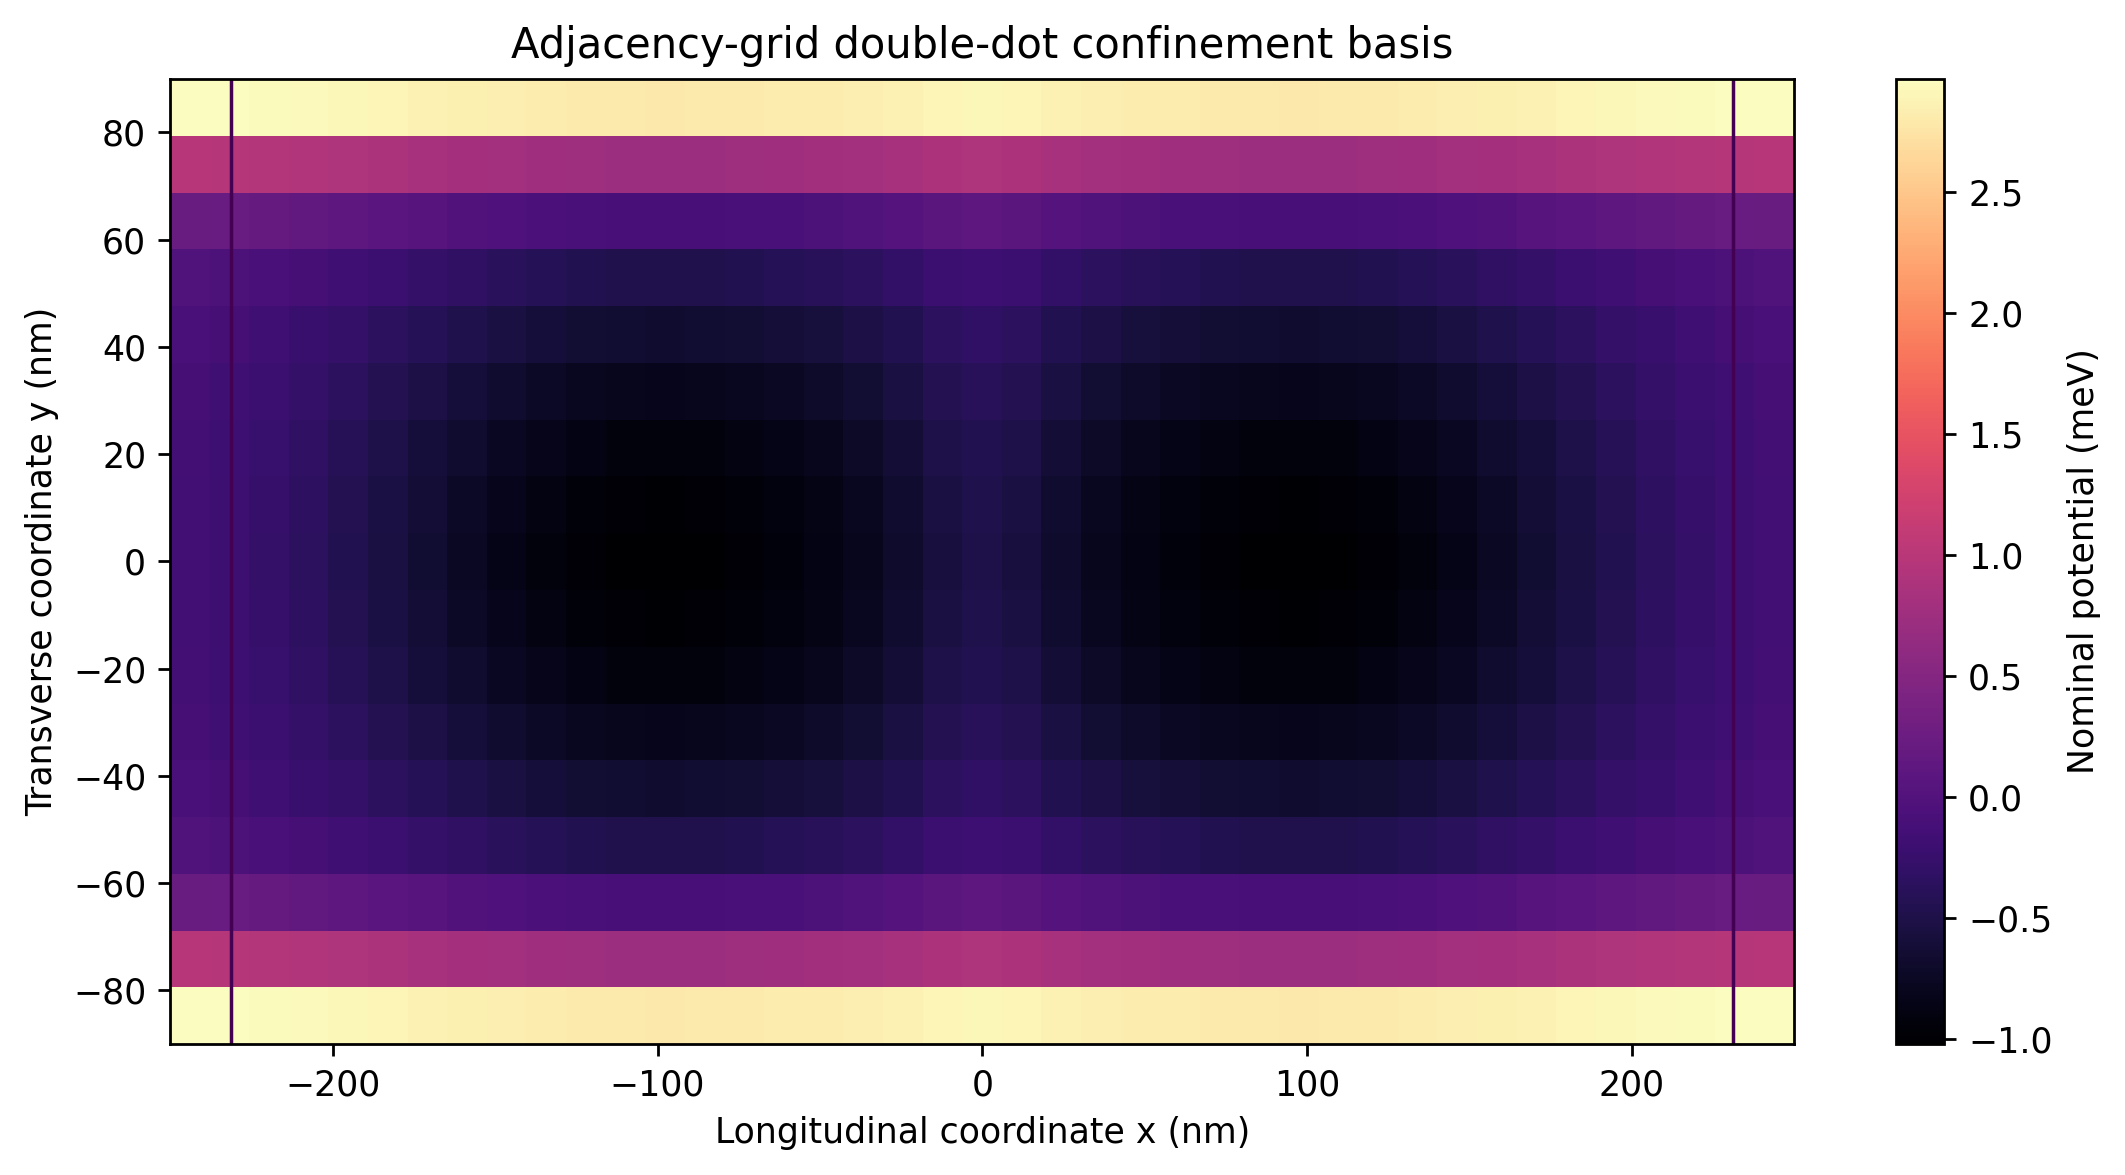


Candidate 1/3: Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au
MCMC acceptance=0.272, burn-in acceptance=0.186, proposal scale=0.1163
MCMC diagnostics:


,rhat,bulk_ess
f01_ghz,1.036,1000.522
alpha_eff_mhz,2.054,44.448
contact_linewidth_mhz,1.654,56.296
design_score,1.028,1003.144



Candidate 2/3: Ti/Au–graphene-like DQD–Ti/Au control
MCMC acceptance=0.252, burn-in acceptance=0.261, proposal scale=0.2705
MCMC diagnostics:


,rhat,bulk_ess
f01_ghz,1.034,919.795
alpha_eff_mhz,1.301,116.996
contact_linewidth_mhz,1.471,72.092
design_score,1.023,1155.129



Candidate 3/3: Ti/Au–Pt3Sn plain nanobridge–Ti/Au control
MCMC acceptance=0.243, burn-in acceptance=0.178, proposal scale=0.1070
MCMC diagnostics:


,rhat,bulk_ess
f01_ghz,1.121,216.660
alpha_eff_mhz,1.753,51.983
contact_linewidth_mhz,1.089,302.985
design_score,1.113,240.099



Candidate summary:


,candidate,ensemble,samples,viability_probability,f01_p05_ghz,f01_median_ghz,f01_p95_ghz,alpha_p05_mhz,alpha_median_mhz,alpha_p95_mhz,abs_alpha_median_mhz,linewidth_median_mhz,x01_median_nm,charging_energy_median_mev,ground_population_median,rabi_median_mhz
0,Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au,forward Monte Carlo,4096,0.0151,15.2938,83.8168,239.8215,-161987.6808,-21306.1421,124734.8980,47827.3523,87.5436,38.3612,2.8677,1.0,92.7571
1,Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au,design-conditioned Metropolis,4800,0.7177,2.1737,5.9436,10.4462,11475.1212,67150.0591,281135.8207,67150.0591,35.3092,4.2757,3.1960,1.0,10.3386
2,Ti/Au–graphene-like DQD–Ti/Au control,forward Monte Carlo,4096,0.0256,14.8375,39.2787,91.2005,-37448.4625,43558.3827,100133.9499,46740.5224,4.5806,64.5051,3.6379,1.0,155.9726
3,Ti/Au–graphene-like DQD–Ti/Au control,design-conditioned Metropolis,4800,0.9267,3.6440,7.7356,12.0242,35397.8165,79310.4879,138937.4606,79310.4879,2.9770,89.7514,3.7535,1.0,217.0178
4,Ti/Au–Pt3Sn plain nanobridge–Ti/Au control,forward Monte Carlo,4096,0.0000,14.0755,76.4880,229.2534,-156796.3063,-25995.9907,103721.0102,39689.4813,19577.5468,45.0584,2.8327,1.0,108.9508
5,Ti/Au–Pt3Sn plain nanobridge–Ti/Au control,design-conditioned Metropolis,4800,0.4058,2.6985,6.7372,11.1996,-2518.4671,5074.2519,42367.2663,5162.7174,65.0155,32.2327,2.7302,1.0,77.9382


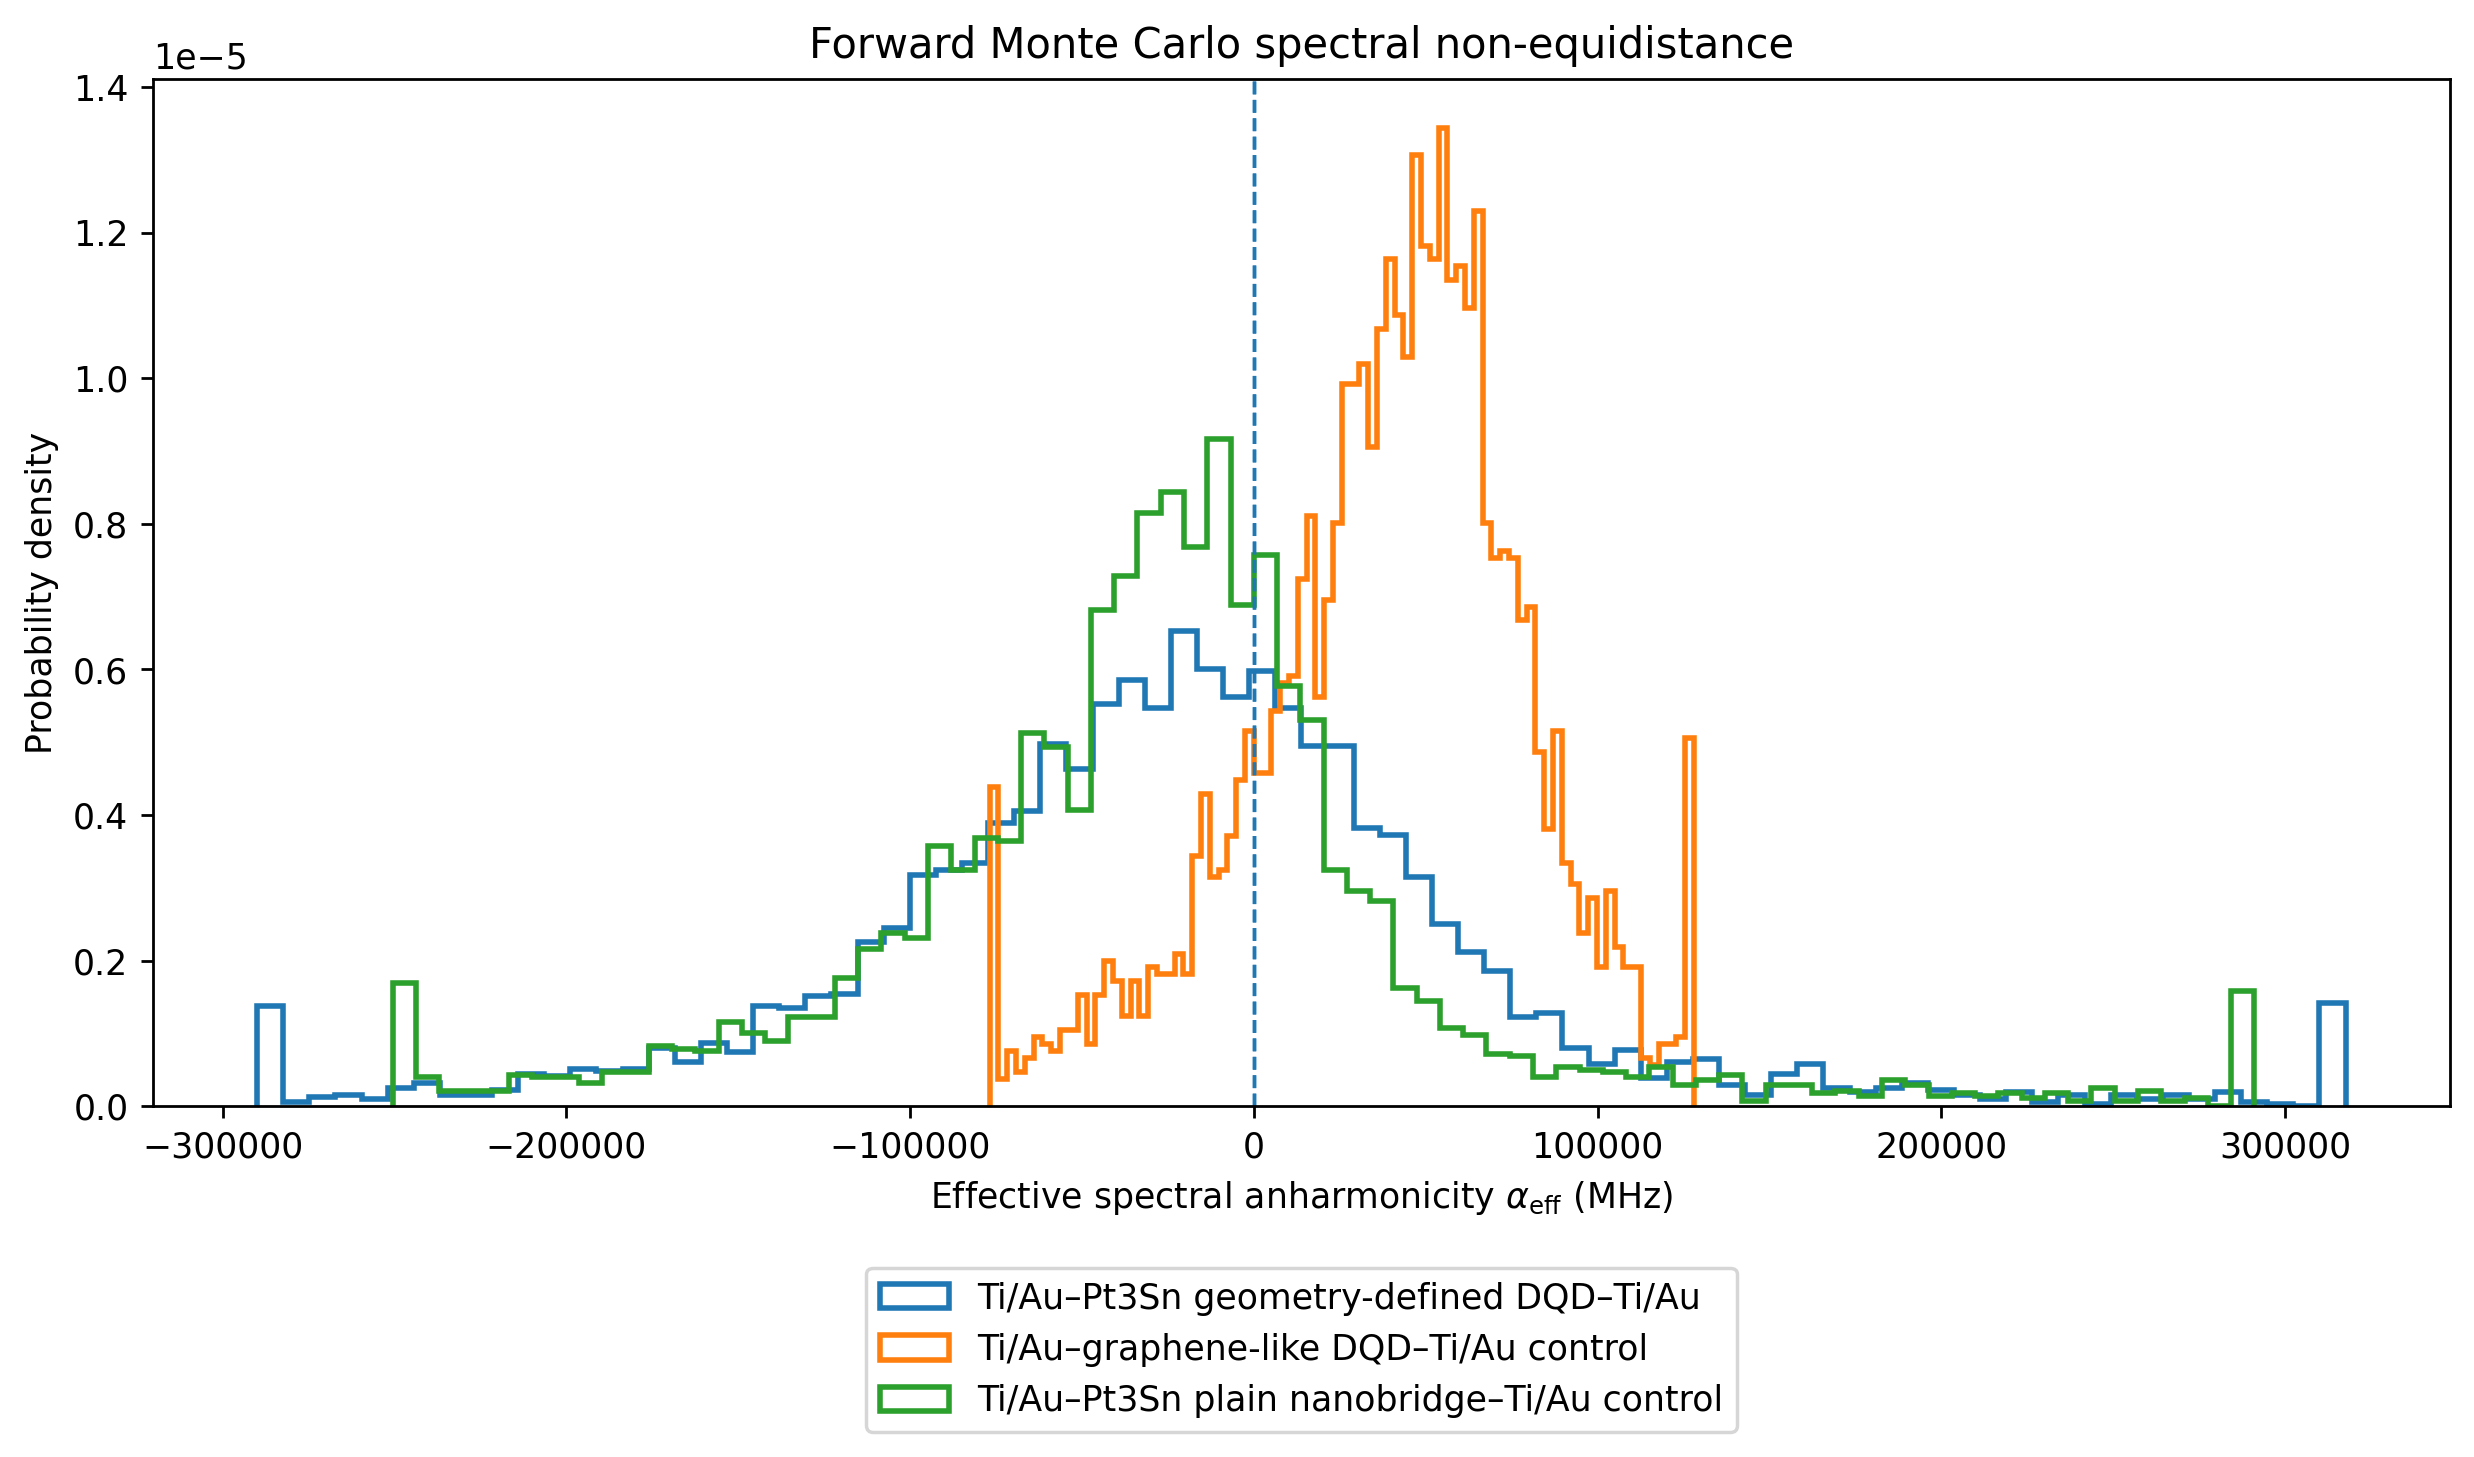

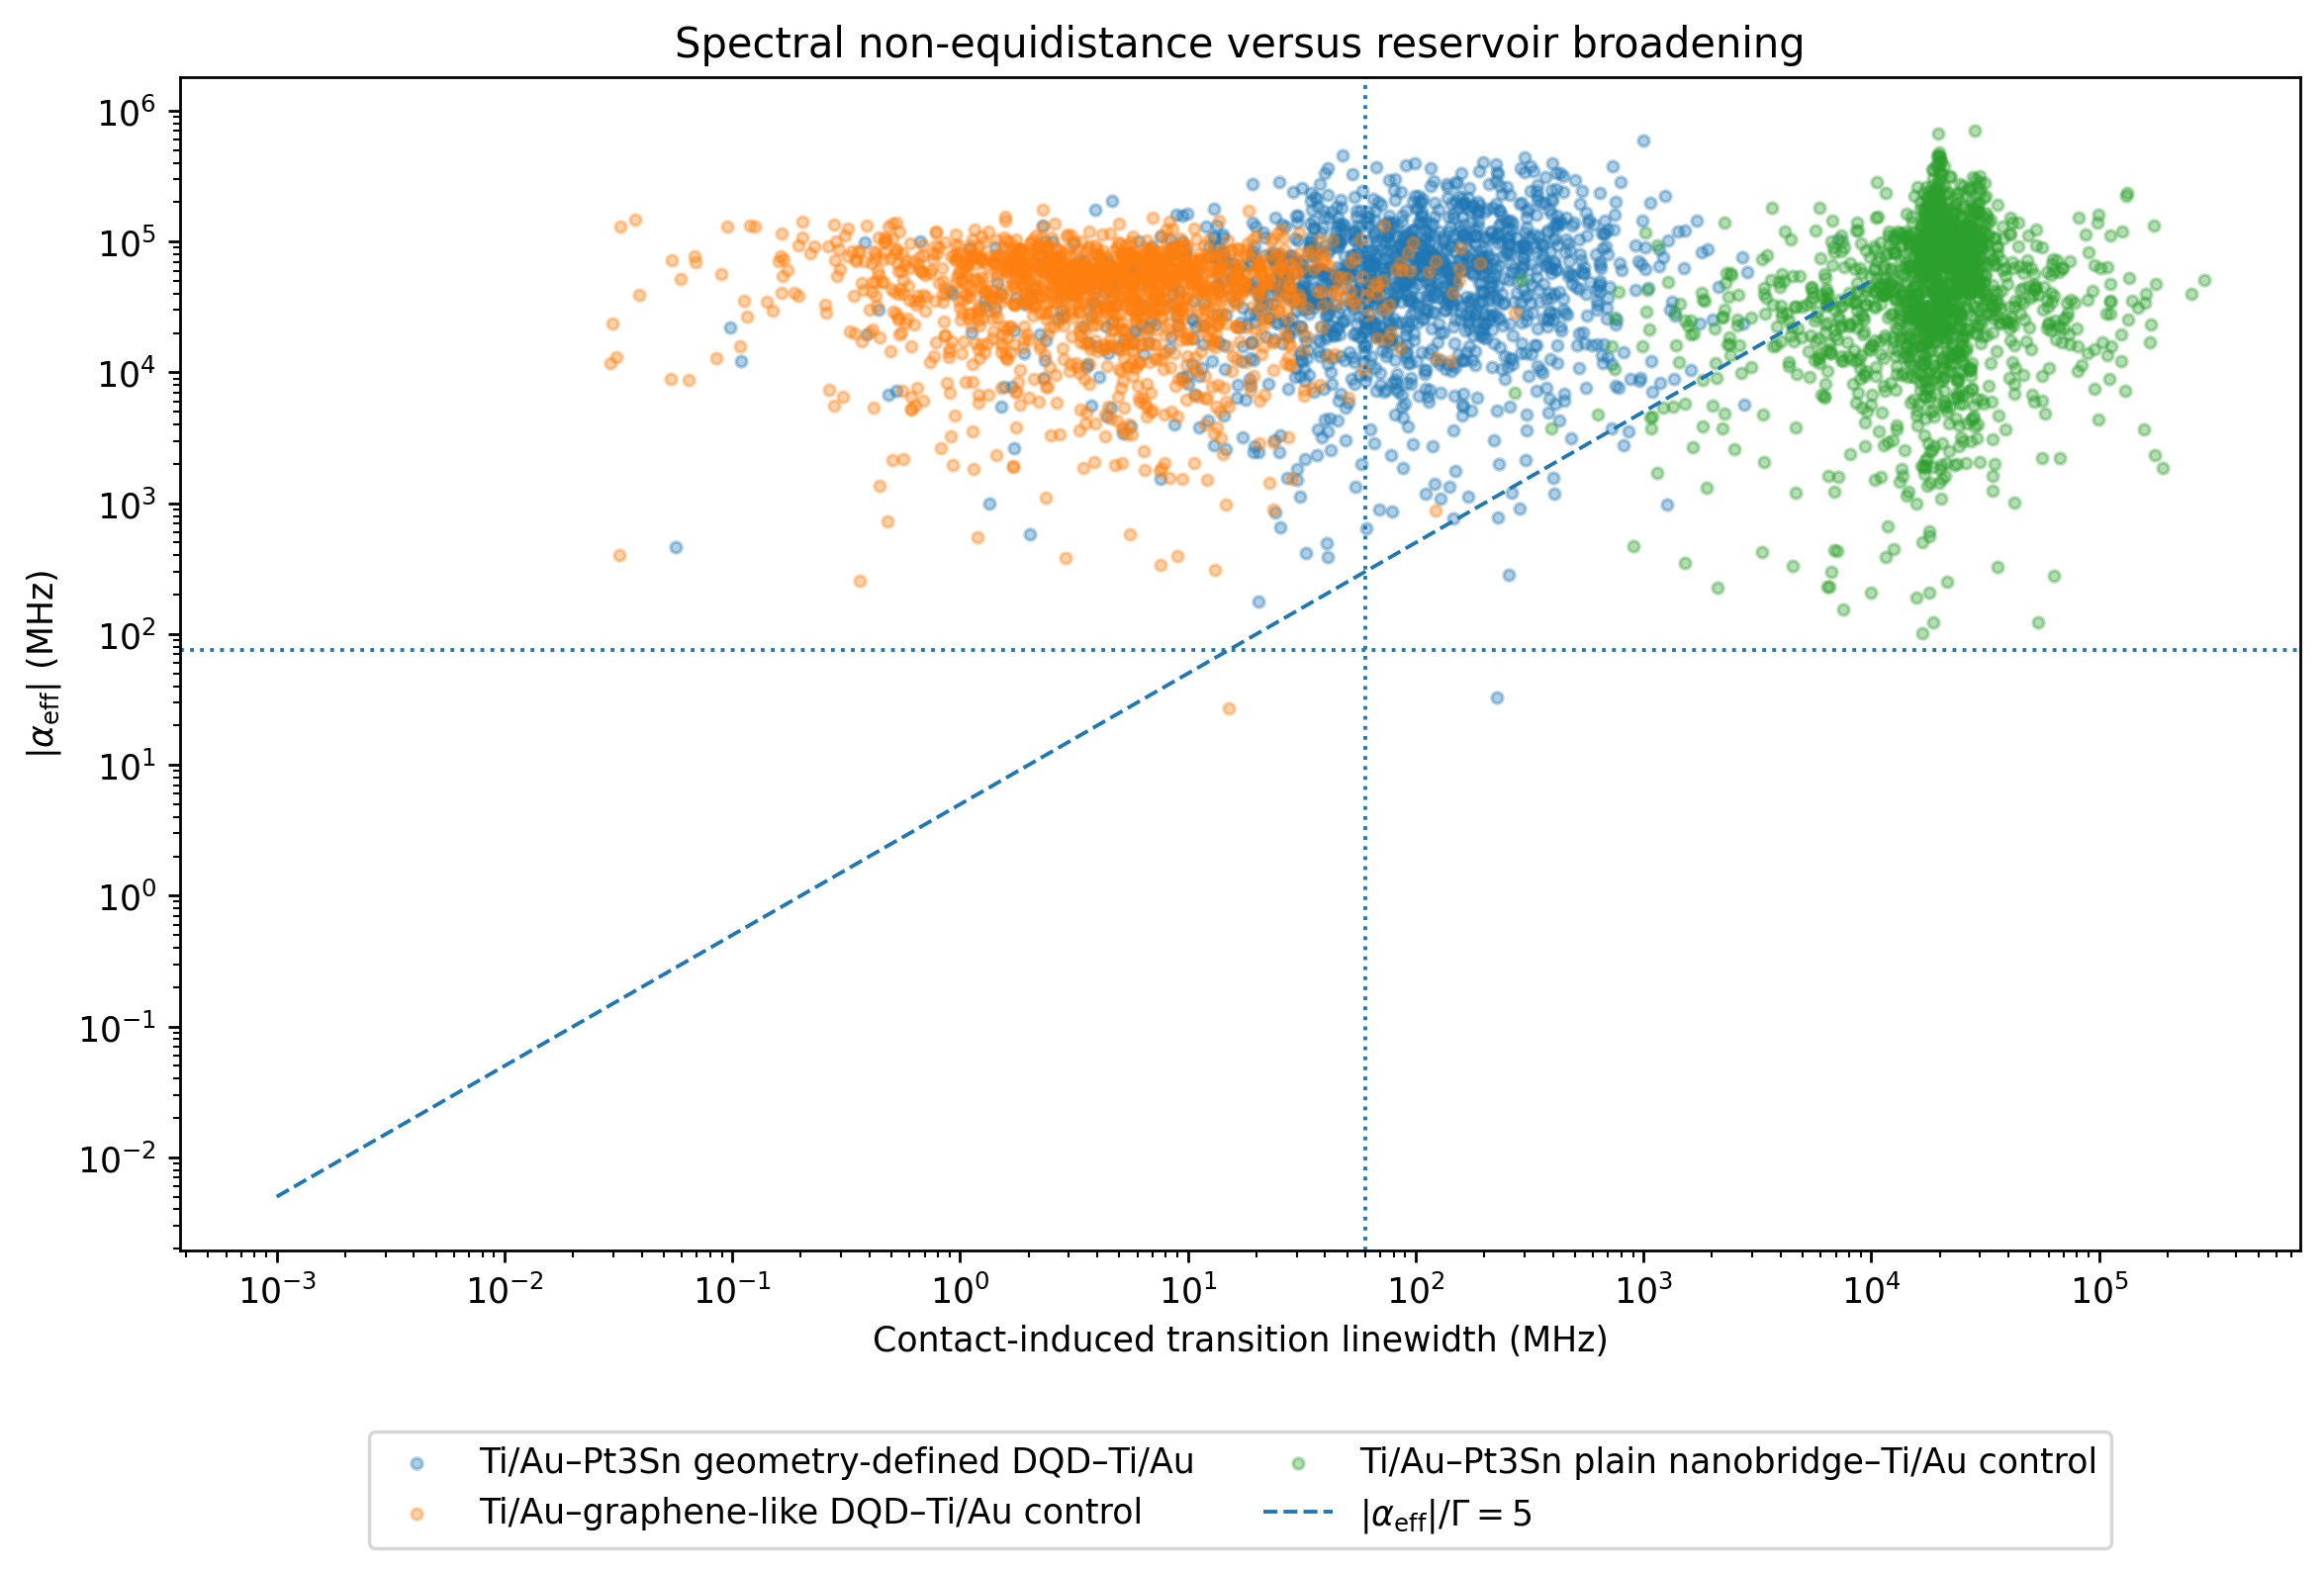

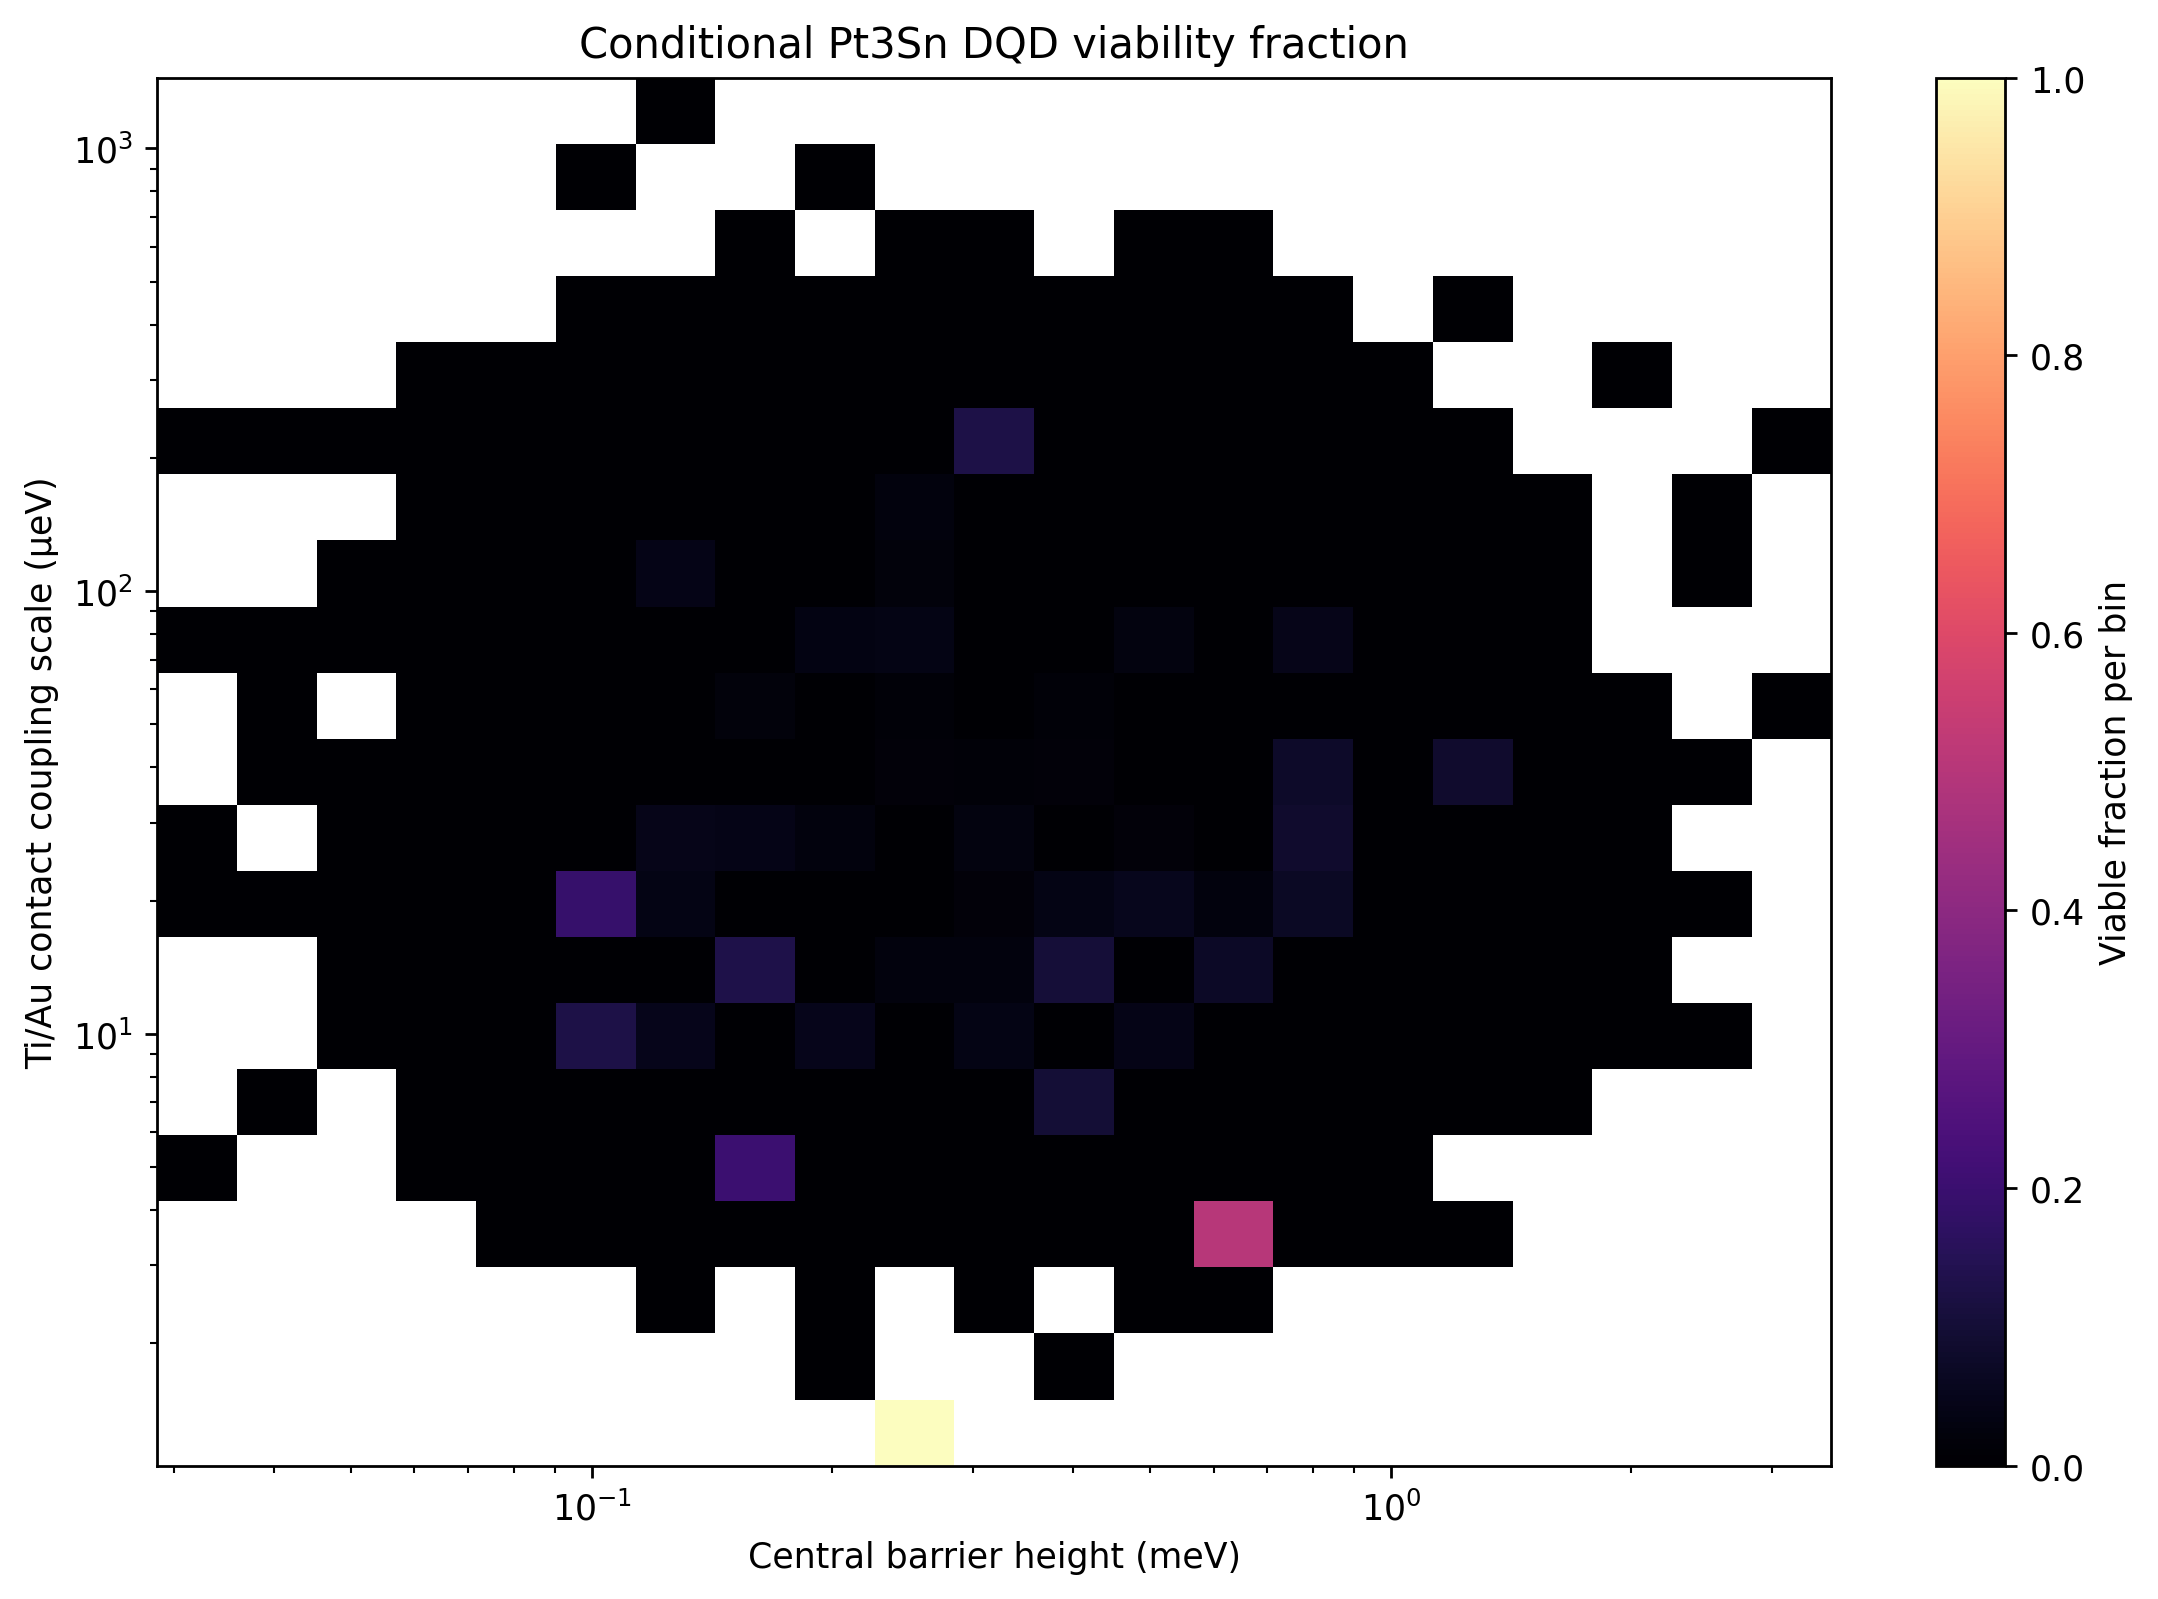

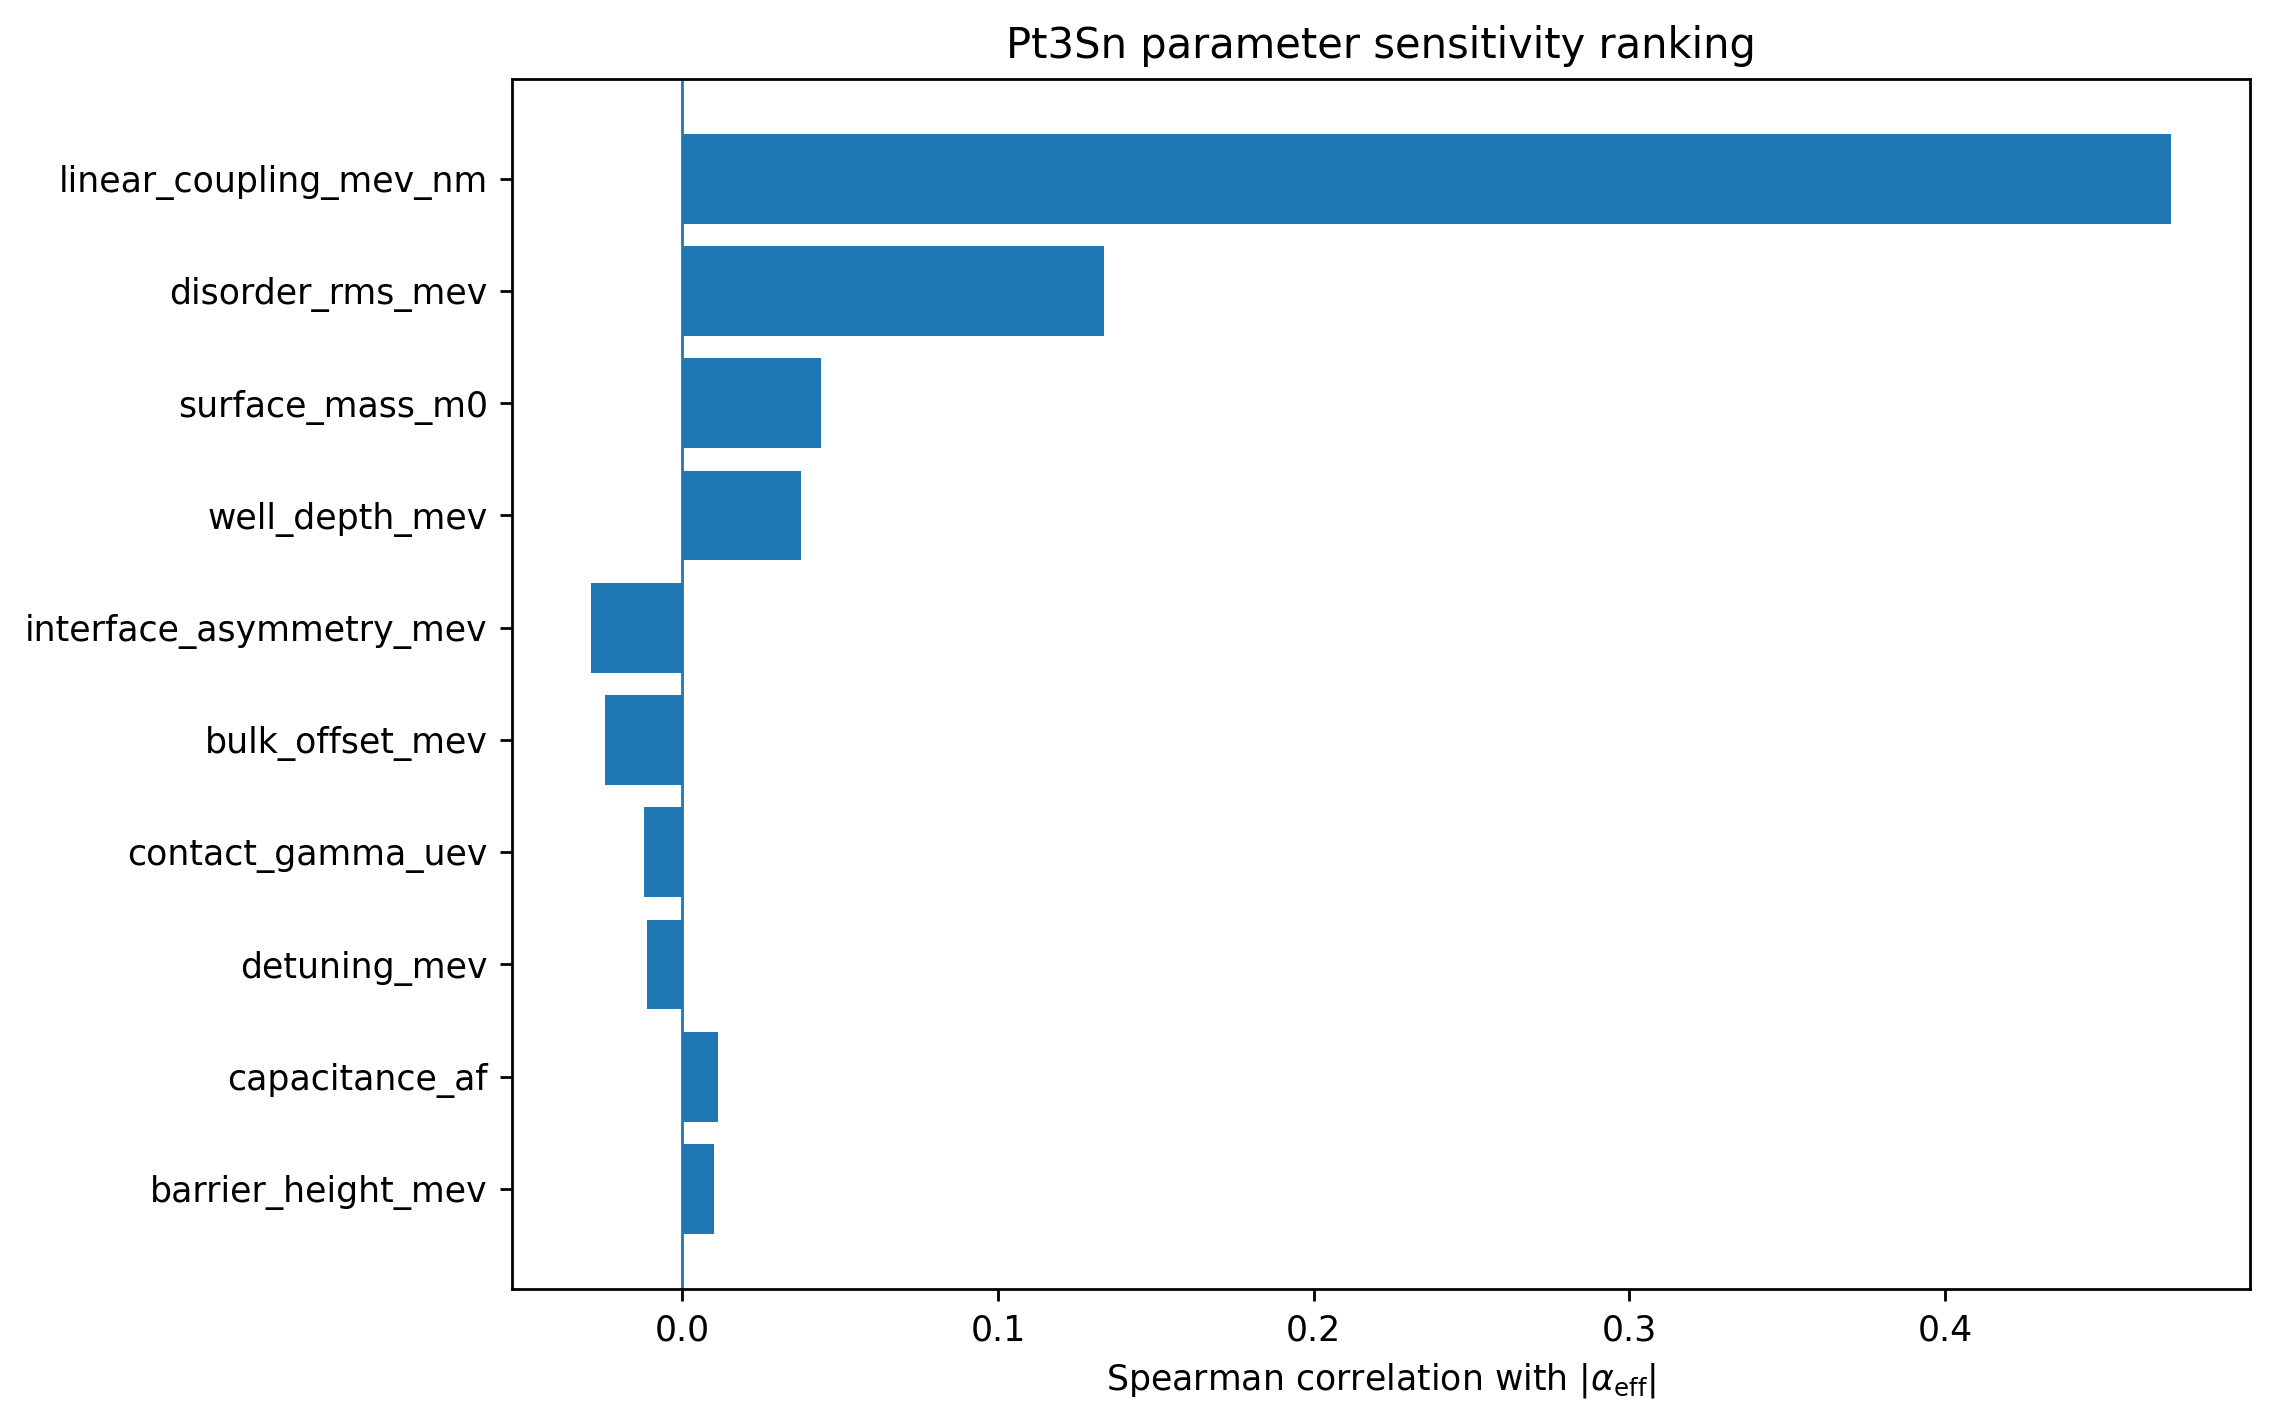

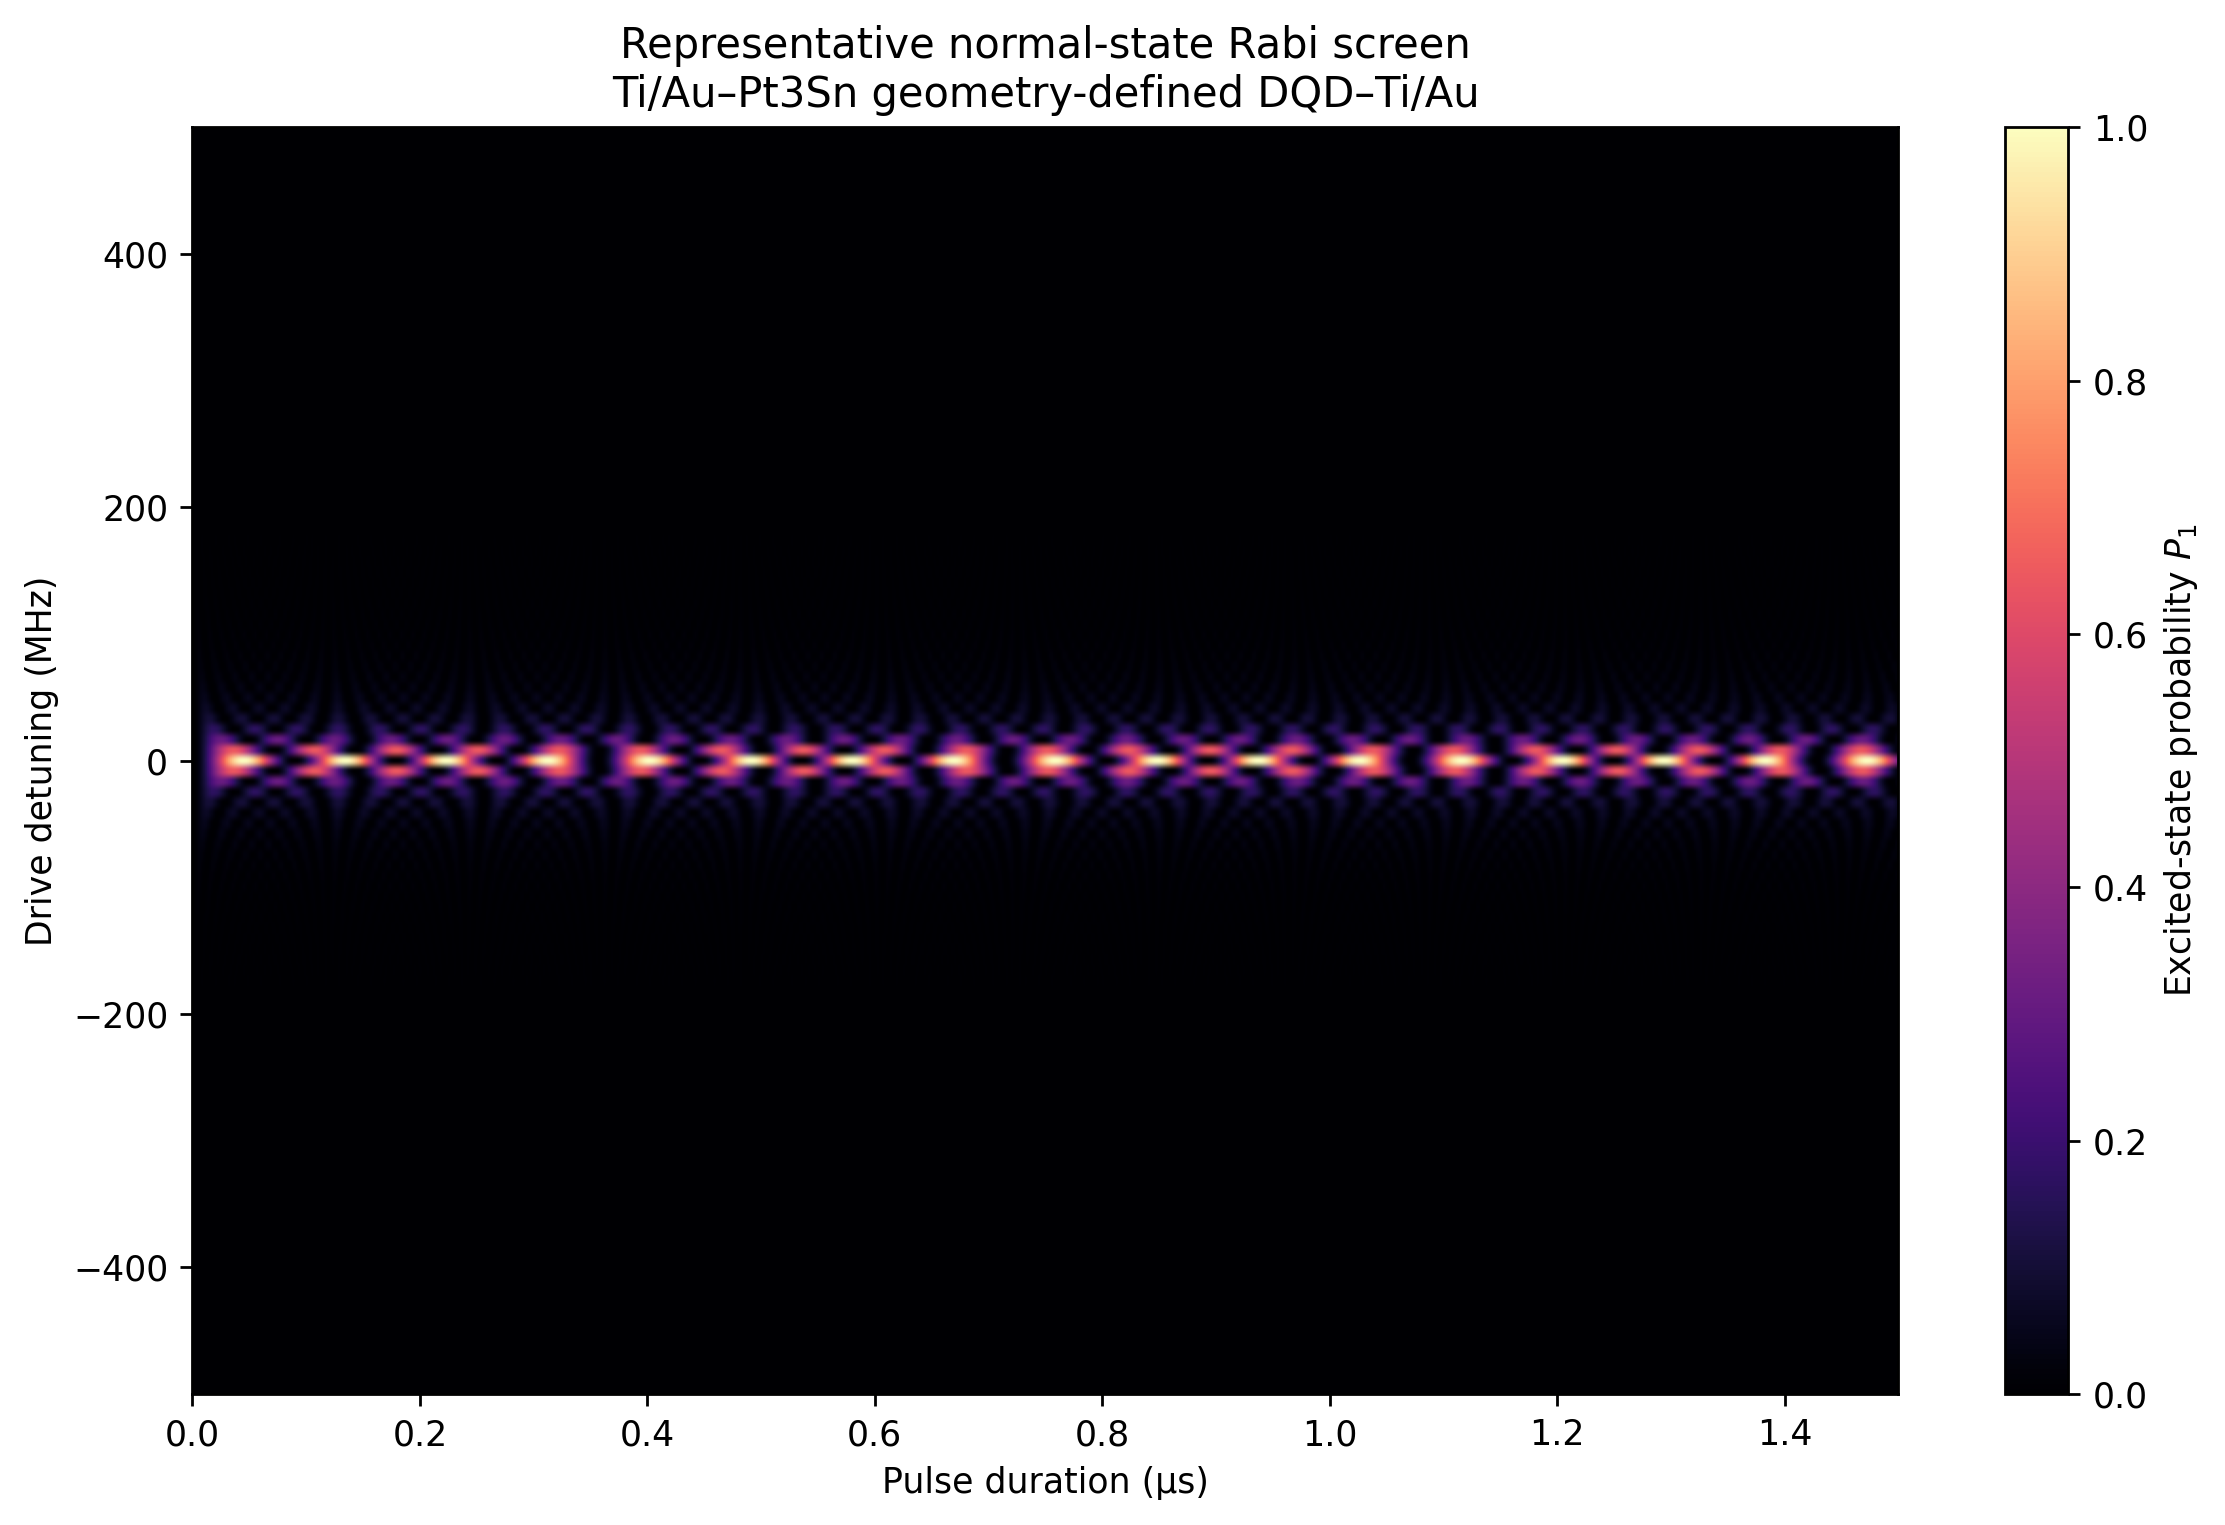


Results archive: /content/pt3sn_tiau_normal_state_screening_results.zip


In [ ]:
"""Screen oxide-free Ti/Au-contacted semimetal double-dot candidates.

This module implements a normal-state, single-electron envelope model for a
geometry-defined semimetal double quantum dot. It intentionally contains no
superconducting gap, Josephson energy, Andreev potential, or oxide tunnel
barrier. A real-space adjacency graph supplies finite-difference kinetic
operators, smooth graph-Laplacian disorder modes, contact participation, and a
reduced orbital basis. The initial Hamiltonian represents one selected
spin or Kramers sector and screens charge-orbital confinement. A spinful
extension requires downfolded spin-orbit and Zeeman matrices. CuPy performs
batched Hamiltonian construction and Hermitian diagonalization when a
compatible GPU is available.

The workflow has two statistical layers:

1. Forward Monte Carlo propagates uncertain material, interface, geometry, and
   electrostatic parameters into spectra and device-screening metrics.
2. Adaptive Metropolis-Hastings searches the same prior space for parameter
   regions that satisfy explicit qubit-like design criteria. This second layer
   is a design-conditioned ensemble, not an experimental Bayesian posterior.

The calculated ``alpha_eff`` is the spectral non-equidistance

    alpha_eff = f_12 - f_01,

of the first three confined one-electron eigenstates. For a double-dot charge
qubit, the guard band, transition dipole, charging energy, lead broadening, and
thermal initialization are at least as important as alpha_eff itself.
"""

import json
import math
import shutil
import time
import zipfile
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import sparse
from scipy.sparse import linalg as sparse_linalg
from scipy.stats import rankdata, spearmanr

try:
    import cupy as cp

    CUPY_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    cp = None
    CUPY_AVAILABLE = False


# -----------------------------------------------------------------------------
# CONTROL KNOBS
# -----------------------------------------------------------------------------

USE_CUPY = True
FAST_TEST_MODE = False
RUN_FORWARD_MONTE_CARLO = True
RUN_METROPOLIS = True
RUN_REPRESENTATIVE_RABI = True
RUN_PLAIN_BRIDGE_CONTROL = True
DOWNLOAD_RESULTS_ZIP_IN_COLAB = False

RANDOM_SEED = 20260908
PLOT_DPI = 250
OUTPUT_DIRECTORY = Path("pt3sn_tiau_normal_state_screening_results")

# Real-space device grid and geometry.
GRID_NX = 41
GRID_NY = 17
DEVICE_LENGTH_NM = 500.0
DEVICE_WIDTH_NM = 180.0
DOT_SEPARATION_NM = 210.0
DOT_SIGMA_X_NM = 75.0
DOT_SIGMA_Y_NM = 50.0
CENTRAL_BARRIER_SIGMA_X_NM = 18.0
CENTRAL_BARRIER_SIGMA_Y_NM = 55.0
CONTACT_COLUMNS = 2
TRANSVERSE_CONFINEMENT_MEV = 3.0
BASIS_EFFECTIVE_MASS_M0 = 0.12
ORBITAL_BASIS_SIZE = 24
DISORDER_MODE_COUNT = 8

# Forward uncertainty propagation.
FORWARD_SAMPLES = 384 if FAST_TEST_MODE else 4096
FORWARD_BATCH_SIZE = 96 if FAST_TEST_MODE else 256

# Adaptive parallel Metropolis-Hastings design search.
MCMC_CHAINS = 8 if FAST_TEST_MODE else 32
MCMC_STEPS = 120 if FAST_TEST_MODE else 900
MCMC_BURN_IN = 40 if FAST_TEST_MODE else 300
MCMC_THIN = 4
MCMC_INITIAL_PROPOSAL_SCALE = 0.24
MCMC_TARGET_ACCEPTANCE = 0.25
MCMC_ADAPT_INTERVAL = 20
MCMC_ADAPT_GAIN = 0.75
MCMC_PROPOSAL_SCALE_MIN = 0.025
MCMC_PROPOSAL_SCALE_MAX = 1.25
MCMC_DESIGN_WEIGHT = 1.0

# Spectral and device success criteria. These are screening thresholds.
OPERATING_TEMPERATURE_MK = 20.0
TARGET_F01_GHZ_MIN = 1.0
TARGET_F01_GHZ_MAX = 12.0
TARGET_F01_GHZ_CENTER = 5.0
TARGET_F01_GHZ_SIGMA = 3.0
MIN_ABS_ALPHA_MHZ = 75.0
MIN_DIPOLE_X01_NM = 0.35
MAX_CONTACT_LINEWIDTH_MHZ = 60.0
MIN_ALPHA_TO_LINEWIDTH = 5.0
MIN_CHARGING_TO_THERMAL = 10.0
MIN_GROUND_STATE_POPULATION = 0.95
MAX_RABI_TO_ALPHA = 0.10
AC_ELECTRIC_FIELD_V_PER_M = 2.0e3
EFFECTIVE_GATE_DRIVE_LEVER_ARM = 0.01
PLAIN_BRIDGE_CONTACT_GAMMA_FLOOR_UEV = 5.0e3
LEVELS_TO_REPORT = 6

# Representative multilevel rotating-wave calculation.
RABI_LEVEL_COUNT = 5
RABI_TIME_US = 1.5
RABI_TIME_POINTS = 900
RABI_DETUNING_MHZ = 500.0
RABI_DETUNING_POINTS = 121
RABI_ADJACENT_TRANSITIONS_ONLY = True

# Optional downfolded parameter overrides. A CSV can contain the columns
# candidate, parameter, median_or_mean, spread, lower, upper, distribution.
# Supported distributions are "lognormal" and "normal".
PARAMETER_OVERRIDE_CSV: str | None = None


# -----------------------------------------------------------------------------
# PHYSICAL CONSTANTS AND PLOTTING
# -----------------------------------------------------------------------------

E_CHARGE = 1.602_176_634e-19
PLANCK = 6.626_070_15e-34
HBAR = PLANCK / (2.0 * math.pi)
KB = 1.380_649e-23
ELECTRON_MASS = 9.109_383_7015e-31
MEV_TO_J = 1.0e-3 * E_CHARGE
MEV_TO_HZ = MEV_TO_J / PLANCK
MEV_TO_GHZ = MEV_TO_HZ / 1.0e9
MEV_TO_MHZ = MEV_TO_HZ / 1.0e6
KB_MEV_PER_K = KB / MEV_TO_J
HBAR2_OVER_2ME_MEV_NM2 = (
    HBAR**2 / (2.0 * ELECTRON_MASS) / MEV_TO_J / 1.0e-18
)

mpl.rcParams["figure.dpi"] = PLOT_DPI
mpl.rcParams["savefig.dpi"] = PLOT_DPI
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
mpl.rcParams["axes.grid"] = False


# -----------------------------------------------------------------------------
# PRIOR AND CANDIDATE DEFINITIONS
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class LogNormalPrior:
    """Describe a clipped lognormal screening prior."""

    median: float
    log_sigma: float
    lower: float
    upper: float


@dataclass(frozen=True)
class NormalPrior:
    """Describe a clipped normal screening prior."""

    mean: float
    standard_deviation: float
    lower: float
    upper: float


@dataclass(frozen=True)
class MaterialPrior:
    """Collect effective low-energy priors for one material family."""

    label: str
    surface_mass_m0: LogNormalPrior
    bulk_mass_m0: LogNormalPrior
    bulk_offset_mev: NormalPrior
    intersector_coupling_mev: LogNormalPrior
    linear_coupling_mev_nm: LogNormalPrior
    tilt_mev_nm: NormalPrior
    disorder_rms_mev: LogNormalPrior
    contact_gamma_uev: LogNormalPrior
    capacitance_af: LogNormalPrior
    well_depth_mev: LogNormalPrior
    barrier_height_mev: LogNormalPrior
    detuning_mev: NormalPrior
    interface_asymmetry_mev: NormalPrior
    bulk_contact_multiplier: float
    resistivity_uohm_cm: float | None
    sheet_resistance_ohm_sq: float | None
    provenance: str


@dataclass(frozen=True)
class Candidate:
    """Describe one material and confinement topology combination."""

    key: str
    label: str
    material_key: str
    topology: str


# The numerical values below are intentionally broad proposal-level priors.
# They are not asserted as measured Pt3Sn quantum-dot parameters. Replace them
# with periodic DFT/Wannier, low-temperature transport, and dot spectroscopy.
MATERIAL_PRIORS: dict[str, MaterialPrior] = {
    "pt3sn": MaterialPrior(
        label="Pt3Sn",
        surface_mass_m0=LogNormalPrior(0.18, 0.65, 0.025, 1.50),
        bulk_mass_m0=LogNormalPrior(0.45, 0.65, 0.05, 3.00),
        bulk_offset_mev=NormalPrior(2.5, 3.0, -4.0, 15.0),
        intersector_coupling_mev=LogNormalPrior(0.35, 0.80, 0.005, 5.0),
        linear_coupling_mev_nm=LogNormalPrior(65.0, 0.75, 1.0, 600.0),
        tilt_mev_nm=NormalPrior(18.0, 25.0, -120.0, 120.0),
        disorder_rms_mev=LogNormalPrior(0.35, 0.75, 0.01, 5.0),
        contact_gamma_uev=LogNormalPrior(40.0, 0.95, 0.1, 3000.0),
        capacitance_af=LogNormalPrior(28.0, 0.45, 3.0, 250.0),
        well_depth_mev=LogNormalPrior(1.10, 0.50, 0.08, 8.0),
        barrier_height_mev=LogNormalPrior(0.28, 0.70, 0.005, 5.0),
        detuning_mev=NormalPrior(0.0, 0.08, -0.8, 0.8),
        interface_asymmetry_mev=NormalPrior(0.0, 0.10, -1.0, 1.0),
        bulk_contact_multiplier=1.7,
        resistivity_uohm_cm=83.0,
        sheet_resistance_ohm_sq=None,
        provenance=(
            "Broad Pt3Sn normal-state screening prior; resistivity anchor only "
            "is tied to published thin-film transport."
        ),
    ),
    "graphene": MaterialPrior(
        label="graphene-like control",
        surface_mass_m0=LogNormalPrior(0.033, 0.28, 0.012, 0.12),
        bulk_mass_m0=LogNormalPrior(0.055, 0.35, 0.015, 0.25),
        bulk_offset_mev=NormalPrior(8.0, 3.0, 0.5, 25.0),
        intersector_coupling_mev=LogNormalPrior(0.08, 0.80, 0.001, 2.0),
        linear_coupling_mev_nm=LogNormalPrior(8.0, 0.95, 0.05, 200.0),
        tilt_mev_nm=NormalPrior(0.0, 3.0, -20.0, 20.0),
        disorder_rms_mev=LogNormalPrior(0.12, 0.70, 0.003, 2.0),
        contact_gamma_uev=LogNormalPrior(12.0, 0.90, 0.05, 1000.0),
        capacitance_af=LogNormalPrior(22.0, 0.40, 3.0, 200.0),
        well_depth_mev=LogNormalPrior(1.00, 0.45, 0.08, 8.0),
        barrier_height_mev=LogNormalPrior(0.24, 0.65, 0.005, 4.0),
        detuning_mev=NormalPrior(0.0, 0.06, -0.8, 0.8),
        interface_asymmetry_mev=NormalPrior(0.0, 0.06, -0.8, 0.8),
        bulk_contact_multiplier=1.0,
        resistivity_uohm_cm=None,
        sheet_resistance_ohm_sq=300.0,
        provenance=(
            "Graphene-like double-dot control used to test whether the model "
            "recovers a confined charge-qubit regime."
        ),
    ),
}

CANDIDATES = [
    Candidate(
        key="pt3sn_dqd",
        label="Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au",
        material_key="pt3sn",
        topology="double_dot",
    ),
    Candidate(
        key="graphene_dqd",
        label="Ti/Au–graphene-like DQD–Ti/Au control",
        material_key="graphene",
        topology="double_dot",
    ),
]

if RUN_PLAIN_BRIDGE_CONTROL:
    CANDIDATES.append(
        Candidate(
            key="pt3sn_plain_bridge",
            label="Ti/Au–Pt3Sn plain nanobridge–Ti/Au control",
            material_key="pt3sn",
            topology="plain_bridge",
        )
    )

BASE_LATENT_NAMES = (
    "surface_mass_m0",
    "bulk_mass_m0",
    "bulk_offset_mev",
    "intersector_coupling_mev",
    "linear_coupling_mev_nm",
    "tilt_mev_nm",
    "disorder_rms_mev",
    "contact_gamma_uev",
    "capacitance_af",
    "well_depth_mev",
    "barrier_height_mev",
    "detuning_mev",
    "interface_asymmetry_mev",
)


# -----------------------------------------------------------------------------
# GRAPH BASIS
# -----------------------------------------------------------------------------


@dataclass
class GraphBasis:
    """Store the reduced adjacency-derived operators and plotting fields."""

    x_nm: np.ndarray
    y_nm: np.ndarray
    potential_nominal_mev: np.ndarray
    contact_mask: np.ndarray
    basis_vectors: np.ndarray
    identity: np.ndarray
    k2: np.ndarray
    kx: np.ndarray
    ky: np.ndarray
    well: np.ndarray
    barrier: np.ndarray
    detuning: np.ndarray
    interface: np.ndarray
    transverse: np.ndarray
    x_operator: np.ndarray
    contact: np.ndarray
    left_right: np.ndarray
    disorder_modes: np.ndarray
    full_disorder_fields: np.ndarray


@dataclass
class BackendBasis:
    """Store one GraphBasis copied to NumPy or CuPy arrays."""

    xp: Any
    identity: Any
    k2: Any
    kx: Any
    ky: Any
    well: Any
    barrier: Any
    detuning: Any
    interface: Any
    transverse: Any
    x_operator: Any
    contact: Any
    left_right: Any
    disorder_modes: Any


@dataclass
class McmcResult:
    """Hold one design-conditioned Metropolis-Hastings result."""

    dataframe: pd.DataFrame
    acceptance: float
    burn_in_acceptance: float
    final_proposal_scale: float
    retained_iterations: int
    diagnostics: dict[str, dict[str, float]]
    backend: str


def _one_dimensional_operators(
    point_count: int,
    spacing_nm: float,
) -> tuple[sparse.csr_matrix, sparse.csr_matrix]:
    """Return positive -d2/dx2 and Hermitian -i d/dx operators."""
    main = np.full(point_count, 2.0 / spacing_nm**2)
    off = np.full(point_count - 1, -1.0 / spacing_nm**2)
    k2 = sparse.diags((off, main, off), (-1, 0, 1), format="csr")

    derivative = sparse.diags(
        (
            np.full(point_count - 1, -1.0 / (2.0 * spacing_nm)),
            np.full(point_count - 1, 1.0 / (2.0 * spacing_nm)),
        ),
        (-1, 1),
        format="csr",
    )
    momentum = (-1.0j * derivative).tocsr()
    return k2, momentum


def _grid_graph_laplacian(nx: int, ny: int) -> sparse.csr_matrix:
    """Return the unweighted rectangular-grid graph Laplacian."""
    node_count = nx * ny
    rows: list[int] = []
    columns: list[int] = []
    values: list[float] = []

    def node(x_index: int, y_index: int) -> int:
        return y_index * nx + x_index

    for y_index in range(ny):
        for x_index in range(nx):
            current = node(x_index, y_index)
            degree = 0
            for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                neighbor_x = x_index + dx
                neighbor_y = y_index + dy
                if 0 <= neighbor_x < nx and 0 <= neighbor_y < ny:
                    rows.append(current)
                    columns.append(node(neighbor_x, neighbor_y))
                    values.append(-1.0)
                    degree += 1
            rows.append(current)
            columns.append(current)
            values.append(float(degree))

    return sparse.coo_matrix(
        (values, (rows, columns)),
        shape=(node_count, node_count),
    ).tocsr()


def _project_diagonal(
    basis_vectors: np.ndarray,
    diagonal_values: np.ndarray,
) -> np.ndarray:
    """Project a real-space diagonal operator into the reduced basis."""
    return basis_vectors.conj().T @ (
        diagonal_values[:, None] * basis_vectors
    )


def _project_sparse(
    basis_vectors: np.ndarray,
    operator: sparse.spmatrix,
) -> np.ndarray:
    """Project a sparse real-space operator into the reduced basis."""
    return basis_vectors.conj().T @ (operator @ basis_vectors)


def build_graph_basis() -> GraphBasis:
    """Build the finite-difference graph and low-energy orbital basis."""
    x_axis = np.linspace(
        -0.5 * DEVICE_LENGTH_NM,
        0.5 * DEVICE_LENGTH_NM,
        GRID_NX,
    )
    y_axis = np.linspace(
        -0.5 * DEVICE_WIDTH_NM,
        0.5 * DEVICE_WIDTH_NM,
        GRID_NY,
    )
    x_grid, y_grid = np.meshgrid(x_axis, y_axis, indexing="xy")
    x_flat = x_grid.ravel()
    y_flat = y_grid.ravel()

    dx_nm = float(x_axis[1] - x_axis[0])
    dy_nm = float(y_axis[1] - y_axis[0])
    k2_x, kx_1d = _one_dimensional_operators(GRID_NX, dx_nm)
    k2_y, ky_1d = _one_dimensional_operators(GRID_NY, dy_nm)
    identity_x = sparse.identity(GRID_NX, format="csr")
    identity_y = sparse.identity(GRID_NY, format="csr")

    k2_full = (
        sparse.kron(identity_y, k2_x, format="csr")
        + sparse.kron(k2_y, identity_x, format="csr")
    )
    kx_full = sparse.kron(identity_y, kx_1d, format="csr")
    ky_full = sparse.kron(ky_1d, identity_x, format="csr")

    left_well = np.exp(
        -0.5
        * (
            ((x_flat + 0.5 * DOT_SEPARATION_NM) / DOT_SIGMA_X_NM) ** 2
            + (y_flat / DOT_SIGMA_Y_NM) ** 2
        )
    )
    right_well = np.exp(
        -0.5
        * (
            ((x_flat - 0.5 * DOT_SEPARATION_NM) / DOT_SIGMA_X_NM) ** 2
            + (y_flat / DOT_SIGMA_Y_NM) ** 2
        )
    )
    well_template = left_well + right_well
    barrier_template = np.exp(
        -0.5
        * (
            (x_flat / CENTRAL_BARRIER_SIGMA_X_NM) ** 2
            + (y_flat / CENTRAL_BARRIER_SIGMA_Y_NM) ** 2
        )
    )
    detuning_template = np.tanh(
        x_flat / max(0.18 * DOT_SEPARATION_NM, 1.0)
    )
    transverse_template = (2.0 * y_flat / DEVICE_WIDTH_NM) ** 8

    contact_mask = np.zeros((GRID_NY, GRID_NX), dtype=float)
    contact_mask[:, :CONTACT_COLUMNS] = 1.0
    contact_mask[:, -CONTACT_COLUMNS:] = 1.0
    contact_flat = contact_mask.ravel()

    left_contact = np.zeros_like(contact_mask)
    right_contact = np.zeros_like(contact_mask)
    left_contact[:, :CONTACT_COLUMNS] = 1.0
    right_contact[:, -CONTACT_COLUMNS:] = 1.0
    interface_template = (left_contact - right_contact).ravel()

    left_right_template = np.tanh(
        x_flat / max(0.12 * DOT_SEPARATION_NM, 1.0)
    )

    basis_curvature = (
        HBAR2_OVER_2ME_MEV_NM2 / BASIS_EFFECTIVE_MASS_M0
    )
    nominal_potential = (
        TRANSVERSE_CONFINEMENT_MEV * transverse_template
        - 1.0 * well_template
        + 0.25 * barrier_template
    )
    scalar_hamiltonian = (
        basis_curvature * k2_full
        + sparse.diags(nominal_potential, format="csr")
    )
    basis_count = min(
        ORBITAL_BASIS_SIZE,
        scalar_hamiltonian.shape[0] - 2,
    )
    eigenvalues, basis_vectors = sparse_linalg.eigsh(
        scalar_hamiltonian,
        k=basis_count,
        which="SA",
        tol=1.0e-10,
        maxiter=50_000,
    )
    order = np.argsort(eigenvalues)
    basis_vectors = np.asarray(basis_vectors[:, order], dtype=complex)

    graph_laplacian = _grid_graph_laplacian(GRID_NX, GRID_NY)
    mode_count = min(DISORDER_MODE_COUNT + 1, graph_laplacian.shape[0] - 1)
    mode_values, mode_vectors = sparse_linalg.eigsh(
        graph_laplacian,
        k=mode_count,
        which="SM",
        tol=1.0e-10,
        maxiter=50_000,
    )
    mode_order = np.argsort(mode_values)
    mode_vectors = mode_vectors[:, mode_order]
    full_disorder_fields = []
    for mode_index in range(1, min(mode_count, DISORDER_MODE_COUNT + 1)):
        field = np.asarray(mode_vectors[:, mode_index], dtype=float)
        field -= np.mean(field)
        field_rms = math.sqrt(float(np.mean(field**2)))
        field /= max(field_rms, np.finfo(float).tiny)
        full_disorder_fields.append(field)
    full_disorder_fields_array = np.stack(full_disorder_fields, axis=0)
    projected_disorder = np.stack(
        [
            _project_diagonal(basis_vectors, field)
            for field in full_disorder_fields_array
        ],
        axis=0,
    )

    return GraphBasis(
        x_nm=x_grid,
        y_nm=y_grid,
        potential_nominal_mev=nominal_potential.reshape(GRID_NY, GRID_NX),
        contact_mask=contact_mask,
        basis_vectors=basis_vectors,
        identity=np.eye(basis_count, dtype=complex),
        k2=_project_sparse(basis_vectors, k2_full),
        kx=_project_sparse(basis_vectors, kx_full),
        ky=_project_sparse(basis_vectors, ky_full),
        well=_project_diagonal(basis_vectors, well_template),
        barrier=_project_diagonal(basis_vectors, barrier_template),
        detuning=_project_diagonal(basis_vectors, detuning_template),
        interface=_project_diagonal(basis_vectors, interface_template),
        transverse=_project_diagonal(basis_vectors, transverse_template),
        x_operator=_project_diagonal(basis_vectors, x_flat),
        contact=_project_diagonal(basis_vectors, contact_flat),
        left_right=_project_diagonal(basis_vectors, left_right_template),
        disorder_modes=projected_disorder,
        full_disorder_fields=full_disorder_fields_array.reshape(
            len(full_disorder_fields_array), GRID_NY, GRID_NX
        ),
    )


def create_backend_basis(graph_basis: GraphBasis, xp: Any) -> BackendBasis:
    """Copy reduced operators to the active numerical backend."""

    def copy(array: np.ndarray) -> Any:
        return np.asarray(array) if xp is np else cp.asarray(array)

    return BackendBasis(
        xp=xp,
        identity=copy(graph_basis.identity),
        k2=copy(graph_basis.k2),
        kx=copy(graph_basis.kx),
        ky=copy(graph_basis.ky),
        well=copy(graph_basis.well),
        barrier=copy(graph_basis.barrier),
        detuning=copy(graph_basis.detuning),
        interface=copy(graph_basis.interface),
        transverse=copy(graph_basis.transverse),
        x_operator=copy(graph_basis.x_operator),
        contact=copy(graph_basis.contact),
        left_right=copy(graph_basis.left_right),
        disorder_modes=copy(graph_basis.disorder_modes),
    )


# -----------------------------------------------------------------------------
# PARAMETER TRANSFORMS
# -----------------------------------------------------------------------------


def latent_dimension() -> int:
    """Return the total standard-normal latent dimension."""
    return len(BASE_LATENT_NAMES) + DISORDER_MODE_COUNT


def _lognormal_transform(latent: Any, prior: LogNormalPrior, xp: Any) -> Any:
    """Map standard-normal coordinates to a clipped lognormal variable."""
    value = prior.median * xp.exp(prior.log_sigma * latent)
    return xp.clip(value, prior.lower, prior.upper)


def _normal_transform(latent: Any, prior: NormalPrior, xp: Any) -> Any:
    """Map standard-normal coordinates to a clipped normal variable."""
    value = prior.mean + prior.standard_deviation * latent
    return xp.clip(value, prior.lower, prior.upper)


def transform_latent_parameters(
    latent: Any,
    candidate: Candidate,
    xp: Any,
) -> dict[str, Any]:
    """Map latent coordinates to material and device parameters."""
    prior = MATERIAL_PRIORS[candidate.material_key]
    cursor = 0

    surface_mass = _lognormal_transform(
        latent[:, cursor], prior.surface_mass_m0, xp
    )
    cursor += 1
    bulk_mass = _lognormal_transform(
        latent[:, cursor], prior.bulk_mass_m0, xp
    )
    cursor += 1
    bulk_offset = _normal_transform(
        latent[:, cursor], prior.bulk_offset_mev, xp
    )
    cursor += 1
    intersector = _lognormal_transform(
        latent[:, cursor], prior.intersector_coupling_mev, xp
    )
    cursor += 1
    linear_coupling = _lognormal_transform(
        latent[:, cursor], prior.linear_coupling_mev_nm, xp
    )
    cursor += 1
    tilt = _normal_transform(latent[:, cursor], prior.tilt_mev_nm, xp)
    cursor += 1
    disorder_rms = _lognormal_transform(
        latent[:, cursor], prior.disorder_rms_mev, xp
    )
    cursor += 1
    contact_gamma = _lognormal_transform(
        latent[:, cursor], prior.contact_gamma_uev, xp
    )
    cursor += 1
    capacitance = _lognormal_transform(
        latent[:, cursor], prior.capacitance_af, xp
    )
    cursor += 1
    well_depth = _lognormal_transform(
        latent[:, cursor], prior.well_depth_mev, xp
    )
    cursor += 1
    barrier_height = _lognormal_transform(
        latent[:, cursor], prior.barrier_height_mev, xp
    )
    cursor += 1
    detuning = _normal_transform(
        latent[:, cursor], prior.detuning_mev, xp
    )
    cursor += 1
    interface_asymmetry = _normal_transform(
        latent[:, cursor], prior.interface_asymmetry_mev, xp
    )
    cursor += 1

    if candidate.topology == "plain_bridge":
        well_depth = 0.02 * well_depth
        barrier_height = 0.02 * barrier_height
        detuning = 0.0 * detuning
        contact_gamma = xp.clip(
            12.0 * contact_gamma,
            PLAIN_BRIDGE_CONTACT_GAMMA_FLOOR_UEV,
            20_000.0,
        )
    elif candidate.topology != "double_dot":
        raise ValueError(f"Unknown topology: {candidate.topology}")

    disorder_latent = latent[:, cursor:cursor + DISORDER_MODE_COUNT]
    disorder_coefficients = (
        disorder_rms[:, None]
        * disorder_latent
        / math.sqrt(DISORDER_MODE_COUNT)
    )

    return {
        "surface_mass_m0": surface_mass,
        "bulk_mass_m0": bulk_mass,
        "bulk_offset_mev": bulk_offset,
        "intersector_coupling_mev": intersector,
        "linear_coupling_mev_nm": linear_coupling,
        "tilt_mev_nm": tilt,
        "disorder_rms_mev": disorder_rms,
        "contact_gamma_uev": contact_gamma,
        "capacitance_af": capacitance,
        "well_depth_mev": well_depth,
        "barrier_height_mev": barrier_height,
        "detuning_mev": detuning,
        "interface_asymmetry_mev": interface_asymmetry,
        "disorder_coefficients": disorder_coefficients,
    }


def apply_parameter_overrides() -> None:
    """Apply optional external prior overrides from a compact CSV file."""
    if PARAMETER_OVERRIDE_CSV is None:
        return

    override_path = Path(PARAMETER_OVERRIDE_CSV)
    if override_path.exists() is False:
        raise FileNotFoundError(
            f"Parameter override file does not exist: {override_path}"
        )

    table = pd.read_csv(override_path)
    required = {
        "candidate",
        "parameter",
        "median_or_mean",
        "spread",
        "lower",
        "upper",
        "distribution",
    }
    missing = required.difference(table.columns)
    if missing:
        raise ValueError(
            "Parameter override CSV is missing columns: "
            + ", ".join(sorted(missing))
        )

    for _, row in table.iterrows():
        material_key = str(row["candidate"])
        parameter = str(row["parameter"])
        if material_key not in MATERIAL_PRIORS:
            raise KeyError(f"Unknown material override key: {material_key}")
        prior = MATERIAL_PRIORS[material_key]
        distribution = str(row["distribution"]).strip().lower()
        if distribution == "lognormal":
            replacement = LogNormalPrior(
                median=float(row["median_or_mean"]),
                log_sigma=float(row["spread"]),
                lower=float(row["lower"]),
                upper=float(row["upper"]),
            )
        elif distribution == "normal":
            replacement = NormalPrior(
                mean=float(row["median_or_mean"]),
                standard_deviation=float(row["spread"]),
                lower=float(row["lower"]),
                upper=float(row["upper"]),
            )
        else:
            raise ValueError(
                f"Unsupported override distribution: {distribution}"
            )
        if hasattr(prior, parameter) is False:
            raise KeyError(
                f"Unknown parameter {parameter!r} for {material_key!r}."
            )
        MATERIAL_PRIORS[material_key] = replace(
            prior, **{parameter: replacement}
        )


# -----------------------------------------------------------------------------
# BATCHED HAMILTONIAN AND METRICS
# -----------------------------------------------------------------------------


def _batch_outer_scale(values: Any, matrix: Any) -> Any:
    """Return values[:, None, None] times one reduced matrix."""
    return values[:, None, None] * matrix[None, :, :]


def build_hamiltonian_batch(
    parameters: dict[str, Any],
    candidate: Candidate,
    basis: BackendBasis,
) -> Any:
    """Build the two-sector normal-state Hamiltonian in meV."""
    xp = basis.xp
    sample_count = int(parameters["surface_mass_m0"].shape[0])
    fixed_potential = (
        TRANSVERSE_CONFINEMENT_MEV * basis.transverse
    )
    potential = xp.broadcast_to(
        fixed_potential[None, :, :],
        (sample_count,) + fixed_potential.shape,
    ).copy()
    potential -= _batch_outer_scale(
        parameters["well_depth_mev"], basis.well
    )
    potential += _batch_outer_scale(
        parameters["barrier_height_mev"], basis.barrier
    )
    potential += _batch_outer_scale(
        parameters["detuning_mev"], basis.detuning
    )
    potential += _batch_outer_scale(
        parameters["interface_asymmetry_mev"], basis.interface
    )
    potential += xp.einsum(
        "bm,mij->bij",
        parameters["disorder_coefficients"],
        basis.disorder_modes,
        optimize=True,
    )

    surface_curvature = (
        HBAR2_OVER_2ME_MEV_NM2 / parameters["surface_mass_m0"]
    )
    bulk_curvature = (
        HBAR2_OVER_2ME_MEV_NM2 / parameters["bulk_mass_m0"]
    )

    surface_block = potential + _batch_outer_scale(
        surface_curvature, basis.k2
    )
    surface_block += _batch_outer_scale(
        parameters["tilt_mev_nm"], basis.kx
    )

    bulk_block = potential + _batch_outer_scale(
        bulk_curvature, basis.k2
    )
    bulk_block += _batch_outer_scale(
        parameters["bulk_offset_mev"], basis.identity
    )
    bulk_block -= _batch_outer_scale(
        0.35 * parameters["tilt_mev_nm"], basis.kx
    )

    complex_momentum = basis.kx - 1.0j * basis.ky
    coupling_block = _batch_outer_scale(
        parameters["intersector_coupling_mev"], basis.identity
    )
    coupling_block += _batch_outer_scale(
        parameters["linear_coupling_mev_nm"], complex_momentum
    )

    upper = xp.concatenate((surface_block, coupling_block), axis=2)
    lower = xp.concatenate(
        (
            xp.swapaxes(xp.conj(coupling_block), 1, 2),
            bulk_block,
        ),
        axis=2,
    )
    hamiltonian = xp.concatenate((upper, lower), axis=1)
    return 0.5 * (
        hamiltonian + xp.swapaxes(xp.conj(hamiltonian), 1, 2)
    )


def _full_block_operator(
    operator: Any,
    second_block_multiplier: float,
    xp: Any,
) -> Any:
    """Return a two-sector block-diagonal operator."""
    zero = xp.zeros_like(operator)
    upper = xp.concatenate((operator, zero), axis=1)
    lower = xp.concatenate(
        (zero, second_block_multiplier * operator), axis=1
    )
    return xp.concatenate((upper, lower), axis=0)


def _expectation_batch(vectors: Any, operator: Any, xp: Any) -> Any:
    """Return batched real expectation values for state vectors."""
    return xp.real(
        xp.einsum(
            "bi,ij,bj->b",
            xp.conj(vectors),
            operator,
            vectors,
            optimize=True,
        )
    )


def _matrix_element_batch(
    vectors_a: Any,
    operator: Any,
    vectors_b: Any,
    xp: Any,
) -> Any:
    """Return batched absolute transition matrix elements."""
    return xp.abs(
        xp.einsum(
            "bi,ij,bj->b",
            xp.conj(vectors_a),
            operator,
            vectors_b,
            optimize=True,
        )
    )


def calculate_metrics_batch(
    latent: Any,
    candidate: Candidate,
    basis: BackendBasis,
    return_eigensystem: bool = False,
) -> dict[str, Any]:
    """Calculate spectra, linewidths, dipoles, and screening metrics."""
    xp = basis.xp
    parameters = transform_latent_parameters(latent, candidate, xp)
    hamiltonian = build_hamiltonian_batch(parameters, candidate, basis)
    eigenvalues, eigenvectors = xp.linalg.eigh(hamiltonian)
    level_count = min(LEVELS_TO_REPORT, int(eigenvalues.shape[1]))
    levels = eigenvalues[:, :level_count]
    levels = levels - levels[:, :1]

    f01_ghz = (levels[:, 1] - levels[:, 0]) * MEV_TO_GHZ
    f12_ghz = (levels[:, 2] - levels[:, 1]) * MEV_TO_GHZ
    alpha_mhz = (f12_ghz - f01_ghz) * 1.0e3
    abs_alpha_mhz = xp.abs(alpha_mhz)

    x_full = _full_block_operator(basis.x_operator, 1.0, xp)
    contact_full = _full_block_operator(
        basis.contact,
        MATERIAL_PRIORS[candidate.material_key].bulk_contact_multiplier,
        xp,
    )
    left_right_full = _full_block_operator(basis.left_right, 1.0, xp)
    orbital_count = int(basis.identity.shape[0])
    surface_projector = xp.zeros(
        (2 * orbital_count, 2 * orbital_count),
        dtype=xp.complex128,
    )
    surface_projector[:orbital_count, :orbital_count] = xp.eye(
        orbital_count, dtype=xp.complex128
    )

    state_0 = eigenvectors[:, :, 0]
    state_1 = eigenvectors[:, :, 1]
    state_2 = eigenvectors[:, :, 2]

    x01_nm = _matrix_element_batch(state_0, x_full, state_1, xp)
    x12_nm = _matrix_element_batch(state_1, x_full, state_2, xp)
    x02_nm = _matrix_element_batch(state_0, x_full, state_2, xp)

    contact_0 = _expectation_batch(state_0, contact_full, xp)
    contact_1 = _expectation_batch(state_1, contact_full, xp)
    contact_2 = _expectation_batch(state_2, contact_full, xp)
    contact_gamma_mev = parameters["contact_gamma_uev"] * 1.0e-3
    gamma_0_mev = contact_gamma_mev * contact_0
    gamma_1_mev = contact_gamma_mev * contact_1
    gamma_2_mev = contact_gamma_mev * contact_2
    transition_linewidth_mhz = (
        0.5 * (gamma_0_mev + gamma_1_mev) * MEV_TO_MHZ
    )

    surface_0 = _expectation_batch(state_0, surface_projector, xp)
    surface_1 = _expectation_batch(state_1, surface_projector, xp)
    surface_2 = _expectation_batch(state_2, surface_projector, xp)
    polarization_0 = _expectation_batch(state_0, left_right_full, xp)
    polarization_1 = _expectation_batch(state_1, left_right_full, xp)

    capacitance_f = parameters["capacitance_af"] * 1.0e-18
    charging_energy_mev = (
        E_CHARGE**2 / (2.0 * capacitance_f) / MEV_TO_J
    )
    temperature_k = OPERATING_TEMPERATURE_MK * 1.0e-3
    thermal_energy_mev = KB_MEV_PER_K * temperature_k
    thermal_weights = xp.exp(
        -xp.clip(levels / max(thermal_energy_mev, 1.0e-15), 0.0, 745.0)
    )
    ground_population = thermal_weights[:, 0] / xp.sum(
        thermal_weights,
        axis=1,
    )

    drive_energy_mev = (
        EFFECTIVE_GATE_DRIVE_LEVER_ARM
        * AC_ELECTRIC_FIELD_V_PER_M
        * x01_nm
        * 1.0e-6
    )
    rabi_mhz = 0.5 * drive_energy_mev * MEV_TO_MHZ
    rabi_to_alpha = rabi_mhz / xp.maximum(abs_alpha_mhz, 1.0e-12)
    alpha_to_linewidth = abs_alpha_mhz / xp.maximum(
        transition_linewidth_mhz, 1.0e-12
    )
    charging_to_thermal = charging_energy_mev / max(
        thermal_energy_mev, 1.0e-15
    )

    in_frequency_window = (
        (f01_ghz >= TARGET_F01_GHZ_MIN)
        & (f01_ghz <= TARGET_F01_GHZ_MAX)
    )
    viable = (
        in_frequency_window
        & (abs_alpha_mhz >= MIN_ABS_ALPHA_MHZ)
        & (x01_nm >= MIN_DIPOLE_X01_NM)
        & (transition_linewidth_mhz <= MAX_CONTACT_LINEWIDTH_MHZ)
        & (alpha_to_linewidth >= MIN_ALPHA_TO_LINEWIDTH)
        & (charging_to_thermal >= MIN_CHARGING_TO_THERMAL)
        & (ground_population >= MIN_GROUND_STATE_POPULATION)
        & (rabi_to_alpha <= MAX_RABI_TO_ALPHA)
    )

    # Smooth design score used only for Metropolis search. Zero is ideal;
    # increasingly negative values indicate larger violations.
    frequency_penalty = (
        (f01_ghz - TARGET_F01_GHZ_CENTER) / TARGET_F01_GHZ_SIGMA
    ) ** 2
    alpha_penalty = (
        xp.maximum(MIN_ABS_ALPHA_MHZ - abs_alpha_mhz, 0.0)
        / MIN_ABS_ALPHA_MHZ
    ) ** 2
    dipole_penalty = (
        xp.maximum(MIN_DIPOLE_X01_NM - x01_nm, 0.0)
        / MIN_DIPOLE_X01_NM
    ) ** 2
    linewidth_penalty = (
        xp.maximum(
            transition_linewidth_mhz - MAX_CONTACT_LINEWIDTH_MHZ,
            0.0,
        )
        / MAX_CONTACT_LINEWIDTH_MHZ
    ) ** 2
    separation_penalty = (
        xp.maximum(
            MIN_ALPHA_TO_LINEWIDTH - alpha_to_linewidth,
            0.0,
        )
        / MIN_ALPHA_TO_LINEWIDTH
    ) ** 2
    thermal_penalty = (
        xp.maximum(
            MIN_GROUND_STATE_POPULATION - ground_population,
            0.0,
        )
        / max(1.0 - MIN_GROUND_STATE_POPULATION, 0.01)
    ) ** 2
    rabi_penalty = (
        xp.maximum(rabi_to_alpha - MAX_RABI_TO_ALPHA, 0.0)
        / MAX_RABI_TO_ALPHA
    ) ** 2
    design_score = -0.5 * (
        frequency_penalty
        + 4.0 * alpha_penalty
        + 2.0 * dipole_penalty
        + 3.0 * linewidth_penalty
        + 3.0 * separation_penalty
        + thermal_penalty
        + 2.0 * rabi_penalty
    )

    output: dict[str, Any] = {
        **parameters,
        "levels_mev": levels,
        "f01_ghz": f01_ghz,
        "f12_ghz": f12_ghz,
        "alpha_eff_mhz": alpha_mhz,
        "abs_alpha_eff_mhz": abs_alpha_mhz,
        "x01_nm": x01_nm,
        "x12_nm": x12_nm,
        "x02_nm": x02_nm,
        "contact_participation_0": contact_0,
        "contact_participation_1": contact_1,
        "contact_participation_2": contact_2,
        "contact_linewidth_mhz": transition_linewidth_mhz,
        "surface_participation_0": surface_0,
        "surface_participation_1": surface_1,
        "surface_participation_2": surface_2,
        "left_right_polarization_0": polarization_0,
        "left_right_polarization_1": polarization_1,
        "charging_energy_mev": charging_energy_mev,
        "charging_to_thermal": charging_to_thermal,
        "ground_state_population": ground_population,
        "rabi_mhz": rabi_mhz,
        "rabi_to_abs_alpha": rabi_to_alpha,
        "alpha_to_linewidth": alpha_to_linewidth,
        "design_score": design_score,
        "viable": viable,
    }
    if return_eigensystem:
        output["hamiltonian_mev"] = hamiltonian
        output["eigenvectors"] = eigenvectors
    return output


def calculate_log_target(
    latent: Any,
    candidate: Candidate,
    basis: BackendBasis,
) -> tuple[Any, dict[str, Any]]:
    """Return prior plus design-conditioned log density and metrics."""
    xp = basis.xp
    metrics = calculate_metrics_batch(latent, candidate, basis)
    log_prior = -0.5 * xp.sum(latent**2, axis=1)
    log_target = log_prior + MCMC_DESIGN_WEIGHT * metrics["design_score"]
    valid = xp.isfinite(log_target) & xp.isfinite(metrics["f01_ghz"])
    return xp.where(valid, log_target, -xp.inf), metrics


def array_to_numpy(value: Any, xp: Any) -> np.ndarray:
    """Copy an array from NumPy or CuPy to NumPy."""
    if xp is np:
        return np.asarray(value)
    return cp.asnumpy(value)


def _direct_bridge_resistance(candidate: Candidate) -> float:
    """Return a simple continuum resistance diagnostic in ohms."""
    prior = MATERIAL_PRIORS[candidate.material_key]
    aspect_ratio = DEVICE_LENGTH_NM / DEVICE_WIDTH_NM
    if prior.sheet_resistance_ohm_sq is not None:
        return prior.sheet_resistance_ohm_sq * aspect_ratio
    if prior.resistivity_uohm_cm is not None:
        thickness_nm = 20.0
        rho_ohm_m = prior.resistivity_uohm_cm * 1.0e-8
        return (
            rho_ohm_m
            * DEVICE_LENGTH_NM
            * 1.0e-9
            / (DEVICE_WIDTH_NM * 1.0e-9 * thickness_nm * 1.0e-9)
        )
    return float("nan")


def metrics_to_dataframe(
    latent_numpy: np.ndarray,
    metrics: dict[str, Any],
    candidate: Candidate,
    xp: Any,
) -> pd.DataFrame:
    """Convert batched metrics and latent coordinates into a table."""
    data: dict[str, Any] = {
        "candidate_key": np.repeat(candidate.key, len(latent_numpy)),
        "candidate": np.repeat(candidate.label, len(latent_numpy)),
        "material": np.repeat(
            MATERIAL_PRIORS[candidate.material_key].label,
            len(latent_numpy),
        ),
        "topology": np.repeat(candidate.topology, len(latent_numpy)),
        "direct_bridge_resistance_ohm": np.repeat(
            _direct_bridge_resistance(candidate), len(latent_numpy)
        ),
    }
    for index, name in enumerate(BASE_LATENT_NAMES):
        data[f"z_{name}"] = latent_numpy[:, index]
    for mode_index in range(DISORDER_MODE_COUNT):
        data[f"z_disorder_mode_{mode_index + 1}"] = latent_numpy[
            :, len(BASE_LATENT_NAMES) + mode_index
        ]

    skipped = {
        "levels_mev",
        "disorder_coefficients",
        "hamiltonian_mev",
        "eigenvectors",
    }
    for name, value in metrics.items():
        if name in skipped:
            continue
        value_numpy = array_to_numpy(value, xp)
        if value_numpy.ndim == 1:
            data[name] = value_numpy

    level_array = array_to_numpy(metrics["levels_mev"], xp)
    for level_index in range(level_array.shape[1]):
        data[f"E{level_index}_mev"] = level_array[:, level_index]
        data[f"E{level_index}_ghz"] = (
            level_array[:, level_index] * MEV_TO_GHZ
        )
    return pd.DataFrame(data)


# -----------------------------------------------------------------------------
# FORWARD MONTE CARLO
# -----------------------------------------------------------------------------


def run_forward_monte_carlo(
    candidate: Candidate,
    graph_basis: GraphBasis,
    seed_offset: int,
) -> pd.DataFrame:
    """Run forward prior sampling with batched CPU or GPU diagonalization."""
    use_gpu = USE_CUPY and CUPY_AVAILABLE
    xp = cp if use_gpu else np
    backend_basis = create_backend_basis(graph_basis, xp)
    rng = np.random.default_rng(RANDOM_SEED + seed_offset)
    latent_all = rng.standard_normal(
        (FORWARD_SAMPLES, latent_dimension())
    )
    tables = []

    start_time = time.perf_counter()
    for start in range(0, FORWARD_SAMPLES, FORWARD_BATCH_SIZE):
        stop = min(start + FORWARD_BATCH_SIZE, FORWARD_SAMPLES)
        latent_numpy = latent_all[start:stop]
        latent_backend = (
            latent_numpy if xp is np else cp.asarray(latent_numpy)
        )
        metrics = calculate_metrics_batch(
            latent_backend,
            candidate,
            backend_basis,
        )
        tables.append(
            metrics_to_dataframe(
                latent_numpy,
                metrics,
                candidate,
                xp,
            )
        )
    elapsed = time.perf_counter() - start_time
    table = pd.concat(tables, ignore_index=True)
    table["backend"] = "CuPy GPU" if use_gpu else "NumPy CPU"
    table["elapsed_seconds"] = elapsed
    return table


# -----------------------------------------------------------------------------
# MCMC DIAGNOSTICS
# -----------------------------------------------------------------------------


def split_chain_matrix(chain_values: np.ndarray) -> np.ndarray:
    """Split each MCMC chain into two equal-length chains."""
    values = np.asarray(chain_values, dtype=float)
    iterations, chains = values.shape
    half = iterations // 2
    if half < 2 or chains < 2:
        return values
    return np.concatenate((values[:half], values[-half:]), axis=1)


def basic_rhat(chain_values: np.ndarray) -> float:
    """Return the conventional Gelman-Rubin R-hat statistic."""
    values = np.asarray(chain_values, dtype=float)
    iterations, chains = values.shape
    if iterations < 2 or chains < 2:
        return float("nan")
    chain_means = np.mean(values, axis=0)
    within = float(np.mean(np.var(values, axis=0, ddof=1)))
    if within <= np.finfo(float).tiny:
        return 1.0
    between = iterations * float(np.var(chain_means, ddof=1))
    estimate = (
        (iterations - 1.0) / iterations * within
        + between / iterations
    )
    return float(math.sqrt(max(estimate / within, 0.0)))


def rank_normalize(chain_values: np.ndarray) -> np.ndarray:
    """Rank-normalize pooled chains using the Blom transformation."""
    values = np.asarray(chain_values, dtype=float)
    ranks = rankdata(values.ravel(), method="average")
    sample_count = ranks.size
    probabilities = (
        ranks - 3.0 / 8.0
    ) / (
        sample_count + 1.0 / 4.0
    )
    probabilities = np.clip(probabilities, 1.0e-12, 1.0 - 1.0e-12)
    from scipy.special import ndtri

    return ndtri(probabilities).reshape(values.shape)


def autocovariance_fft(values: np.ndarray) -> np.ndarray:
    """Return lag-corrected autocovariance via an FFT."""
    series = np.asarray(values, dtype=float)
    series -= np.mean(series)
    sample_count = len(series)
    if sample_count < 2:
        return np.zeros(1, dtype=float)
    fft_length = 1 << (2 * sample_count - 1).bit_length()
    transform = np.fft.rfft(series, n=fft_length)
    autocovariance = np.fft.irfft(
        transform * np.conj(transform), n=fft_length
    )[:sample_count]
    autocovariance /= np.arange(sample_count, 0, -1, dtype=float)
    return autocovariance


def effective_sample_size(chain_values: np.ndarray) -> float:
    """Estimate ESS with an initial-positive paired correlation sequence."""
    values = np.asarray(chain_values, dtype=float)
    iterations, chains = values.shape
    total = iterations * chains
    if iterations < 3 or chains < 2:
        return float(total)

    chain_variances = np.var(values, axis=0, ddof=1)
    within = float(np.mean(chain_variances))
    if within <= np.finfo(float).tiny:
        return float(total)
    between = iterations * float(np.var(np.mean(values, axis=0), ddof=1))
    variance = (
        (iterations - 1.0) / iterations * within
        + between / iterations
    )
    autocovariances = np.column_stack(
        [autocovariance_fft(values[:, index]) for index in range(chains)]
    )
    mean_autocovariance = np.mean(autocovariances, axis=1)
    rho = 1.0 - (within - mean_autocovariance) / max(
        variance, np.finfo(float).tiny
    )
    rho[0] = 1.0

    pair_sums = []
    previous = float("inf")
    for pair_index in range((iterations - 1) // 2):
        lag_a = 2 * pair_index + 1
        lag_b = lag_a + 1
        pair_sum = float(rho[lag_a] + rho[lag_b])
        if pair_sum < 0.0:
            break
        pair_sum = min(pair_sum, previous)
        previous = pair_sum
        pair_sums.append(pair_sum)
    autocorrelation_time = max(1.0 + 2.0 * sum(pair_sums), 1.0)
    return float(np.clip(total / autocorrelation_time, 1.0, total))


def chain_diagnostics(chain_values: np.ndarray) -> dict[str, float]:
    """Return split rank-normalized R-hat and bulk ESS."""
    split_values = split_chain_matrix(chain_values)
    normalized = rank_normalize(split_values)
    folded = np.abs(split_values - np.median(split_values))
    folded_normalized = rank_normalize(folded)
    return {
        "rhat": max(basic_rhat(normalized), basic_rhat(folded_normalized)),
        "bulk_ess": effective_sample_size(normalized),
    }


# -----------------------------------------------------------------------------
# ADAPTIVE METROPOLIS-HASTINGS
# -----------------------------------------------------------------------------


def _backend_random_normal(rng: Any, shape: tuple[int, ...], xp: Any) -> Any:
    """Generate standard-normal samples with NumPy or CuPy."""
    if xp is np:
        return rng.standard_normal(shape)
    return rng.standard_normal(shape, dtype=cp.float64)


def _backend_random_uniform(rng: Any, shape: tuple[int, ...], xp: Any) -> Any:
    """Generate uniform samples with NumPy or CuPy."""
    if xp is np:
        return rng.random(shape)
    return rng.random_sample(shape, dtype=cp.float64)


def run_metropolis_hastings(
    candidate: Candidate,
    graph_basis: GraphBasis,
    seed_offset: int,
) -> McmcResult:
    """Run adaptive parallel Metropolis-Hastings for one candidate."""
    use_gpu = USE_CUPY and CUPY_AVAILABLE
    xp = cp if use_gpu else np
    basis = create_backend_basis(graph_basis, xp)
    seed = RANDOM_SEED + 100_003 + seed_offset
    rng = (
        np.random.default_rng(seed)
        if xp is np
        else cp.random.RandomState(seed)
    )
    state = xp.zeros(
        (MCMC_CHAINS, latent_dimension()), dtype=xp.float64
    )
    current_log_target, _ = calculate_log_target(state, candidate, basis)
    if np.all(np.isfinite(array_to_numpy(current_log_target, xp))) is False:
        raise RuntimeError(
            f"Invalid initial MCMC state for {candidate.label}."
        )

    retained_states = []
    proposal_scale = MCMC_INITIAL_PROPOSAL_SCALE
    burn_accepted = 0
    burn_proposed = 0
    sample_accepted = 0
    sample_proposed = 0
    window_accepted = 0
    window_proposed = 0

    start_time = time.perf_counter()
    for step_index in range(MCMC_STEPS):
        proposal = state + proposal_scale * _backend_random_normal(
            rng, state.shape, xp
        )
        proposal_log_target, _ = calculate_log_target(
            proposal, candidate, basis
        )
        log_acceptance = proposal_log_target - current_log_target
        uniform_log = xp.log(
            xp.maximum(
                _backend_random_uniform(rng, (MCMC_CHAINS,), xp),
                xp.finfo(xp.float64).tiny,
            )
        )
        accept = uniform_log < log_acceptance
        accepted_count = int(array_to_numpy(xp.sum(accept), xp))
        state = xp.where(accept[:, None], proposal, state)
        current_log_target = xp.where(
            accept, proposal_log_target, current_log_target
        )

        if step_index < MCMC_BURN_IN:
            burn_accepted += accepted_count
            burn_proposed += MCMC_CHAINS
            window_accepted += accepted_count
            window_proposed += MCMC_CHAINS
            if (
                (step_index + 1) % MCMC_ADAPT_INTERVAL == 0
                and window_proposed > 0
            ):
                acceptance = window_accepted / window_proposed
                proposal_scale *= math.exp(
                    MCMC_ADAPT_GAIN
                    * (acceptance - MCMC_TARGET_ACCEPTANCE)
                )
                proposal_scale = float(
                    np.clip(
                        proposal_scale,
                        MCMC_PROPOSAL_SCALE_MIN,
                        MCMC_PROPOSAL_SCALE_MAX,
                    )
                )
                window_accepted = 0
                window_proposed = 0
            continue

        sample_accepted += accepted_count
        sample_proposed += MCMC_CHAINS
        if (step_index - MCMC_BURN_IN) % MCMC_THIN == 0:
            retained_states.append(state.copy())

    if retained_states == []:
        raise RuntimeError("MCMC retained zero states.")

    retained = xp.stack(retained_states, axis=0)
    retained_iterations = int(retained.shape[0])
    flat_backend = retained.reshape(-1, latent_dimension())
    metrics = calculate_metrics_batch(flat_backend, candidate, basis)
    flat_numpy = array_to_numpy(flat_backend, xp)
    dataframe = metrics_to_dataframe(
        flat_numpy, metrics, candidate, xp
    )
    dataframe["backend"] = "CuPy GPU" if use_gpu else "NumPy CPU"
    dataframe["elapsed_seconds"] = time.perf_counter() - start_time
    dataframe["mcmc_iteration"] = np.repeat(
        np.arange(retained_iterations), MCMC_CHAINS
    )
    dataframe["mcmc_chain"] = np.tile(
        np.arange(MCMC_CHAINS), retained_iterations
    )

    diagnostics = {}
    for column in (
        "f01_ghz",
        "alpha_eff_mhz",
        "contact_linewidth_mhz",
        "design_score",
    ):
        chain_matrix = dataframe[column].to_numpy().reshape(
            retained_iterations, MCMC_CHAINS
        )
        diagnostics[column] = chain_diagnostics(chain_matrix)

    return McmcResult(
        dataframe=dataframe,
        acceptance=sample_accepted / max(sample_proposed, 1),
        burn_in_acceptance=burn_accepted / max(burn_proposed, 1),
        final_proposal_scale=proposal_scale,
        retained_iterations=retained_iterations,
        diagnostics=diagnostics,
        backend="CuPy GPU" if use_gpu else "NumPy CPU",
    )


# -----------------------------------------------------------------------------
# SUMMARIES AND SENSITIVITY
# -----------------------------------------------------------------------------


def summarize_candidate_table(
    table: pd.DataFrame,
    ensemble_name: str,
) -> dict[str, Any]:
    """Return one compact uncertainty summary."""
    quantiles = table[
        [
            "f01_ghz",
            "alpha_eff_mhz",
            "abs_alpha_eff_mhz",
            "contact_linewidth_mhz",
            "x01_nm",
            "charging_energy_mev",
            "ground_state_population",
            "rabi_mhz",
        ]
    ].quantile([0.05, 0.50, 0.95])
    return {
        "candidate": table["candidate"].iloc[0],
        "ensemble": ensemble_name,
        "samples": len(table),
        "viability_probability": float(table["viable"].mean()),
        "f01_p05_ghz": float(quantiles.loc[0.05, "f01_ghz"]),
        "f01_median_ghz": float(quantiles.loc[0.50, "f01_ghz"]),
        "f01_p95_ghz": float(quantiles.loc[0.95, "f01_ghz"]),
        "alpha_p05_mhz": float(quantiles.loc[0.05, "alpha_eff_mhz"]),
        "alpha_median_mhz": float(
            quantiles.loc[0.50, "alpha_eff_mhz"]
        ),
        "alpha_p95_mhz": float(quantiles.loc[0.95, "alpha_eff_mhz"]),
        "abs_alpha_median_mhz": float(
            quantiles.loc[0.50, "abs_alpha_eff_mhz"]
        ),
        "linewidth_median_mhz": float(
            quantiles.loc[0.50, "contact_linewidth_mhz"]
        ),
        "x01_median_nm": float(quantiles.loc[0.50, "x01_nm"]),
        "charging_energy_median_mev": float(
            quantiles.loc[0.50, "charging_energy_mev"]
        ),
        "ground_population_median": float(
            quantiles.loc[0.50, "ground_state_population"]
        ),
        "rabi_median_mhz": float(quantiles.loc[0.50, "rabi_mhz"]),
    }


def calculate_sensitivity(table: pd.DataFrame) -> pd.DataFrame:
    """Return Spearman sensitivities for alpha and design score."""
    parameter_columns = list(BASE_LATENT_NAMES)
    rows = []
    for parameter in parameter_columns:
        for target in (
            "abs_alpha_eff_mhz",
            "f01_ghz",
            "contact_linewidth_mhz",
            "design_score",
        ):
            if (
                table[parameter].nunique(dropna=True) < 3
                or table[target].nunique(dropna=True) < 3
            ):
                correlation = float("nan")
                p_value = float("nan")
            else:
                correlation, p_value = spearmanr(
                    table[parameter], table[target], nan_policy="omit"
                )
            rows.append(
                {
                    "candidate": table["candidate"].iloc[0],
                    "parameter": parameter,
                    "target": target,
                    "spearman_rho": correlation,
                    "p_value": p_value,
                    "absolute_rho": abs(correlation),
                }
            )
    return pd.DataFrame(rows).sort_values(
        ["target", "absolute_rho"], ascending=[True, False]
    )


# -----------------------------------------------------------------------------
# PLOTTING
# -----------------------------------------------------------------------------


def save_and_show(figure: plt.Figure, filename: str) -> None:
    """Save one in-memory figure and display it."""
    figure.savefig(
        OUTPUT_DIRECTORY / filename,
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)


def plot_geometry(graph_basis: GraphBasis) -> None:
    """Plot the nominal double-dot potential used to build the basis."""
    figure, axis = plt.subplots(figsize=(9.0, 4.8))
    image = axis.imshow(
        graph_basis.potential_nominal_mev,
        origin="lower",
        extent=(
            -0.5 * DEVICE_LENGTH_NM,
            0.5 * DEVICE_LENGTH_NM,
            -0.5 * DEVICE_WIDTH_NM,
            0.5 * DEVICE_WIDTH_NM,
        ),
        aspect="auto",
        cmap="magma",
    )
    axis.contour(
        graph_basis.x_nm,
        graph_basis.y_nm,
        graph_basis.contact_mask,
        levels=[0.5],
        linewidths=1.0,
    )
    axis.set_xlabel("Longitudinal coordinate x (nm)")
    axis.set_ylabel("Transverse coordinate y (nm)")
    axis.set_title("Adjacency-grid double-dot confinement basis")
    figure.colorbar(image, ax=axis, label="Nominal potential (meV)")
    figure.tight_layout()
    save_and_show(figure, "01_double_dot_geometry.png")


def plot_alpha_distributions(tables: dict[str, pd.DataFrame]) -> None:
    """Plot prior-predictive effective anharmonicity distributions."""
    figure, axis = plt.subplots(figsize=(10.0, 6.0))
    for label, table in tables.items():
        finite = table["alpha_eff_mhz"].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        low, high = np.quantile(finite, [0.01, 0.99])
        clipped = finite.clip(low, high)
        axis.hist(
            clipped,
            bins=80,
            density=True,
            histtype="step",
            linewidth=1.6,
            label=label,
        )
    axis.axvline(MIN_ABS_ALPHA_MHZ, linestyle="--", linewidth=1.0)
    axis.axvline(-MIN_ABS_ALPHA_MHZ, linestyle="--", linewidth=1.0)
    axis.set_xlabel(r"Effective spectral anharmonicity $\alpha_{\rm eff}$ (MHz)")
    axis.set_ylabel("Probability density")
    axis.set_title("Forward Monte Carlo spectral non-equidistance")
    axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=1)
    figure.tight_layout()
    save_and_show(figure, "02_alpha_eff_distributions.png")


def plot_alpha_linewidth_scatter(tables: dict[str, pd.DataFrame]) -> None:
    """Plot spectral separation against contact-induced linewidth."""
    figure, axis = plt.subplots(figsize=(9.5, 6.5))
    for label, table in tables.items():
        subset = table.sample(min(len(table), 1500), random_state=RANDOM_SEED)
        axis.scatter(
            np.maximum(subset["contact_linewidth_mhz"], 1.0e-6),
            np.maximum(subset["abs_alpha_eff_mhz"], 1.0e-6),
            s=10,
            alpha=0.35,
            label=label,
        )
    linewidth_reference = np.logspace(-3, 4, 300)
    axis.plot(
        linewidth_reference,
        MIN_ALPHA_TO_LINEWIDTH * linewidth_reference,
        linestyle="--",
        linewidth=1.1,
        label=(
            rf"$|\alpha_{{\rm eff}}|/\Gamma={MIN_ALPHA_TO_LINEWIDTH:g}$"
        ),
    )
    axis.axhline(MIN_ABS_ALPHA_MHZ, linestyle=":", linewidth=1.1)
    axis.axvline(MAX_CONTACT_LINEWIDTH_MHZ, linestyle=":", linewidth=1.1)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Contact-induced transition linewidth (MHz)")
    axis.set_ylabel(r"$|\alpha_{\rm eff}|$ (MHz)")
    axis.set_title("Spectral non-equidistance versus reservoir broadening")
    axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
    figure.tight_layout()
    save_and_show(figure, "03_alpha_vs_linewidth.png")


def plot_success_heatmap(table: pd.DataFrame) -> None:
    """Plot binned Pt3Sn viability versus barrier and contact coupling."""
    x = table["barrier_height_mev"].to_numpy()
    y = table["contact_gamma_uev"].to_numpy()
    success = table["viable"].to_numpy(dtype=float)
    x_edges = np.geomspace(max(np.min(x), 1.0e-4), np.max(x), 22)
    y_edges = np.geomspace(max(np.min(y), 1.0e-4), np.max(y), 22)
    weighted, _, _ = np.histogram2d(x, y, bins=(x_edges, y_edges), weights=success)
    counts, _, _ = np.histogram2d(x, y, bins=(x_edges, y_edges))
    probability = np.divide(
        weighted,
        counts,
        out=np.full_like(weighted, np.nan),
        where=counts > 0,
    )

    figure, axis = plt.subplots(figsize=(9.2, 6.5))
    image = axis.pcolormesh(
        x_edges,
        y_edges,
        probability.T,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
        cmap="magma",
    )
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Central barrier height (meV)")
    axis.set_ylabel("Ti/Au contact coupling scale (µeV)")
    axis.set_title("Conditional Pt3Sn DQD viability fraction")
    figure.colorbar(image, ax=axis, label="Viable fraction per bin")
    figure.tight_layout()
    save_and_show(figure, "04_pt3sn_viability_heatmap.png")


def plot_top_sensitivities(sensitivity_table: pd.DataFrame) -> None:
    """Plot the strongest Pt3Sn sensitivities for effective anharmonicity."""
    selected = sensitivity_table.loc[
        sensitivity_table["target"] == "abs_alpha_eff_mhz"
    ].nlargest(10, "absolute_rho")
    figure, axis = plt.subplots(figsize=(9.2, 5.8))
    positions = np.arange(len(selected))
    axis.barh(positions, selected["spearman_rho"])
    axis.set_yticks(positions)
    axis.set_yticklabels(selected["parameter"])
    axis.invert_yaxis()
    axis.axvline(0.0, linewidth=0.8)
    axis.set_xlabel("Spearman correlation with $|\\alpha_{\\rm eff}|$")
    axis.set_title("Pt3Sn parameter sensitivity ranking")
    figure.tight_layout()
    save_and_show(figure, "05_pt3sn_alpha_sensitivity.png")


# -----------------------------------------------------------------------------
# REPRESENTATIVE RABI DYNAMICS
# -----------------------------------------------------------------------------


def select_representative_latent(table: pd.DataFrame) -> np.ndarray:
    """Return the highest-scoring retained latent state."""
    viable = table.loc[table["viable"]]
    source = viable if viable.empty is False else table
    row = source.loc[source["design_score"].idxmax()]
    values = [row[f"z_{name}"] for name in BASE_LATENT_NAMES]
    values.extend(
        row[f"z_disorder_mode_{index + 1}"]
        for index in range(DISORDER_MODE_COUNT)
    )
    return np.asarray(values, dtype=float)


def representative_eigensystem(
    latent: np.ndarray,
    candidate: Candidate,
    graph_basis: GraphBasis,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, float]]:
    """Return one low-energy eigensystem and drive operator in energy basis."""
    basis = create_backend_basis(graph_basis, np)
    metrics = calculate_metrics_batch(
        latent[None, :], candidate, basis, return_eigensystem=True
    )
    eigenvectors = np.asarray(metrics["eigenvectors"][0])
    hamiltonian = np.asarray(metrics["hamiltonian_mev"][0])
    eigenvalues = np.linalg.eigvalsh(hamiltonian)
    eigenvalues -= eigenvalues[0]
    x_full = _full_block_operator(basis.x_operator, 1.0, np)
    x_energy = eigenvectors.conj().T @ x_full @ eigenvectors
    scalar_metrics = {
        name: float(np.asarray(value)[0])
        for name, value in metrics.items()
        if np.asarray(value).ndim == 1
    }
    return eigenvalues, eigenvectors, x_energy, scalar_metrics


def simulate_rabi_map(
    energies_mev: np.ndarray,
    x_energy_nm: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return an approximate multilevel rotating-wave Rabi map."""
    level_count = min(RABI_LEVEL_COUNT, len(energies_mev))
    energies_hz = energies_mev[:level_count] * MEV_TO_HZ
    drive_energy_mev = (
        EFFECTIVE_GATE_DRIVE_LEVER_ARM
        * AC_ELECTRIC_FIELD_V_PER_M
        * x_energy_nm[:level_count, :level_count]
        * 1.0e-6
    )
    drive_hz = drive_energy_mev * MEV_TO_HZ
    if RABI_ADJACENT_TRANSITIONS_ONLY:
        row, column = np.indices(drive_hz.shape)
        drive_hz[np.abs(row - column) != 1] = 0.0

    f01_hz = energies_hz[1] - energies_hz[0]
    detuning_mhz = np.linspace(
        -RABI_DETUNING_MHZ,
        RABI_DETUNING_MHZ,
        RABI_DETUNING_POINTS,
    )
    time_s = np.linspace(0.0, RABI_TIME_US * 1.0e-6, RABI_TIME_POINTS)
    population_1 = np.zeros((len(detuning_mhz), len(time_s)))
    leakage = np.zeros_like(population_1)
    initial = np.zeros(level_count, dtype=complex)
    initial[0] = 1.0
    rotating_index = np.arange(level_count, dtype=float)

    for detuning_index, detuning in enumerate(detuning_mhz):
        drive_frequency_hz = f01_hz + detuning * 1.0e6
        diagonal = energies_hz - rotating_index * drive_frequency_hz
        hamiltonian_hz = np.diag(diagonal.astype(complex))
        hamiltonian_hz += 0.5 * drive_hz
        hamiltonian_hz = 0.5 * (
            hamiltonian_hz + hamiltonian_hz.conj().T
        )
        eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian_hz)
        coefficients = eigenvectors.conj().T @ initial
        phase = np.exp(
            -2.0j * math.pi * eigenvalues[:, None] * time_s[None, :]
        )
        states = eigenvectors @ (coefficients[:, None] * phase)
        populations = np.abs(states) ** 2
        population_1[detuning_index] = populations[1]
        leakage[detuning_index] = np.clip(
            1.0 - populations[0] - populations[1], 0.0, 1.0
        )
    return detuning_mhz, time_s, population_1, leakage


def plot_representative_rabi(
    detuning_mhz: np.ndarray,
    time_s: np.ndarray,
    population_1: np.ndarray,
    candidate: Candidate,
) -> None:
    """Plot the representative excited-state probability map."""
    figure, axis = plt.subplots(figsize=(9.5, 6.2))
    image = axis.imshow(
        population_1,
        origin="lower",
        aspect="auto",
        extent=(
            0.0,
            time_s[-1] * 1.0e6,
            detuning_mhz[0],
            detuning_mhz[-1],
        ),
        vmin=0.0,
        vmax=1.0,
        cmap="magma",
    )
    axis.set_xlabel("Pulse duration (µs)")
    axis.set_ylabel("Drive detuning (MHz)")
    axis.set_title(f"Representative normal-state Rabi screen\n{candidate.label}")
    figure.colorbar(image, ax=axis, label="Excited-state probability $P_1$")
    figure.tight_layout()
    save_and_show(figure, "06_pt3sn_representative_rabi_map.png")


# -----------------------------------------------------------------------------
# REPORTING AND ARCHIVE
# -----------------------------------------------------------------------------


def print_model_notes(graph_basis: GraphBasis) -> None:
    """Print the model scope, backend, and graph dimensions."""
    backend = "CuPy GPU" if USE_CUPY and CUPY_AVAILABLE else "NumPy CPU"
    print(f"Numerical backend: {backend}")
    print(
        "Adjacency grid: "
        f"{GRID_NX} × {GRID_NY} = {GRID_NX * GRID_NY} real-space nodes"
    )
    print(
        "Reduced Hamiltonian dimension: "
        f"{2 * graph_basis.identity.shape[0]}"
    )
    print(f"Graph-Laplacian disorder modes: {DISORDER_MODE_COUNT}")
    print(
        "Physics branch: fully normal-state confined single-electron model; "
        "no BCS gap, Josephson term, Andreev term, or oxide barrier."
    )
    print(
        "Spin scope: one selected spin or Kramers sector. Spin-qubit "
        "screening requires an explicit spinful downfolded Hamiltonian."
    )
    print(
        "Interpretation: alpha_eff is spectral non-equidistance. A usable "
        "charge-qubit regime also requires low reservoir broadening, adequate "
        "charging energy, a resolvable dipole, and thermal initialization."
    )


def create_results_archive() -> Path:
    """Create a ZIP archive containing tables, figures, and metadata."""
    archive_path = OUTPUT_DIRECTORY.with_suffix(".zip")
    if archive_path.exists():
        archive_path.unlink()
    with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as archive:
        for path in sorted(OUTPUT_DIRECTORY.rglob("*")):
            if path.is_file():
                archive.write(path, path.relative_to(OUTPUT_DIRECTORY.parent))
    return archive_path


def maybe_download_in_colab(path: Path) -> None:
    """Trigger a browser download only when requested inside Colab."""
    if DOWNLOAD_RESULTS_ZIP_IN_COLAB is False:
        return
    try:
        from google.colab import files

        files.download(str(path))
    except Exception as error:
        print(f"Automatic Colab download was skipped: {error}")


def main() -> None:
    """Run the complete Pt3Sn versus graphene normal-state screening study."""
    apply_parameter_overrides()
    if OUTPUT_DIRECTORY.exists():
        shutil.rmtree(OUTPUT_DIRECTORY)
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    graph_basis = build_graph_basis()
    print_model_notes(graph_basis)
    plot_geometry(graph_basis)

    forward_tables: dict[str, pd.DataFrame] = {}
    mcmc_results: dict[str, McmcResult] = {}
    summary_rows = []
    sensitivity_tables = []

    for candidate_index, candidate in enumerate(CANDIDATES):
        print(f"\nCandidate {candidate_index + 1}/{len(CANDIDATES)}: {candidate.label}")
        if RUN_FORWARD_MONTE_CARLO:
            forward_table = run_forward_monte_carlo(
                candidate,
                graph_basis,
                seed_offset=10_007 * candidate_index,
            )
            forward_tables[candidate.label] = forward_table
            forward_table.to_csv(
                OUTPUT_DIRECTORY / f"{candidate.key}_forward_monte_carlo.csv",
                index=False,
            )
            summary_rows.append(
                summarize_candidate_table(
                    forward_table,
                    "forward Monte Carlo",
                )
            )
            sensitivity = calculate_sensitivity(forward_table)
            sensitivity.to_csv(
                OUTPUT_DIRECTORY / f"{candidate.key}_sensitivity.csv",
                index=False,
            )
            sensitivity_tables.append(sensitivity)

        if RUN_METROPOLIS:
            result = run_metropolis_hastings(
                candidate,
                graph_basis,
                seed_offset=20_011 * candidate_index,
            )
            mcmc_results[candidate.key] = result
            result.dataframe.to_csv(
                OUTPUT_DIRECTORY / f"{candidate.key}_metropolis.csv",
                index=False,
            )
            summary_rows.append(
                summarize_candidate_table(
                    result.dataframe,
                    "design-conditioned Metropolis",
                )
            )
            print(
                f"MCMC acceptance={result.acceptance:.3f}, "
                f"burn-in acceptance={result.burn_in_acceptance:.3f}, "
                f"proposal scale={result.final_proposal_scale:.4f}"
            )
            print("MCMC diagnostics:")
            display(pd.DataFrame(result.diagnostics).T.round(3))

    summary_table = pd.DataFrame(summary_rows)
    summary_table.to_csv(
        OUTPUT_DIRECTORY / "candidate_summary.csv", index=False
    )
    print("\nCandidate summary:")
    display(summary_table.round(4))

    if forward_tables:
        plot_alpha_distributions(forward_tables)
        plot_alpha_linewidth_scatter(forward_tables)
        pt3sn_forward = forward_tables.get(
            "Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au"
        )
        if pt3sn_forward is not None:
            plot_success_heatmap(pt3sn_forward)
            pt3sn_sensitivity = calculate_sensitivity(pt3sn_forward)
            plot_top_sensitivities(pt3sn_sensitivity)

    representative_source = None
    if "pt3sn_dqd" in mcmc_results:
        representative_source = mcmc_results["pt3sn_dqd"].dataframe
    elif "Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au" in forward_tables:
        representative_source = forward_tables[
            "Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au"
        ]

    representative_report: dict[str, Any] = {}
    if RUN_REPRESENTATIVE_RABI and representative_source is not None:
        candidate = next(item for item in CANDIDATES if item.key == "pt3sn_dqd")
        latent = select_representative_latent(representative_source)
        energies, _, x_energy, scalar_metrics = representative_eigensystem(
            latent,
            candidate,
            graph_basis,
        )
        detuning, time_s, population_1, leakage = simulate_rabi_map(
            energies,
            x_energy,
        )
        plot_representative_rabi(
            detuning,
            time_s,
            population_1,
            candidate,
        )
        np.savez_compressed(
            OUTPUT_DIRECTORY / "pt3sn_representative_rabi_data.npz",
            detuning_mhz=detuning,
            time_s=time_s,
            population_1=population_1,
            leakage=leakage,
            energies_mev=energies,
            x_energy_nm=x_energy,
            latent=latent,
        )
        representative_report = {
            "candidate": candidate.label,
            "selected_from": (
                "Metropolis"
                if "pt3sn_dqd" in mcmc_results
                else "forward Monte Carlo"
            ),
            **scalar_metrics,
        }

    metadata = {
        "model_scope": (
            "Normal-state two-sector confined single-electron envelope model"
        ),
        "backend": (
            "CuPy GPU" if USE_CUPY and CUPY_AVAILABLE else "NumPy CPU"
        ),
        "control_knobs": {
            "forward_samples": FORWARD_SAMPLES,
            "mcmc_chains": MCMC_CHAINS,
            "mcmc_steps": MCMC_STEPS,
            "temperature_mK": OPERATING_TEMPERATURE_MK,
            "minimum_abs_alpha_MHz": MIN_ABS_ALPHA_MHZ,
            "maximum_contact_linewidth_MHz": MAX_CONTACT_LINEWIDTH_MHZ,
            "minimum_alpha_to_linewidth": MIN_ALPHA_TO_LINEWIDTH,
            "maximum_rabi_to_alpha": MAX_RABI_TO_ALPHA,
            "effective_gate_drive_lever_arm": (
                EFFECTIVE_GATE_DRIVE_LEVER_ARM
            ),
        },
        "material_priors": {
            key: asdict(value) for key, value in MATERIAL_PRIORS.items()
        },
        "representative_pt3sn": representative_report,
    }
    with (OUTPUT_DIRECTORY / "run_metadata.json").open(
        "w", encoding="utf-8"
    ) as output_file:
        json.dump(metadata, output_file, indent=2)

    archive_path = create_results_archive()
    print(f"\nResults archive: {archive_path.resolve()}")
    maybe_download_in_colab(archive_path)


if __name__ == "__main__":
    main()

/tmp/ipykernel_10337/2551067349.py:2157: RuntimeWarning: Basis cap 96 reached with unmet pilot tolerances. Results are exploratory; inspect basis_convergence.csv.
  graph_basis = build_graph_basis()


Numerical backend: CuPy GPU
Adjacency grid: 85 x 17 = 1445 real-space nodes
Reduced Hamiltonian dimension: 192
Graph-Laplacian disorder modes: 8
Physics branch: fully normal-state confined single-electron model; no BCS gap, Josephson term, Andreev term, or oxide barrier.
Spin scope: one selected spin or Kramers sector. Spin-qubit screening requires an explicit spinful downfolded Hamiltonian.
Interpretation: alpha_eff is spectral non-equidistance. A usable charge-qubit regime also requires low reservoir broadening, adequate charging energy, a resolvable dipole, and thermal initialization.


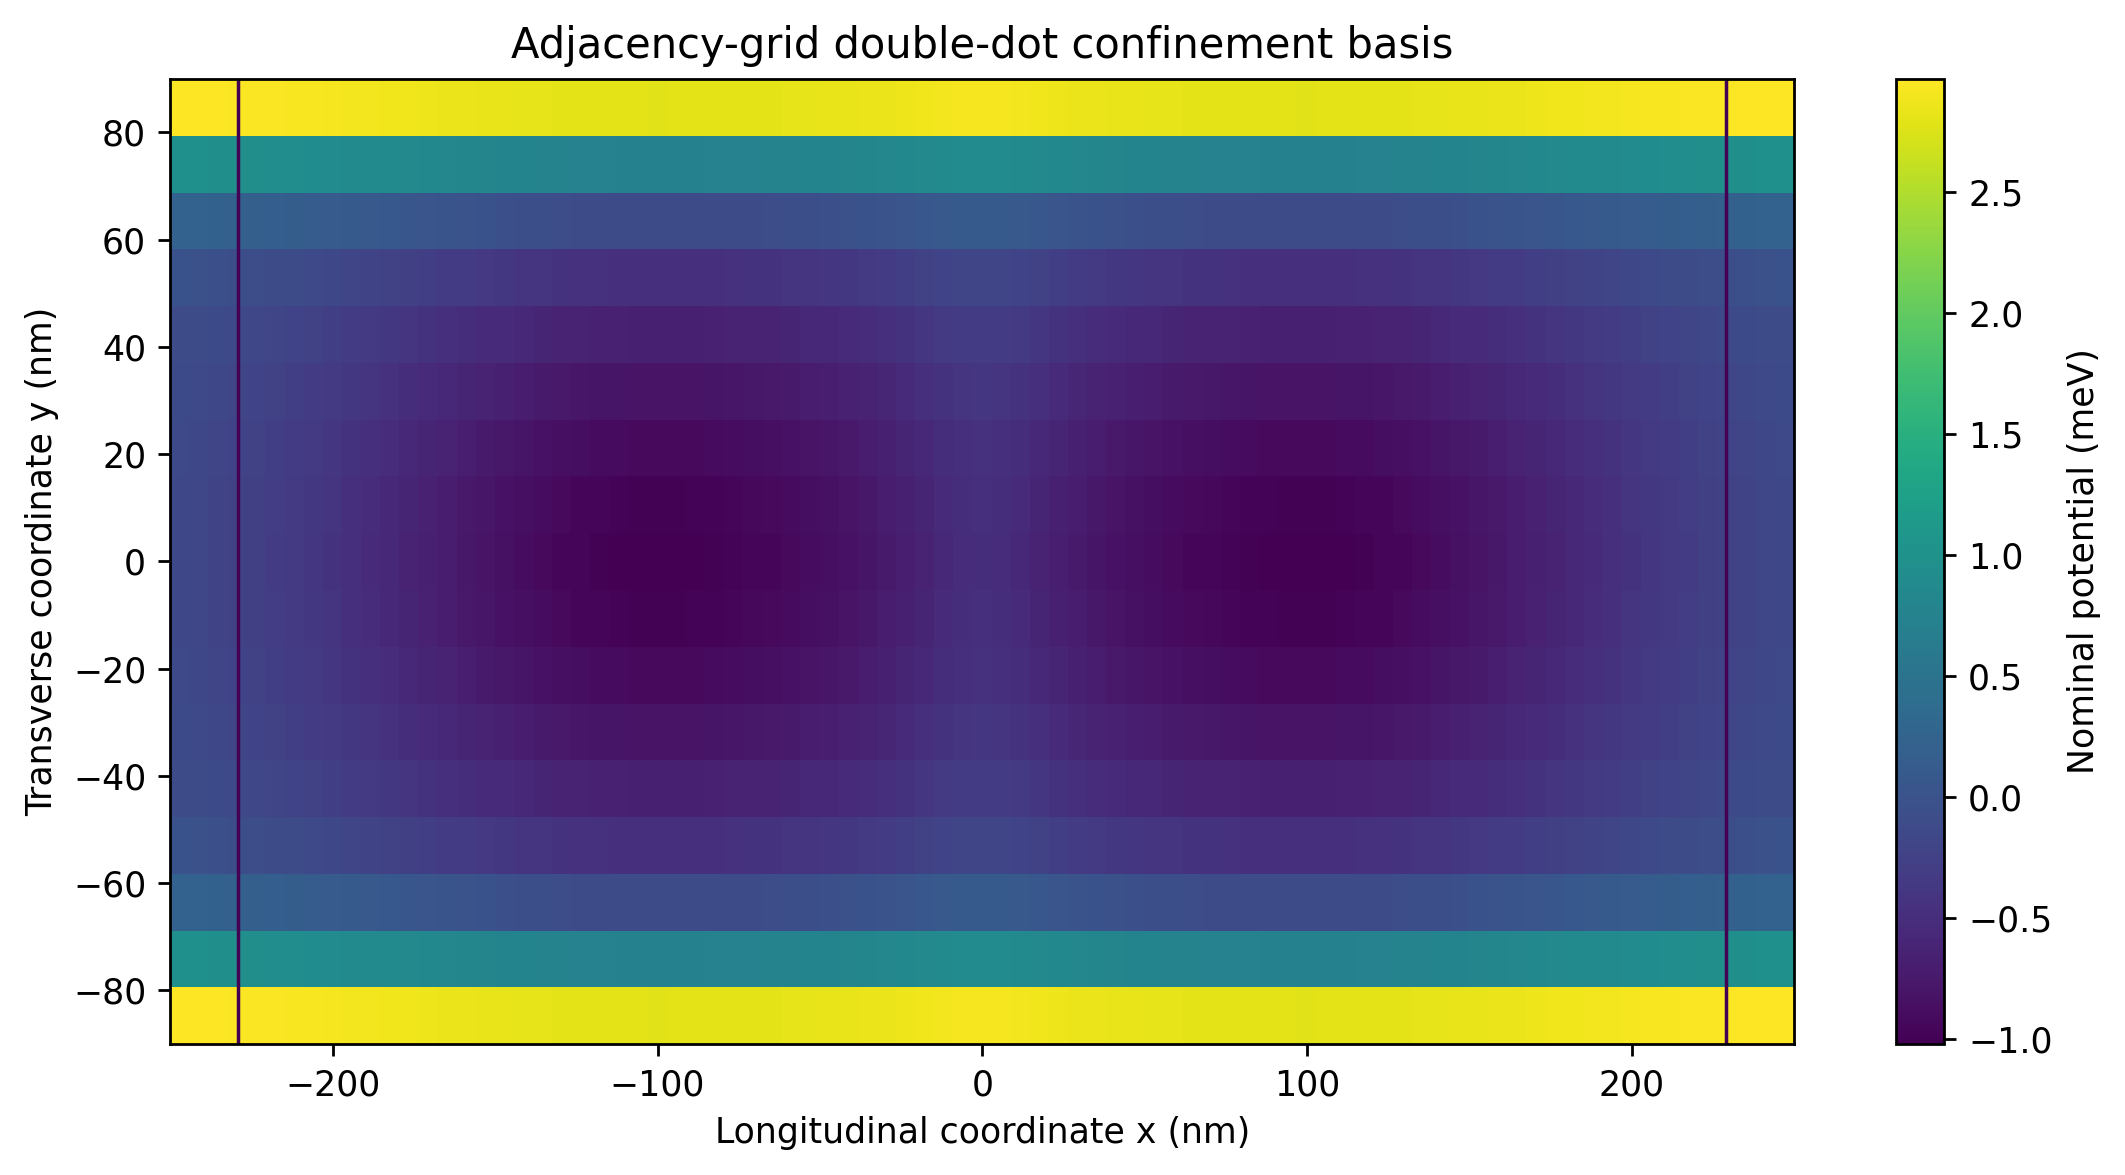

Basis audit: pilot_tolerance_unmet; mesh: feature_resolved_only

Candidate 1/3: Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au


In [ ]:
"""Screen oxide-free Ti/Au-contacted semimetal double-dot candidates.

This module implements a normal-state, single-electron envelope model for a
geometry-defined semimetal double quantum dot. It intentionally contains no
superconducting gap, Josephson energy, Andreev potential, or oxide tunnel
barrier. A real-space adjacency graph supplies finite-difference kinetic
operators, smooth graph-Laplacian disorder modes, contact participation, and a
reduced orbital basis. The initial Hamiltonian represents one selected
spin or Kramers sector and screens charge-orbital confinement. A spinful
extension requires downfolded spin-orbit and Zeeman matrices. CuPy performs
batched Hamiltonian construction and Hermitian diagonalization when a
compatible GPU is available.

The workflow has two statistical layers:

1. Forward Monte Carlo propagates uncertain material, interface, geometry, and
   electrostatic parameters into spectra and device-screening metrics.
2. Adaptive Metropolis-Hastings searches the same prior space for parameter
   regions that satisfy explicit qubit-like design criteria. This second layer
   is a design-conditioned ensemble, not an experimental Bayesian posterior.

The calculated ``alpha_eff`` is the spectral non-equidistance

    alpha_eff = f_12 - f_01,

of the first three confined one-electron eigenstates. For a double-dot charge
qubit, the guard band, transition dipole, charging energy, lead broadening, and
thermal initialization are at least as important as alpha_eff itself.

Automatic spatial feature resolution and pilot snapshot enrichment select a
fixed reduced model before sampling. Finite-pilot agreement is a local
numerical check; full continuum and prior-wide convergence require separate
checks. The normal-state Hamiltonian assumes normal reservoirs. Experiments
must establish that Ti/Au stays normal at the chosen operating temperature.
Coulomb charging is screened separately, without a many-electron interaction
calculation; the envelope sectors are proxies, without a computed topological
invariant. The plain-bridge linewidth floor is an explicit control prior.
"""

from __future__ import annotations

import json
import math
import time
import warnings
import zipfile
from collections.abc import Iterator
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import psutil
import scipy
import scipy.linalg
from threadpoolctl import threadpool_limits
import pandas as pd
from IPython.display import display
from scipy import sparse
from scipy.sparse import linalg as sparse_linalg
from scipy.stats import rankdata, spearmanr

try:
    import cupy as cp
    import cupyx
    from cupyx.scipy import sparse as cupy_sparse
    from cupyx.scipy.sparse import linalg as cupy_sparse_linalg

    CUPY_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    cp = None
    cupyx = None
    cupy_sparse = None
    cupy_sparse_linalg = None
    CUPY_AVAILABLE = False


# -----------------------------------------------------------------------------
# CONTROL KNOBS
# -----------------------------------------------------------------------------

USE_CUPY = True
# Numerical policy. Manual overrides keep the same physics and priors.
AUTO_ADAPT = True
SPARSE_POLICY = "auto"  # "auto", "on", or "off" for real-space operators.
PROJECTED_SOLVER = "auto"  # "auto", "dense", or exact "iterative" matvecs.
DEVICE_POLICY = "auto"  # "auto", "cpu", or "gpu"; USE_CUPY also applies.
ALLOW_CPU_FALLBACK = True

# Memory limits are conservative per-task estimates, including workspace.
GPU_MEMORY_FRACTION = 0.35
CPU_MEMORY_FRACTION = 0.25
GPU_RESERVE_GIB = 0.75
CPU_RESERVE_GIB = 0.25
MAX_GPU_WORKSPACE_GIB = 4.0
MAX_CPU_WORKSPACE_GIB = 2.0
DENSE_WORKSPACE_FACTOR = 12
MAX_BATCH_SIZE = 512
TARGET_BATCH_SECONDS = 0.20
CPU_BLAS_THREADS = 2

# Sparse CSR and Lanczos controls. Projected dense matrices retain all entries.
SPARSE_MIN_DIM = 512
SPARSE_MAX_DENSITY = 0.12
SPARSE_GPU_MIN_DIM = 4096
SPARSE_WORKSPACE_MIB = 512.0
SPARSE_MAX_NCV = 384
SPARSE_NCV_FACTOR = 3.0
SPARSE_MAX_ITERATIONS = 4000
SPARSE_RETRIES = 2
SPARSE_EIGEN_TOL = 1.0e-10
EIGEN_RESIDUAL_ATOL = 1.0e-8
EIGEN_ORTHOGONALITY_TOL = 1.0e-6
MAX_DENSE_REALSPACE_DIM = 3072
PROJECTED_ITERATIVE_MIN_DIM = 384
ITERATIVE_RETAINED_LEVELS = 16
THERMAL_TAIL_WEIGHT_TOL = 1.0e-3

# Geometry and basis adaptation finish before forward or Metropolis sampling.
AUTO_GRID = True
GRID_POINTS_PER_SIGMA = 3.0
GRID_OVERRIDE: tuple[int, int] | None = None
CONTACT_EXTENT_NM: float | None = None
MAX_GRAPH_NODES = 25_000
RUN_GRID_SPECTRAL_AUDIT = False
GRID_REFINEMENT_FACTOR = 1.4
GRID_MAX_REFINEMENTS = 1
AUTO_BASIS = True
BASIS_OVERRIDE: int | None = None
BASIS_MAX_ORBITALS = 96
BASIS_GROWTH_STEP = 12
PILOT_SAMPLES_PER_CANDIDATE = 3
PILOT_LATENT_SCALE = 0.75
PILOT_SNAPSHOT_ENRICHMENT = True
PILOT_REFERENCE_LEVELS = 6
BASIS_SPECTRAL_RTOL = 0.02
BASIS_SPECTRAL_ATOL_MHZ = 2.0
BASIS_DIPOLE_RTOL = 0.05
BASIS_DIPOLE_ATOL_NM = 0.05
BASIS_LINEWIDTH_RTOL = 0.05
BASIS_LINEWIDTH_ATOL_MHZ = 1.0
BASIS_FAILURE_POLICY = "warn"  # "warn" exports exploratory results; "raise" halts.

# Chain adaptation changes proposals during warmup only. Production can extend.
AUTO_MCMC_LENGTH = True
MCMC_MAX_STEPS = 2400
MCMC_CHECK_INTERVAL = 200
MCMC_RHAT_MAX = 1.01
MCMC_BULK_ESS_MIN = 400.0
MCMC_TAIL_ESS_MIN = 200.0
MCMC_INITIAL_DISPERSION = 1.0

# Rabi display sampling changes resolution, leaving time span and field fixed.
AUTO_RABI_RESOLUTION = True
RABI_SAMPLES_PER_CYCLE = 24
RABI_MAX_TIME_POINTS = 16_000
RABI_SIGNIFICANT_AMPLITUDE = 1.0e-4
MAX_AUDIT_EVENTS = 4000
SHOW_FIGURES = True
WRITE_FIGURES = True

FAST_TEST_MODE = False
RUN_FORWARD_MONTE_CARLO = True
RUN_METROPOLIS = True
RUN_REPRESENTATIVE_RABI = True
RUN_PLAIN_BRIDGE_CONTROL = True
DOWNLOAD_RESULTS_ZIP_IN_COLAB = False

RANDOM_SEED = 20260908
PLOT_DPI = 250
OUTPUT_DIRECTORY = Path("pt3sn_tiau_normal_state_screening_results")

# Real-space device grid and geometry.
GRID_NX = 41
GRID_NY = 17
DEVICE_LENGTH_NM = 500.0
DEVICE_WIDTH_NM = 180.0
DOT_SEPARATION_NM = 210.0
DOT_SIGMA_X_NM = 75.0
DOT_SIGMA_Y_NM = 50.0
CENTRAL_BARRIER_SIGMA_X_NM = 18.0
CENTRAL_BARRIER_SIGMA_Y_NM = 55.0
CONTACT_COLUMNS = 2
TRANSVERSE_CONFINEMENT_MEV = 3.0
BASIS_EFFECTIVE_MASS_M0 = 0.12
ORBITAL_BASIS_SIZE = 24
DISORDER_MODE_COUNT = 8

# Forward uncertainty propagation.
FORWARD_SAMPLES = 384 if FAST_TEST_MODE else 4096
FORWARD_BATCH_SIZE = 96 if FAST_TEST_MODE else 256

# Adaptive parallel Metropolis-Hastings design search.
MCMC_CHAINS = 8 if FAST_TEST_MODE else 32
MCMC_STEPS = 120 if FAST_TEST_MODE else 900
MCMC_BURN_IN = 40 if FAST_TEST_MODE else 300
MCMC_THIN = 4
MCMC_INITIAL_PROPOSAL_SCALE = 0.24
MCMC_TARGET_ACCEPTANCE = 0.25
MCMC_ADAPT_INTERVAL = 20
MCMC_ADAPT_GAIN = 0.75
MCMC_PROPOSAL_SCALE_MIN = 0.025
MCMC_PROPOSAL_SCALE_MAX = 1.25
MCMC_DESIGN_WEIGHT = 1.0

# Spectral and device success criteria. These are screening thresholds.
OPERATING_TEMPERATURE_MK = 20.0
TARGET_F01_GHZ_MIN = 1.0
TARGET_F01_GHZ_MAX = 12.0
TARGET_F01_GHZ_CENTER = 5.0
TARGET_F01_GHZ_SIGMA = 3.0
MIN_ABS_ALPHA_MHZ = 75.0
MIN_DIPOLE_X01_NM = 0.35
MAX_CONTACT_LINEWIDTH_MHZ = 60.0
MIN_ALPHA_TO_LINEWIDTH = 5.0
MIN_CHARGING_TO_THERMAL = 10.0
MIN_GROUND_STATE_POPULATION = 0.95
MAX_RABI_TO_ALPHA = 0.10
AC_ELECTRIC_FIELD_V_PER_M = 2.0e3
EFFECTIVE_GATE_DRIVE_LEVER_ARM = 0.01
PLAIN_BRIDGE_CONTACT_GAMMA_FLOOR_UEV = 5.0e3
LEVELS_TO_REPORT = 6

# Representative multilevel rotating-wave calculation.
RABI_LEVEL_COUNT = 5
RABI_TIME_US = 1.5
RABI_TIME_POINTS = 900
RABI_DETUNING_MHZ = 500.0
RABI_DETUNING_POINTS = 121
RABI_ADJACENT_TRANSITIONS_ONLY = True

# Optional downfolded parameter overrides. A CSV can contain the columns
# candidate, parameter, median_or_mean, spread, lower, upper, distribution.
# Supported distributions are "lognormal" and "normal".
PARAMETER_OVERRIDE_CSV: str | None = None


# -----------------------------------------------------------------------------
# PHYSICAL CONSTANTS AND PLOTTING
# -----------------------------------------------------------------------------

E_CHARGE = 1.602_176_634e-19
PLANCK = 6.626_070_15e-34
HBAR = PLANCK / (2.0 * math.pi)
KB = 1.380_649e-23
ELECTRON_MASS = 9.109_383_7015e-31
MEV_TO_J = 1.0e-3 * E_CHARGE
MEV_TO_HZ = MEV_TO_J / PLANCK
MEV_TO_GHZ = MEV_TO_HZ / 1.0e9
MEV_TO_MHZ = MEV_TO_HZ / 1.0e6
KB_MEV_PER_K = KB / MEV_TO_J
HBAR2_OVER_2ME_MEV_NM2 = (
    HBAR**2 / (2.0 * ELECTRON_MASS) / MEV_TO_J / 1.0e-18
)

mpl.rcParams["figure.dpi"] = PLOT_DPI
mpl.rcParams["savefig.dpi"] = PLOT_DPI
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
mpl.rcParams["axes.grid"] = False


# -----------------------------------------------------------------------------
# PRIOR AND CANDIDATE DEFINITIONS
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class LogNormalPrior:
    """Describe a clipped lognormal screening prior."""

    median: float
    log_sigma: float
    lower: float
    upper: float


@dataclass(frozen=True)
class NormalPrior:
    """Describe a clipped normal screening prior."""

    mean: float
    standard_deviation: float
    lower: float
    upper: float


@dataclass(frozen=True)
class MaterialPrior:
    """Collect effective low-energy priors for one material family."""

    label: str
    surface_mass_m0: LogNormalPrior
    bulk_mass_m0: LogNormalPrior
    bulk_offset_mev: NormalPrior
    intersector_coupling_mev: LogNormalPrior
    linear_coupling_mev_nm: LogNormalPrior
    tilt_mev_nm: NormalPrior
    disorder_rms_mev: LogNormalPrior
    contact_gamma_uev: LogNormalPrior
    capacitance_af: LogNormalPrior
    well_depth_mev: LogNormalPrior
    barrier_height_mev: LogNormalPrior
    detuning_mev: NormalPrior
    interface_asymmetry_mev: NormalPrior
    bulk_contact_multiplier: float
    resistivity_uohm_cm: float | None
    sheet_resistance_ohm_sq: float | None
    provenance: str


@dataclass(frozen=True)
class Candidate:
    """Describe one material and confinement topology combination."""

    key: str
    label: str
    material_key: str
    topology: str


# The numerical values below are intentionally broad proposal-level priors.
# They are not asserted as measured Pt3Sn quantum-dot parameters. Replace them
# with periodic DFT/Wannier, low-temperature transport, and dot spectroscopy.
MATERIAL_PRIORS: dict[str, MaterialPrior] = {
    "pt3sn": MaterialPrior(
        label="Pt3Sn",
        surface_mass_m0=LogNormalPrior(0.18, 0.65, 0.025, 1.50),
        bulk_mass_m0=LogNormalPrior(0.45, 0.65, 0.05, 3.00),
        bulk_offset_mev=NormalPrior(2.5, 3.0, -4.0, 15.0),
        intersector_coupling_mev=LogNormalPrior(0.35, 0.80, 0.005, 5.0),
        linear_coupling_mev_nm=LogNormalPrior(65.0, 0.75, 1.0, 600.0),
        tilt_mev_nm=NormalPrior(18.0, 25.0, -120.0, 120.0),
        disorder_rms_mev=LogNormalPrior(0.35, 0.75, 0.01, 5.0),
        contact_gamma_uev=LogNormalPrior(40.0, 0.95, 0.1, 3000.0),
        capacitance_af=LogNormalPrior(28.0, 0.45, 3.0, 250.0),
        well_depth_mev=LogNormalPrior(1.10, 0.50, 0.08, 8.0),
        barrier_height_mev=LogNormalPrior(0.28, 0.70, 0.005, 5.0),
        detuning_mev=NormalPrior(0.0, 0.08, -0.8, 0.8),
        interface_asymmetry_mev=NormalPrior(0.0, 0.10, -1.0, 1.0),
        bulk_contact_multiplier=1.7,
        resistivity_uohm_cm=83.0,
        sheet_resistance_ohm_sq=None,
        provenance=(
            "Broad Pt3Sn normal-state screening prior; resistivity anchor only "
            "is tied to published thin-film transport."
        ),
    ),
    "graphene": MaterialPrior(
        label="graphene-like control",
        surface_mass_m0=LogNormalPrior(0.033, 0.28, 0.012, 0.12),
        bulk_mass_m0=LogNormalPrior(0.055, 0.35, 0.015, 0.25),
        bulk_offset_mev=NormalPrior(8.0, 3.0, 0.5, 25.0),
        intersector_coupling_mev=LogNormalPrior(0.08, 0.80, 0.001, 2.0),
        linear_coupling_mev_nm=LogNormalPrior(8.0, 0.95, 0.05, 200.0),
        tilt_mev_nm=NormalPrior(0.0, 3.0, -20.0, 20.0),
        disorder_rms_mev=LogNormalPrior(0.12, 0.70, 0.003, 2.0),
        contact_gamma_uev=LogNormalPrior(12.0, 0.90, 0.05, 1000.0),
        capacitance_af=LogNormalPrior(22.0, 0.40, 3.0, 200.0),
        well_depth_mev=LogNormalPrior(1.00, 0.45, 0.08, 8.0),
        barrier_height_mev=LogNormalPrior(0.24, 0.65, 0.005, 4.0),
        detuning_mev=NormalPrior(0.0, 0.06, -0.8, 0.8),
        interface_asymmetry_mev=NormalPrior(0.0, 0.06, -0.8, 0.8),
        bulk_contact_multiplier=1.0,
        resistivity_uohm_cm=None,
        sheet_resistance_ohm_sq=300.0,
        provenance=(
            "Graphene-like double-dot control used to test whether the model "
            "recovers a confined charge-qubit regime."
        ),
    ),
}

CANDIDATES = [
    Candidate(
        key="pt3sn_dqd",
        label="Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au",
        material_key="pt3sn",
        topology="double_dot",
    ),
    Candidate(
        key="graphene_dqd",
        label="Ti/Au–graphene-like DQD–Ti/Au control",
        material_key="graphene",
        topology="double_dot",
    ),
]

if RUN_PLAIN_BRIDGE_CONTROL:
    CANDIDATES.append(
        Candidate(
            key="pt3sn_plain_bridge",
            label="Ti/Au–Pt3Sn plain nanobridge–Ti/Au control",
            material_key="pt3sn",
            topology="plain_bridge",
        )
    )

BASE_LATENT_NAMES = (
    "surface_mass_m0",
    "bulk_mass_m0",
    "bulk_offset_mev",
    "intersector_coupling_mev",
    "linear_coupling_mev_nm",
    "tilt_mev_nm",
    "disorder_rms_mev",
    "contact_gamma_uev",
    "capacitance_af",
    "well_depth_mev",
    "barrier_height_mev",
    "detuning_mev",
    "interface_asymmetry_mev",
)


# -----------------------------------------------------------------------------
# GRAPH BASIS
# -----------------------------------------------------------------------------


@dataclass
class GraphBasis:
    """Store the reduced adjacency-derived operators and plotting fields."""

    x_nm: np.ndarray
    y_nm: np.ndarray
    potential_nominal_mev: np.ndarray
    contact_mask: np.ndarray
    basis_vectors: np.ndarray
    identity: np.ndarray
    k2: np.ndarray
    kx: np.ndarray
    ky: np.ndarray
    well: np.ndarray
    barrier: np.ndarray
    detuning: np.ndarray
    interface: np.ndarray
    transverse: np.ndarray
    x_operator: np.ndarray
    contact: np.ndarray
    left_right: np.ndarray
    disorder_modes: np.ndarray
    full_disorder_fields: np.ndarray
    spatial: dict[str, Any]


@dataclass
class BackendBasis:
    """Store one GraphBasis copied to NumPy or CuPy arrays."""

    xp: Any
    identity: Any
    k2: Any
    kx: Any
    ky: Any
    well: Any
    barrier: Any
    detuning: Any
    interface: Any
    transverse: Any
    x_operator: Any
    contact: Any
    left_right: Any
    disorder_modes: Any


@dataclass
class McmcResult:
    """Hold one design-conditioned Metropolis-Hastings result."""

    dataframe: pd.DataFrame
    acceptance: float
    burn_in_acceptance: float
    final_proposal_scale: float
    retained_iterations: int
    diagnostics: dict[str, dict[str, float]]
    backend: str
    steps_run: int
    converged: bool
    stop_reason: str


def _one_dimensional_operators(
    point_count: int,
    spacing_nm: float,
) -> tuple[sparse.csr_matrix, sparse.csr_matrix]:
    """Return positive -d2/dx2 and Hermitian -i d/dx operators."""
    main = np.full(point_count, 2.0 / spacing_nm**2)
    off = np.full(point_count - 1, -1.0 / spacing_nm**2)
    k2 = sparse.diags((off, main, off), (-1, 0, 1), format="csr")

    derivative = sparse.diags(
        (
            np.full(point_count - 1, -1.0 / (2.0 * spacing_nm)),
            np.full(point_count - 1, 1.0 / (2.0 * spacing_nm)),
        ),
        (-1, 1),
        format="csr",
    )
    momentum = (-1.0j * derivative).tocsr()
    return k2, momentum


def _grid_graph_laplacian(nx: int, ny: int) -> sparse.csr_matrix:
    """Return the unweighted rectangular-grid graph Laplacian."""
    node_count = nx * ny
    rows: list[int] = []
    columns: list[int] = []
    values: list[float] = []

    def node(x_index: int, y_index: int) -> int:
        return y_index * nx + x_index

    for y_index in range(ny):
        for x_index in range(nx):
            current = node(x_index, y_index)
            degree = 0
            for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                neighbor_x = x_index + dx
                neighbor_y = y_index + dy
                if 0 <= neighbor_x < nx and 0 <= neighbor_y < ny:
                    rows.append(current)
                    columns.append(node(neighbor_x, neighbor_y))
                    values.append(-1.0)
                    degree += 1
            rows.append(current)
            columns.append(current)
            values.append(float(degree))

    return sparse.coo_matrix(
        (values, (rows, columns)),
        shape=(node_count, node_count),
    ).tocsr()


def _project_diagonal(
    basis_vectors: np.ndarray,
    diagonal_values: np.ndarray,
) -> np.ndarray:
    """Project a real-space diagonal operator into the reduced basis."""
    return basis_vectors.conj().T @ (
        diagonal_values[:, None] * basis_vectors
    )


def _project_sparse(
    basis_vectors: np.ndarray,
    operator: sparse.spmatrix,
) -> np.ndarray:
    """Project a sparse real-space operator into the reduced basis."""
    return basis_vectors.conj().T @ (operator @ basis_vectors)


def build_graph_basis() -> GraphBasis:
    """Resolve geometry and select a pilot-audited basis before production."""
    validate_controls()
    runtime = get_runtime()
    nx, ny = choose_grid()
    spatial = build_spatial_problem(nx, ny)
    references = collect_pilot_references(spatial)
    # Mesh checks use nominal points, avoiding random-field basis rotations
    # between grids. A finite check cannot establish continuum convergence.
    if AUTO_ADAPT and RUN_GRID_SPECTRAL_AUDIT and GRID_OVERRIDE is None:
        for refinement in range(GRID_MAX_REFINEMENTS):
            fine_nx = math.ceil((nx - 1) * GRID_REFINEMENT_FACTOR) + 1
            fine_ny = math.ceil((ny - 1) * GRID_REFINEMENT_FACTOR) + 1
            if fine_nx * fine_ny > MAX_GRAPH_NODES:
                runtime.grid_status = "grid_cap_reached"
                break
            finer = build_spatial_problem(fine_nx, fine_ny)
            matches = []
            for reference in references[::PILOT_SAMPLES_PER_CANDIDATE]:
                matrix = full_spatial_hamiltonian(
                    reference["latent"], reference["candidate"], finer
                )
                candidate_key = reference["candidate"].key
                values, _ = solve_low_spectrum(
                    matrix, 3, f"mesh_{candidate_key}_{refinement}"
                )
                fine_metrics = np.array([
                    values[1] - values[0], values[2] - 2 * values[1] + values[0]
                ]) * MEV_TO_MHZ
                coarse_metrics = (
                    np.array([reference["f01_ghz"] * 1.0e3, reference["alpha_mhz"]])
                )
                errors = np.abs(fine_metrics - coarse_metrics)
                limits = (
                    BASIS_SPECTRAL_ATOL_MHZ + BASIS_SPECTRAL_RTOL * np.abs(fine_metrics)
                )
                passed = bool(np.all(errors <= limits))
                matches.append(passed)
                runtime.grid_audit.append({
                    "candidate": reference["candidate"].key, "refinement": refinement,
                    "coarse_nx": nx, "coarse_ny": ny, "fine_nx": fine_nx,
                        "fine_ny": fine_ny,
                    "f01_error_mhz": errors[0], "alpha_error_mhz": errors[1],
                        "passed": passed,
                })
            if all(matches):
                runtime.grid_status = "nominal_spectral_audit_passed"
                break
            nx, ny, spatial = fine_nx, fine_ny, finer
            references = collect_pilot_references(spatial)
            runtime.grid_status = "refined_grid_requires_further_check"
    n = nx * ny
    minimum = BASIS_OVERRIDE if BASIS_OVERRIDE is not None else ORBITAL_BASIS_SIZE
    if minimum < 3 or minimum >= n - 1:
        raise ValueError("The orbital basis must fit inside the spatial dimension.")
    automatic = AUTO_ADAPT and AUTO_BASIS and BASIS_OVERRIDE is None
    maximum = min(BASIS_MAX_ORBITALS if automatic else minimum, n - 2)
    if maximum < minimum:
        raise ValueError("BASIS_MAX_ORBITALS must exceed ORBITAL_BASIS_SIZE.")
    scalar = (
        HBAR2_OVER_2ME_MEV_NM2 / BASIS_EFFECTIVE_MASS_M0 * spatial["k2"]
            + sparse.diags(spatial["nominal"])
    )
    _, scalar_vectors = solve_low_spectrum(scalar, maximum, "scalar_orbital_basis")
    # Enrich the scalar orbitals with the spatial parts of full, two-sector
    # pilot eigenvectors. This captures bulk/surface mixing absent from a
    # single effective-mass basis without changing the Hamiltonian itself.
    if automatic and PILOT_SNAPSHOT_ENRICHMENT:
        anchor = scalar_vectors[:, :minimum]
        snapshots = np.concatenate([
            component
            for reference in references
            for component in (reference["vectors"][:n], reference["vectors"][n:])
        ], axis=1)
        snapshots -= anchor @ (anchor.conj().T @ snapshots)
        left, singular, _ = (
            scipy.linalg.svd(snapshots, full_matrices=False, check_finite=False)
        )
        rank = min(int(np.count_nonzero(singular > 1.0e-10)), maximum - minimum)
        enrichment = left[:, :rank]
        trial = (
            np.concatenate((anchor, enrichment, scalar_vectors[:, minimum:]), axis=1)
        )
        vectors, triangular = (
            scipy.linalg.qr(trial, mode="economic", check_finite=False)
        )
        # The leading anchor+snapshot block has independent columns. The
        # scalar tail may be rank deficient, so discard dependent tail columns.
        independent = np.abs(np.diag(triangular)) > 1.0e-10
        vectors = vectors[:, independent][:, :maximum]
    else:
        vectors = scalar_vectors[:, :maximum]
    master = project_spatial_basis(spatial, vectors)
    maximum = master.identity.shape[0]
    counts = (
        sorted(set(list(range(minimum, maximum + 1, BASIS_GROWTH_STEP)) + [maximum]))
    )
    chosen = master
    passed = False
    for count in counts:
        chosen = trim_graph_basis(master, count)
        basis = create_backend_basis(chosen, np)
        passed_rows = []
        for index, reference in enumerate(references):
            metrics = calculate_metrics_batch(
                reference["latent"][None, :], reference["candidate"], basis
            )
            current = (
                np.array([metrics["f01_ghz"][0] * 1.0e3, metrics["alpha_eff_mhz"][0]])
            )
            target = np.array([reference["f01_ghz"] * 1.0e3, reference["alpha_mhz"]])
            errors = np.abs(current - target)
            limits = BASIS_SPECTRAL_ATOL_MHZ + BASIS_SPECTRAL_RTOL * np.abs(target)
            dipole_error = abs(float(metrics["x01_nm"][0]) - reference["x01_nm"])
            linewidth_error = (
                abs(float(metrics["contact_linewidth_mhz"][0]) - reference[
                    "linewidth_mhz"])
            )
            row_pass = bool(
                np.all(errors <= limits)
                and dipole_error <= BASIS_DIPOLE_ATOL_NM + BASIS_DIPOLE_RTOL
                    * reference["x01_nm"]
                and linewidth_error <= BASIS_LINEWIDTH_ATOL_MHZ
                    + BASIS_LINEWIDTH_RTOL * reference["linewidth_mhz"]
            )
            passed_rows.append(row_pass)
            runtime.basis_audit.append({
                "candidate": reference["candidate"].key, "pilot": index,
                "orbitals": count, "f01_error_mhz": errors[0],
                    "alpha_error_mhz": errors[1],
                "dipole_error_nm": dipole_error, "linewidth_error_mhz": linewidth_error,
                "passed": row_pass,
            })
        passed = all(passed_rows)
        runtime.record("basis_trial", orbitals=count, pilot_points=len(references),
            passed=passed)
        if passed or automatic is False:
            break
    runtime.basis_status = "pilot_passed" if passed else "pilot_tolerance_unmet"
    if passed is False:
        message = (
            f"Basis cap {chosen.identity.shape[0]} reached "
            "with unmet pilot tolerances. "
            "Results are exploratory; inspect basis_convergence.csv."
        )
        if BASIS_FAILURE_POLICY == "raise":
            raise SpectrumAccuracyError(message)
        warnings.warn(message, RuntimeWarning, stacklevel=2)
    runtime.production_frozen = True
    runtime.record("freeze_production_model", orbitals=chosen.identity.shape[0],
                   grid=[nx, ny], basis_status=runtime.basis_status,
                   grid_status=runtime.grid_status)
    return chosen


def create_backend_basis(graph_basis: GraphBasis, xp: Any) -> BackendBasis:
    """Copy reduced operators to the active numerical backend."""

    def copy(array: np.ndarray) -> Any:
        return np.asarray(array) if xp is np else cp.asarray(array)

    return BackendBasis(
        xp=xp,
        identity=copy(graph_basis.identity),
        k2=copy(graph_basis.k2),
        kx=copy(graph_basis.kx),
        ky=copy(graph_basis.ky),
        well=copy(graph_basis.well),
        barrier=copy(graph_basis.barrier),
        detuning=copy(graph_basis.detuning),
        interface=copy(graph_basis.interface),
        transverse=copy(graph_basis.transverse),
        x_operator=copy(graph_basis.x_operator),
        contact=copy(graph_basis.contact),
        left_right=copy(graph_basis.left_right),
        disorder_modes=copy(graph_basis.disorder_modes),
    )


# -----------------------------------------------------------------------------
# PARAMETER TRANSFORMS
# -----------------------------------------------------------------------------


def latent_dimension() -> int:
    """Return the total standard-normal latent dimension."""
    return len(BASE_LATENT_NAMES) + DISORDER_MODE_COUNT


def _lognormal_transform(latent: Any, prior: LogNormalPrior, xp: Any) -> Any:
    """Map standard-normal coordinates to a clipped lognormal variable."""
    value = prior.median * xp.exp(prior.log_sigma * latent)
    return xp.clip(value, prior.lower, prior.upper)


def _normal_transform(latent: Any, prior: NormalPrior, xp: Any) -> Any:
    """Map standard-normal coordinates to a clipped normal variable."""
    value = prior.mean + prior.standard_deviation * latent
    return xp.clip(value, prior.lower, prior.upper)


def transform_latent_parameters(
    latent: Any,
    candidate: Candidate,
    xp: Any,
) -> dict[str, Any]:
    """Map latent coordinates to material and device parameters."""
    prior = MATERIAL_PRIORS[candidate.material_key]
    cursor = 0

    surface_mass = _lognormal_transform(
        latent[:, cursor], prior.surface_mass_m0, xp
    )
    cursor += 1
    bulk_mass = _lognormal_transform(
        latent[:, cursor], prior.bulk_mass_m0, xp
    )
    cursor += 1
    bulk_offset = _normal_transform(
        latent[:, cursor], prior.bulk_offset_mev, xp
    )
    cursor += 1
    intersector = _lognormal_transform(
        latent[:, cursor], prior.intersector_coupling_mev, xp
    )
    cursor += 1
    linear_coupling = _lognormal_transform(
        latent[:, cursor], prior.linear_coupling_mev_nm, xp
    )
    cursor += 1
    tilt = _normal_transform(latent[:, cursor], prior.tilt_mev_nm, xp)
    cursor += 1
    disorder_rms = _lognormal_transform(
        latent[:, cursor], prior.disorder_rms_mev, xp
    )
    cursor += 1
    contact_gamma = _lognormal_transform(
        latent[:, cursor], prior.contact_gamma_uev, xp
    )
    cursor += 1
    capacitance = _lognormal_transform(
        latent[:, cursor], prior.capacitance_af, xp
    )
    cursor += 1
    well_depth = _lognormal_transform(
        latent[:, cursor], prior.well_depth_mev, xp
    )
    cursor += 1
    barrier_height = _lognormal_transform(
        latent[:, cursor], prior.barrier_height_mev, xp
    )
    cursor += 1
    detuning = _normal_transform(
        latent[:, cursor], prior.detuning_mev, xp
    )
    cursor += 1
    interface_asymmetry = _normal_transform(
        latent[:, cursor], prior.interface_asymmetry_mev, xp
    )
    cursor += 1

    if candidate.topology == "plain_bridge":
        well_depth = 0.02 * well_depth
        barrier_height = 0.02 * barrier_height
        detuning = 0.0 * detuning
        contact_gamma = xp.clip(
            12.0 * contact_gamma,
            PLAIN_BRIDGE_CONTACT_GAMMA_FLOOR_UEV,
            20_000.0,
        )
    elif candidate.topology != "double_dot":
        raise ValueError(f"Unknown topology: {candidate.topology}")

    disorder_latent = latent[:, cursor:cursor + DISORDER_MODE_COUNT]
    disorder_coefficients = (
        disorder_rms[:, None]
        * disorder_latent
        / math.sqrt(DISORDER_MODE_COUNT)
    )

    return {
        "surface_mass_m0": surface_mass,
        "bulk_mass_m0": bulk_mass,
        "bulk_offset_mev": bulk_offset,
        "intersector_coupling_mev": intersector,
        "linear_coupling_mev_nm": linear_coupling,
        "tilt_mev_nm": tilt,
        "disorder_rms_mev": disorder_rms,
        "contact_gamma_uev": contact_gamma,
        "capacitance_af": capacitance,
        "well_depth_mev": well_depth,
        "barrier_height_mev": barrier_height,
        "detuning_mev": detuning,
        "interface_asymmetry_mev": interface_asymmetry,
        "disorder_coefficients": disorder_coefficients,
    }


def apply_parameter_overrides() -> None:
    """Apply optional external prior overrides from a compact CSV file."""
    if PARAMETER_OVERRIDE_CSV is None:
        return

    override_path = Path(PARAMETER_OVERRIDE_CSV)
    if override_path.exists() is False:
        raise FileNotFoundError(
            f"Parameter override file does not exist: {override_path}"
        )

    table = pd.read_csv(override_path)
    required = {
        "candidate",
        "parameter",
        "median_or_mean",
        "spread",
        "lower",
        "upper",
        "distribution",
    }
    missing = required.difference(table.columns)
    if missing:
        raise ValueError(
            "Parameter override CSV is missing columns: "
            + ", ".join(sorted(missing))
        )

    for _, row in table.iterrows():
        material_key = str(row["candidate"])
        parameter = str(row["parameter"])
        if material_key not in MATERIAL_PRIORS:
            raise KeyError(f"Unknown material override key: {material_key}")
        prior = MATERIAL_PRIORS[material_key]
        distribution = str(row["distribution"]).strip().lower()
        if distribution == "lognormal":
            replacement = LogNormalPrior(
                median=float(row["median_or_mean"]),
                log_sigma=float(row["spread"]),
                lower=float(row["lower"]),
                upper=float(row["upper"]),
            )
        elif distribution == "normal":
            replacement = NormalPrior(
                mean=float(row["median_or_mean"]),
                standard_deviation=float(row["spread"]),
                lower=float(row["lower"]),
                upper=float(row["upper"]),
            )
        else:
            raise ValueError(
                f"Unsupported override distribution: {distribution}"
            )
        if hasattr(prior, parameter) is False:
            raise KeyError(
                f"Unknown parameter {parameter!r} for {material_key!r}."
            )
        if type(replacement) is not type(getattr(prior, parameter)):
            raise ValueError("Override distribution differs from its parameter type.")
        if replacement.lower >= replacement.upper:
            raise ValueError("Override lower bound must be below its upper bound.")
        MATERIAL_PRIORS[material_key] = replace(
            prior, **{parameter: replacement}
        )


# -----------------------------------------------------------------------------
# BATCHED HAMILTONIAN AND METRICS
# -----------------------------------------------------------------------------


def _batch_outer_scale(values: Any, matrix: Any) -> Any:
    """Return values[:, None, None] times one reduced matrix."""
    return values[:, None, None] * matrix[None, :, :]


def build_hamiltonian_batch(
    parameters: dict[str, Any],
    candidate: Candidate,
    basis: BackendBasis,
) -> Any:
    """Build the two-sector normal-state Hamiltonian in meV."""
    xp = basis.xp
    sample_count = int(parameters["surface_mass_m0"].shape[0])
    fixed_potential = (
        TRANSVERSE_CONFINEMENT_MEV * basis.transverse
    )
    potential = xp.broadcast_to(
        fixed_potential[None, :, :],
        (sample_count,) + fixed_potential.shape,
    ).copy()
    potential -= _batch_outer_scale(
        parameters["well_depth_mev"], basis.well
    )
    potential += _batch_outer_scale(
        parameters["barrier_height_mev"], basis.barrier
    )
    potential += _batch_outer_scale(
        parameters["detuning_mev"], basis.detuning
    )
    potential += _batch_outer_scale(
        parameters["interface_asymmetry_mev"], basis.interface
    )
    potential += xp.einsum(
        "bm,mij->bij",
        parameters["disorder_coefficients"],
        basis.disorder_modes,
        optimize=True,
    )

    surface_curvature = (
        HBAR2_OVER_2ME_MEV_NM2 / parameters["surface_mass_m0"]
    )
    bulk_curvature = (
        HBAR2_OVER_2ME_MEV_NM2 / parameters["bulk_mass_m0"]
    )

    surface_block = potential + _batch_outer_scale(
        surface_curvature, basis.k2
    )
    surface_block += _batch_outer_scale(
        parameters["tilt_mev_nm"], basis.kx
    )

    bulk_block = potential + _batch_outer_scale(
        bulk_curvature, basis.k2
    )
    bulk_block += _batch_outer_scale(
        parameters["bulk_offset_mev"], basis.identity
    )
    bulk_block -= _batch_outer_scale(
        0.35 * parameters["tilt_mev_nm"], basis.kx
    )

    complex_momentum = basis.kx - 1.0j * basis.ky
    coupling_block = _batch_outer_scale(
        parameters["intersector_coupling_mev"], basis.identity
    )
    coupling_block += _batch_outer_scale(
        parameters["linear_coupling_mev_nm"], complex_momentum
    )

    upper = xp.concatenate((surface_block, coupling_block), axis=2)
    lower = xp.concatenate(
        (
            xp.swapaxes(xp.conj(coupling_block), 1, 2),
            bulk_block,
        ),
        axis=2,
    )
    hamiltonian = xp.concatenate((upper, lower), axis=1)
    return 0.5 * (
        hamiltonian + xp.swapaxes(xp.conj(hamiltonian), 1, 2)
    )


def _full_block_operator(
    operator: Any,
    second_block_multiplier: float,
    xp: Any,
) -> Any:
    """Return a two-sector block-diagonal operator."""
    zero = xp.zeros_like(operator)
    upper = xp.concatenate((operator, zero), axis=1)
    lower = xp.concatenate(
        (zero, second_block_multiplier * operator), axis=1
    )
    return xp.concatenate((upper, lower), axis=0)


def _expectation_batch(vectors: Any, operator: Any, xp: Any) -> Any:
    """Return batched real expectation values for state vectors."""
    return xp.real(
        xp.einsum(
            "bi,ij,bj->b",
            xp.conj(vectors),
            operator,
            vectors,
            optimize=True,
        )
    )


def _matrix_element_batch(
    vectors_a: Any,
    operator: Any,
    vectors_b: Any,
    xp: Any,
) -> Any:
    """Return batched absolute transition matrix elements."""
    return xp.abs(
        xp.einsum(
            "bi,ij,bj->b",
            xp.conj(vectors_a),
            operator,
            vectors_b,
            optimize=True,
        )
    )


def calculate_metrics_batch(
    latent: Any,
    candidate: Candidate,
    basis: BackendBasis,
    return_eigensystem: bool = False,
) -> dict[str, Any]:
    """Calculate spectra, linewidths, dipoles, and screening metrics."""
    xp = basis.xp
    parameters = transform_latent_parameters(latent, candidate, xp)
    eigenvalues, eigenvectors, hamiltonian = solve_projected_batch(
        parameters, candidate, basis
    )
    level_count = min(LEVELS_TO_REPORT, int(eigenvalues.shape[1]))
    levels = eigenvalues[:, :level_count]
    levels = levels - levels[:, :1]

    f01_ghz = (levels[:, 1] - levels[:, 0]) * MEV_TO_GHZ
    f12_ghz = (levels[:, 2] - levels[:, 1]) * MEV_TO_GHZ
    alpha_mhz = (f12_ghz - f01_ghz) * 1.0e3
    abs_alpha_mhz = xp.abs(alpha_mhz)

    x_full = _full_block_operator(basis.x_operator, 1.0, xp)
    contact_full = _full_block_operator(
        basis.contact,
        MATERIAL_PRIORS[candidate.material_key].bulk_contact_multiplier,
        xp,
    )
    left_right_full = _full_block_operator(basis.left_right, 1.0, xp)
    orbital_count = int(basis.identity.shape[0])
    surface_projector = xp.zeros(
        (2 * orbital_count, 2 * orbital_count),
        dtype=xp.complex128,
    )
    surface_projector[:orbital_count, :orbital_count] = xp.eye(
        orbital_count, dtype=xp.complex128
    )

    state_0 = eigenvectors[:, :, 0]
    state_1 = eigenvectors[:, :, 1]
    state_2 = eigenvectors[:, :, 2]

    x01_nm = _matrix_element_batch(state_0, x_full, state_1, xp)
    x12_nm = _matrix_element_batch(state_1, x_full, state_2, xp)
    x02_nm = _matrix_element_batch(state_0, x_full, state_2, xp)

    contact_0 = _expectation_batch(state_0, contact_full, xp)
    contact_1 = _expectation_batch(state_1, contact_full, xp)
    contact_2 = _expectation_batch(state_2, contact_full, xp)
    contact_gamma_mev = parameters["contact_gamma_uev"] * 1.0e-3
    gamma_0_mev = contact_gamma_mev * contact_0
    gamma_1_mev = contact_gamma_mev * contact_1
    gamma_2_mev = contact_gamma_mev * contact_2
    transition_linewidth_mhz = (
        0.5 * (gamma_0_mev + gamma_1_mev) * MEV_TO_MHZ
    )

    surface_0 = _expectation_batch(state_0, surface_projector, xp)
    surface_1 = _expectation_batch(state_1, surface_projector, xp)
    surface_2 = _expectation_batch(state_2, surface_projector, xp)
    polarization_0 = _expectation_batch(state_0, left_right_full, xp)
    polarization_1 = _expectation_batch(state_1, left_right_full, xp)

    capacitance_f = parameters["capacitance_af"] * 1.0e-18
    charging_energy_mev = (
        E_CHARGE**2 / (2.0 * capacitance_f) / MEV_TO_J
    )
    temperature_k = OPERATING_TEMPERATURE_MK * 1.0e-3
    thermal_energy_mev = KB_MEV_PER_K * temperature_k
    thermal_levels = eigenvalues - eigenvalues[:, :1]
    thermal_weights = xp.exp(
        -xp.clip(thermal_levels / max(thermal_energy_mev, 1.0e-15), 0.0, 745.0)
    )
    missing = max(2 * orbital_count - eigenvalues.shape[1], 0)
    # Every omitted ordered state has energy at least that of the last kept
    # state, which yields an upper bound on the omitted partition weight.
    omitted_weight = missing * thermal_weights[:, -1]
    partition_sum = xp.sum(thermal_weights, axis=1)
    thermal_tail_bound = omitted_weight / xp.maximum(partition_sum, 1.0e-300)
    ground_population = 1.0 / (partition_sum + omitted_weight)

    drive_energy_mev = (
        EFFECTIVE_GATE_DRIVE_LEVER_ARM
        * AC_ELECTRIC_FIELD_V_PER_M
        * x01_nm
        * 1.0e-6
    )
    # H_d = V cos(2 pi f t): H_RWA[0, 1] = V_01 / 2 and
    # population sin^2(pi f_R t) has f_R = |V_01| / h.
    rabi_mhz = drive_energy_mev * MEV_TO_MHZ
    rabi_to_alpha = rabi_mhz / xp.maximum(abs_alpha_mhz, 1.0e-12)
    alpha_to_linewidth = abs_alpha_mhz / xp.maximum(
        transition_linewidth_mhz, 1.0e-12
    )
    charging_to_thermal = charging_energy_mev / max(
        thermal_energy_mev, 1.0e-15
    )

    in_frequency_window = (
        (f01_ghz >= TARGET_F01_GHZ_MIN)
        & (f01_ghz <= TARGET_F01_GHZ_MAX)
    )
    viable = (
        in_frequency_window
        & (thermal_tail_bound <= THERMAL_TAIL_WEIGHT_TOL)
        & (abs_alpha_mhz >= MIN_ABS_ALPHA_MHZ)
        & (x01_nm >= MIN_DIPOLE_X01_NM)
        & (transition_linewidth_mhz <= MAX_CONTACT_LINEWIDTH_MHZ)
        & (alpha_to_linewidth >= MIN_ALPHA_TO_LINEWIDTH)
        & (charging_to_thermal >= MIN_CHARGING_TO_THERMAL)
        & (ground_population >= MIN_GROUND_STATE_POPULATION)
        & (rabi_to_alpha <= MAX_RABI_TO_ALPHA)
    )

    # Smooth design score used only for Metropolis search. Zero is ideal;
    # increasingly negative values indicate larger violations.
    frequency_penalty = (
        (f01_ghz - TARGET_F01_GHZ_CENTER) / TARGET_F01_GHZ_SIGMA
    ) ** 2
    alpha_penalty = (
        xp.maximum(MIN_ABS_ALPHA_MHZ - abs_alpha_mhz, 0.0)
        / MIN_ABS_ALPHA_MHZ
    ) ** 2
    dipole_penalty = (
        xp.maximum(MIN_DIPOLE_X01_NM - x01_nm, 0.0)
        / MIN_DIPOLE_X01_NM
    ) ** 2
    linewidth_penalty = (
        xp.maximum(
            transition_linewidth_mhz - MAX_CONTACT_LINEWIDTH_MHZ,
            0.0,
        )
        / MAX_CONTACT_LINEWIDTH_MHZ
    ) ** 2
    separation_penalty = (
        xp.maximum(
            MIN_ALPHA_TO_LINEWIDTH - alpha_to_linewidth,
            0.0,
        )
        / MIN_ALPHA_TO_LINEWIDTH
    ) ** 2
    thermal_penalty = (
        xp.maximum(
            MIN_GROUND_STATE_POPULATION - ground_population,
            0.0,
        )
        / max(1.0 - MIN_GROUND_STATE_POPULATION, 0.01)
    ) ** 2
    rabi_penalty = (
        xp.maximum(rabi_to_alpha - MAX_RABI_TO_ALPHA, 0.0)
        / MAX_RABI_TO_ALPHA
    ) ** 2
    design_score = -0.5 * (
        frequency_penalty
        + 4.0 * alpha_penalty
        + 2.0 * dipole_penalty
        + 3.0 * linewidth_penalty
        + 3.0 * separation_penalty
        + thermal_penalty
        + 2.0 * rabi_penalty
    )

    output: dict[str, Any] = {
        **parameters,
        "levels_mev": levels,
        "f01_ghz": f01_ghz,
        "f12_ghz": f12_ghz,
        "alpha_eff_mhz": alpha_mhz,
        "abs_alpha_eff_mhz": abs_alpha_mhz,
        "x01_nm": x01_nm,
        "x12_nm": x12_nm,
        "x02_nm": x02_nm,
        "contact_participation_0": contact_0,
        "contact_participation_1": contact_1,
        "contact_participation_2": contact_2,
        "contact_linewidth_mhz": transition_linewidth_mhz,
        "surface_participation_0": surface_0,
        "surface_participation_1": surface_1,
        "surface_participation_2": surface_2,
        "left_right_polarization_0": polarization_0,
        "left_right_polarization_1": polarization_1,
        "charging_energy_mev": charging_energy_mev,
        "charging_to_thermal": charging_to_thermal,
        "ground_state_population": ground_population,
        "thermal_tail_weight_bound": thermal_tail_bound,
        "rabi_mhz": rabi_mhz,
        "rabi_to_abs_alpha": rabi_to_alpha,
        "alpha_to_linewidth": alpha_to_linewidth,
        "design_score": design_score,
        "viable": viable,
    }
    if return_eigensystem:
        if hamiltonian is not None:
            output["hamiltonian_mev"] = hamiltonian
        output["eigenvalues_mev"] = eigenvalues
        output["eigenvectors"] = eigenvectors
    return output


def calculate_log_target(
    latent: Any, candidate: Candidate, basis: BackendBasis
) -> tuple[Any, dict[str, Any]]:
    """Return the fixed prior-plus-design target using safe proposal batches."""
    xp = basis.xp
    latent_numpy = array_to_numpy(latent, xp)
    pieces: dict[str, list[Any]] = {}
    for _, metrics, evaluated_xp in iter_metric_batches(latent_numpy, candidate, basis):
        for name, value in metrics.items():
            # All proposal outputs are small vectors or low-energy level tables.
            converted = (
                value if evaluated_xp is xp
                else xp.asarray(array_to_numpy(value, evaluated_xp))
            )
            pieces.setdefault(name, []).append(converted)
    combined = {
        name: values[0] if len(values) == 1 else xp.concatenate(values, axis=0)
        for name, values in pieces.items()
    }
    log_prior = -0.5 * xp.sum(latent**2, axis=1)
    log_target = log_prior + MCMC_DESIGN_WEIGHT * combined["design_score"]
    valid = xp.isfinite(log_target) & xp.isfinite(combined["f01_ghz"])
    return xp.where(valid, log_target, -xp.inf), combined


def array_to_numpy(value: Any, xp: Any) -> np.ndarray:
    """Copy an array from NumPy or CuPy to NumPy."""
    if xp is np:
        return np.asarray(value)
    return cp.asnumpy(value)


def _direct_bridge_resistance(candidate: Candidate) -> float:
    """Return a simple continuum resistance diagnostic in ohms."""
    prior = MATERIAL_PRIORS[candidate.material_key]
    aspect_ratio = DEVICE_LENGTH_NM / DEVICE_WIDTH_NM
    if prior.sheet_resistance_ohm_sq is not None:
        return prior.sheet_resistance_ohm_sq * aspect_ratio
    if prior.resistivity_uohm_cm is not None:
        thickness_nm = 20.0
        rho_ohm_m = prior.resistivity_uohm_cm * 1.0e-8
        return (
            rho_ohm_m
            * DEVICE_LENGTH_NM
            * 1.0e-9
            / (DEVICE_WIDTH_NM * 1.0e-9 * thickness_nm * 1.0e-9)
        )
    return float("nan")


def metrics_to_dataframe(
    latent_numpy: np.ndarray,
    metrics: dict[str, Any],
    candidate: Candidate,
    xp: Any,
) -> pd.DataFrame:
    """Convert batched metrics and latent coordinates into a table."""
    data: dict[str, Any] = {
        "candidate_key": np.repeat(candidate.key, len(latent_numpy)),
        "candidate": np.repeat(candidate.label, len(latent_numpy)),
        "material": np.repeat(
            MATERIAL_PRIORS[candidate.material_key].label,
            len(latent_numpy),
        ),
        "topology": np.repeat(candidate.topology, len(latent_numpy)),
        "direct_bridge_resistance_ohm": np.repeat(
            _direct_bridge_resistance(candidate), len(latent_numpy)
        ),
    }
    for index, name in enumerate(BASE_LATENT_NAMES):
        data[f"z_{name}"] = latent_numpy[:, index]
    for mode_index in range(DISORDER_MODE_COUNT):
        data[f"z_disorder_mode_{mode_index + 1}"] = latent_numpy[
            :, len(BASE_LATENT_NAMES) + mode_index
        ]

    skipped = {
        "levels_mev",
        "disorder_coefficients",
        "hamiltonian_mev",
        "eigenvectors",
        "eigenvalues_mev",
    }
    for name, value in metrics.items():
        if name in skipped:
            continue
        value_numpy = array_to_numpy(value, xp)
        if value_numpy.ndim == 1:
            data[name] = value_numpy

    level_array = array_to_numpy(metrics["levels_mev"], xp)
    for level_index in range(level_array.shape[1]):
        data[f"E{level_index}_mev"] = level_array[:, level_index]
        data[f"E{level_index}_ghz"] = (
            level_array[:, level_index] * MEV_TO_GHZ
        )
    return pd.DataFrame(data)


# -----------------------------------------------------------------------------
# FORWARD MONTE CARLO
# -----------------------------------------------------------------------------


def run_forward_monte_carlo(
    candidate: Candidate, graph_basis: GraphBasis, seed_offset: int
) -> pd.DataFrame:
    """Evaluate a fixed-size independent sample with memory-aware batching.

    Production sample count stays fixed. Pilot selection and optional MCMC
    extension never remove failed devices or change this sampling distribution.
    """
    runtime = get_runtime()
    xp = cp if runtime.gpu_enabled() else np
    basis = create_backend_basis(graph_basis, xp)
    rng = np.random.default_rng(RANDOM_SEED + seed_offset)
    tables = []
    started = time.perf_counter()
    # Stream host latent arrays as well as GPU Hamiltonian tensors.
    for start in range(0, FORWARD_SAMPLES, max(1, FORWARD_BATCH_SIZE)):
        size = min(FORWARD_BATCH_SIZE, FORWARD_SAMPLES - start)
        latent = rng.standard_normal((size, latent_dimension()))
        for selected, metrics, evaluated_xp in iter_metric_batches(latent,
            candidate, basis):
            table = (
                metrics_to_dataframe(latent[selected], metrics, candidate, evaluated_xp)
            )
            table["backend"] = "CuPy GPU" if evaluated_xp is not np else "NumPy CPU"
            tables.append(table)
    table = pd.concat(tables, ignore_index=True)
    table["elapsed_seconds"] = time.perf_counter() - started
    table["basis_pilot_passed"] = runtime.basis_status == "pilot_passed"
    table["mesh_audit_status"] = runtime.grid_status
    table["pilot_qualified_viable"] = table["viable"] & table["basis_pilot_passed"]
    return table


# -----------------------------------------------------------------------------
# MCMC DIAGNOSTICS
# -----------------------------------------------------------------------------


def split_chain_matrix(chain_values: np.ndarray) -> np.ndarray:
    """Split each MCMC chain into two equal-length chains."""
    values = np.asarray(chain_values, dtype=float)
    iterations, chains = values.shape
    half = iterations // 2
    if half < 2 or chains < 2:
        return values
    return np.concatenate((values[:half], values[-half:]), axis=1)


def basic_rhat(chain_values: np.ndarray) -> float:
    """Return the conventional Gelman-Rubin R-hat statistic."""
    values = np.asarray(chain_values, dtype=float)
    iterations, chains = values.shape
    if iterations < 2 or chains < 2:
        return float("nan")
    chain_means = np.mean(values, axis=0)
    within = float(np.mean(np.var(values, axis=0, ddof=1)))
    if within <= np.finfo(float).tiny:
        return float("inf")
    between = iterations * float(np.var(chain_means, ddof=1))
    estimate = (
        (iterations - 1.0) / iterations * within
        + between / iterations
    )
    return float(math.sqrt(max(estimate / within, 0.0)))


def rank_normalize(chain_values: np.ndarray) -> np.ndarray:
    """Rank-normalize pooled chains using the Blom transformation."""
    values = np.asarray(chain_values, dtype=float)
    ranks = rankdata(values.ravel(), method="average")
    sample_count = ranks.size
    probabilities = (
        ranks - 3.0 / 8.0
    ) / (
        sample_count + 1.0 / 4.0
    )
    probabilities = np.clip(probabilities, 1.0e-12, 1.0 - 1.0e-12)
    from scipy.special import ndtri

    return ndtri(probabilities).reshape(values.shape)


def autocovariance_fft(values: np.ndarray) -> np.ndarray:
    """Return lag-corrected autocovariance via an FFT."""
    series = np.array(values, dtype=float, copy=True)
    series -= np.mean(series)
    sample_count = len(series)
    if sample_count < 2:
        return np.zeros(1, dtype=float)
    fft_length = 1 << (2 * sample_count - 1).bit_length()
    transform = np.fft.rfft(series, n=fft_length)
    autocovariance = np.fft.irfft(
        transform * np.conj(transform), n=fft_length
    )[:sample_count]
    autocovariance /= np.arange(sample_count, 0, -1, dtype=float)
    return autocovariance


def effective_sample_size(chain_values: np.ndarray) -> float:
    """Estimate ESS with an initial-positive paired correlation sequence."""
    values = np.asarray(chain_values, dtype=float)
    iterations, chains = values.shape
    total = iterations * chains
    if iterations < 3 or chains < 2:
        return float(total)

    chain_variances = np.var(values, axis=0, ddof=1)
    within = float(np.mean(chain_variances))
    if within <= np.finfo(float).tiny:
        return 0.0
    between = iterations * float(np.var(np.mean(values, axis=0), ddof=1))
    variance = (
        (iterations - 1.0) / iterations * within
        + between / iterations
    )
    autocovariances = np.column_stack(
        [autocovariance_fft(values[:, index]) for index in range(chains)]
    )
    mean_autocovariance = np.mean(autocovariances, axis=1)
    rho = 1.0 - (within - mean_autocovariance) / max(
        variance, np.finfo(float).tiny
    )
    rho[0] = 1.0

    pair_sums = []
    previous = float("inf")
    for pair_index in range((iterations - 1) // 2):
        lag_a = 2 * pair_index + 1
        lag_b = lag_a + 1
        pair_sum = float(rho[lag_a] + rho[lag_b])
        if pair_sum < 0.0:
            break
        pair_sum = min(pair_sum, previous)
        previous = pair_sum
        pair_sums.append(pair_sum)
    autocorrelation_time = max(1.0 + 2.0 * sum(pair_sums), 1.0)
    return float(np.clip(total / autocorrelation_time, 1.0, total))


def chain_diagnostics(chain_values: np.ndarray) -> dict[str, float]:
    """Return split rank/folded R-hat plus bulk and tail ESS.

    Degenerate or insufficient chains receive unresolved diagnostics, preventing
    a frozen chain from being mistaken for convergence.
    """
    values = np.asarray(chain_values, dtype=float)
    if values.ndim != 2 or values.shape[0] < 8 or values.shape[1] < 2:
        return {"rhat": float("inf"), "bulk_ess": 0.0, "tail_ess": 0.0}
    if not np.all(np.isfinite(values)) or np.ptp(values) == 0:
        return {"rhat": float("inf"), "bulk_ess": 0.0, "tail_ess": 0.0}
    split_values = split_chain_matrix(values)
    normalized = rank_normalize(split_values)
    folded = rank_normalize(np.abs(split_values - np.median(split_values)))
    low, high = np.quantile(split_values, [0.05, 0.95])
    return {
        "rhat": max(basic_rhat(normalized), basic_rhat(folded)),
        "bulk_ess": effective_sample_size(normalized),
        "tail_ess": min(
            effective_sample_size((split_values <= low).astype(float)),
            effective_sample_size((split_values >= high).astype(float)),
        ),
    }


# -----------------------------------------------------------------------------
# ADAPTIVE METROPOLIS-HASTINGS
# -----------------------------------------------------------------------------


def _backend_random_normal(rng: Any, shape: tuple[int, ...], xp: Any) -> Any:
    """Generate standard-normal samples with NumPy or CuPy."""
    if xp is np:
        return rng.standard_normal(shape)
    return rng.standard_normal(shape, dtype=cp.float64)


def _backend_random_uniform(rng: Any, shape: tuple[int, ...], xp: Any) -> Any:
    """Generate uniform samples with NumPy or CuPy."""
    if xp is np:
        return rng.random(shape)
    return rng.random_sample(shape, dtype=cp.float64)


def run_metropolis_hastings(
    candidate: Candidate, graph_basis: GraphBasis, seed_offset: int
) -> McmcResult:
    """Run bounded parallel chains with a frozen production target and proposal.

    Proposal scale adapts only during warmup. Diagnostic failures extend the
    production segment up to MCMC_MAX_STEPS; they never retune the Hamiltonian,
    its basis, screening cutoffs, or proposal scale during retained sampling.
    """
    runtime = get_runtime()
    xp = cp if runtime.gpu_enabled() else np
    basis = create_backend_basis(graph_basis, xp)
    seed = RANDOM_SEED + 100_003 + seed_offset
    rng = np.random.default_rng(seed) if xp is np else cp.random.RandomState(seed)
    state = MCMC_INITIAL_DISPERSION * _backend_random_normal(
        rng, (MCMC_CHAINS, latent_dimension()), xp
    )
    current_log_target, current_metrics = calculate_log_target(state, candidate, basis)
    if not np.all(np.isfinite(array_to_numpy(current_log_target, xp))):
        raise RuntimeError(f"Nonfinite initial design target for {candidate.label}.")
    retained_states: list[np.ndarray] = []
    retained_metrics: list[dict[str, np.ndarray]] = []
    proposal_scale = MCMC_INITIAL_PROPOSAL_SCALE
    burn_accepted = burn_proposed = sample_accepted = sample_proposed = 0
    window_accepted = window_proposed = 0
    extension_cap = min(MCMC_MAX_STEPS, 240) if FAST_TEST_MODE else MCMC_MAX_STEPS
    max_steps = (
        max(MCMC_STEPS, extension_cap)
        if AUTO_ADAPT and AUTO_MCMC_LENGTH else MCMC_STEPS
    )
    diagnostics: dict[str, dict[str, float]] = {}
    stop_reason = "step_cap_reached" if max_steps > MCMC_STEPS else "fixed_length"
    started = time.perf_counter()
    for step_index in range(max_steps):
        proposal = state + proposal_scale * _backend_random_normal(rng, state.shape, xp)
        proposal_target, proposal_metrics = (
            calculate_log_target(proposal, candidate, basis)
        )
        log_uniform = xp.log(xp.maximum(
            _backend_random_uniform(rng, (MCMC_CHAINS,), xp), xp.finfo(xp.float64).tiny
        ))
        accept = log_uniform < proposal_target - current_log_target
        accepted = int(array_to_numpy(xp.sum(accept), xp))
        state = xp.where(accept[:, None], proposal, state)
        current_log_target = xp.where(accept, proposal_target, current_log_target)
        for name, values in current_metrics.items():
            mask = accept.reshape((MCMC_CHAINS,) + (1,) * (values.ndim - 1))
            current_metrics[name] = xp.where(mask, proposal_metrics[name], values)
        if step_index < MCMC_BURN_IN:
            burn_accepted += accepted
            burn_proposed += MCMC_CHAINS
            window_accepted += accepted
            window_proposed += MCMC_CHAINS
            if AUTO_ADAPT and (step_index + 1) % MCMC_ADAPT_INTERVAL == 0:
                ratio = window_accepted / max(window_proposed, 1)
                proposal_scale *= (
                    math.exp(MCMC_ADAPT_GAIN * (ratio - MCMC_TARGET_ACCEPTANCE))
                )
                proposal_scale = float(np.clip(
                    proposal_scale, MCMC_PROPOSAL_SCALE_MIN, MCMC_PROPOSAL_SCALE_MAX
                ))
                window_accepted = window_proposed = 0
            if step_index + 1 == MCMC_BURN_IN:
                runtime.record("mcmc_proposal_frozen", candidate=candidate.key,
                               proposal_scale=proposal_scale, burn_in=MCMC_BURN_IN)
            continue
        sample_accepted += accepted
        sample_proposed += MCMC_CHAINS
        if (step_index - MCMC_BURN_IN) % MCMC_THIN == 0:
            # Keep small host records; never allocate all retained Hamiltonians.
            retained_states.append(array_to_numpy(state, xp).copy())
            retained_metrics.append({
                name: array_to_numpy(value, xp).copy()
                for name, value in current_metrics.items()
            })
        completed = step_index + 1
        check = completed >= MCMC_STEPS and (
            completed == MCMC_STEPS or completed == max_steps
            or (completed - MCMC_STEPS) % MCMC_CHECK_INTERVAL == 0
        )
        if check:
            diagnostics = _retained_diagnostics(retained_states, retained_metrics)
            converged = diagnostics_satisfied(diagnostics)
            runtime.mcmc_history.append({
                "candidate": candidate.key, "steps": completed,
                "max_rhat": max(row["rhat"] for row in diagnostics.values()),
                "min_bulk_ess": min(row["bulk_ess"] for row in diagnostics.values()),
                "min_tail_ess": min(row["tail_ess"] for row in diagnostics.values()),
                "converged": converged, "proposal_scale": proposal_scale,
            })
            if converged and AUTO_ADAPT and AUTO_MCMC_LENGTH:
                stop_reason = "diagnostic_targets_met"
                break
    if not retained_states:
        raise RuntimeError("MCMC retained zero states; increase the production length.")
    completed = step_index + 1
    flat = np.concatenate(retained_states, axis=0)
    joined = {
        name: np.concatenate([item[name] for item in retained_metrics], axis=0)
        for name in retained_metrics[0]
    }
    dataframe = metrics_to_dataframe(flat, joined, candidate, np)
    retained_iterations = len(retained_states)
    dataframe["mcmc_iteration"] = np.repeat(np.arange(retained_iterations), MCMC_CHAINS)
    dataframe["mcmc_chain"] = np.tile(np.arange(MCMC_CHAINS), retained_iterations)
    dataframe["backend"] = "CuPy GPU" if xp is not np else "NumPy CPU"
    dataframe["elapsed_seconds"] = time.perf_counter() - started
    dataframe["basis_pilot_passed"] = runtime.basis_status == "pilot_passed"
    dataframe["mesh_audit_status"] = runtime.grid_status
    dataframe["pilot_qualified_viable"] = (
        dataframe["viable"] & dataframe["basis_pilot_passed"]
    )
    if not diagnostics:
        diagnostics = _retained_diagnostics(retained_states, retained_metrics)
    converged = diagnostics_satisfied(diagnostics)
    if converged is False:
        warnings.warn(
            f"{candidate.key}: chain diagnostic targets are unmet at {
                completed} steps.",
            RuntimeWarning, stacklevel=2,
        )
    runtime.record("mcmc_stop", candidate=candidate.key, steps=completed,
                   converged=converged, reason=stop_reason)
    dataframe["chain_diagnostics_passed"] = converged
    return McmcResult(
        dataframe=dataframe,
        acceptance=sample_accepted / max(sample_proposed, 1),
        burn_in_acceptance=burn_accepted / max(burn_proposed, 1),
        final_proposal_scale=proposal_scale,
        retained_iterations=retained_iterations,
        diagnostics=diagnostics,
        backend="CuPy GPU" if xp is not np else "NumPy CPU",
        steps_run=completed, converged=converged, stop_reason=stop_reason,
    )


# -----------------------------------------------------------------------------
# SUMMARIES AND SENSITIVITY
# -----------------------------------------------------------------------------


def summarize_candidate_table(
    table: pd.DataFrame,
    ensemble_name: str,
) -> dict[str, Any]:
    """Return one compact uncertainty summary."""
    quantiles = table[
        [
            "f01_ghz",
            "alpha_eff_mhz",
            "abs_alpha_eff_mhz",
            "contact_linewidth_mhz",
            "x01_nm",
            "charging_energy_mev",
            "ground_state_population",
            "rabi_mhz",
        ]
    ].quantile([0.05, 0.50, 0.95])
    n = len(table)
    fraction = float(table["viable"].mean())
    is_forward = ensemble_name == "forward Monte Carlo"
    z_score = 1.959963984540054
    denominator = 1.0 + z_score**2 / n
    center = (fraction + z_score**2 / (2.0 * n)) / denominator
    radius = z_score * math.sqrt(
        fraction * (1.0 - fraction) / n + z_score**2 / (4.0 * n**2)
    ) / denominator
    return {
        "candidate": table["candidate"].iloc[0],
        "ensemble": ensemble_name,
        "probability_role": (
            "prior_predictive" if is_forward else "design_conditioned_fraction"
        ),
        "pass_fraction_ci95_low": max(0.0, center - radius) if is_forward else np.nan,
        "pass_fraction_ci95_high": min(1.0, center + radius) if is_forward else np.nan,
        "basis_pilot_status": get_runtime().basis_status,
        "mesh_status": get_runtime().grid_status,
        "samples": len(table),
        "viability_probability": float(table["viable"].mean()),
        "f01_p05_ghz": float(quantiles.loc[0.05, "f01_ghz"]),
        "f01_median_ghz": float(quantiles.loc[0.50, "f01_ghz"]),
        "f01_p95_ghz": float(quantiles.loc[0.95, "f01_ghz"]),
        "alpha_p05_mhz": float(quantiles.loc[0.05, "alpha_eff_mhz"]),
        "alpha_median_mhz": float(
            quantiles.loc[0.50, "alpha_eff_mhz"]
        ),
        "alpha_p95_mhz": float(quantiles.loc[0.95, "alpha_eff_mhz"]),
        "abs_alpha_median_mhz": float(
            quantiles.loc[0.50, "abs_alpha_eff_mhz"]
        ),
        "linewidth_median_mhz": float(
            quantiles.loc[0.50, "contact_linewidth_mhz"]
        ),
        "x01_median_nm": float(quantiles.loc[0.50, "x01_nm"]),
        "charging_energy_median_mev": float(
            quantiles.loc[0.50, "charging_energy_mev"]
        ),
        "ground_population_median": float(
            quantiles.loc[0.50, "ground_state_population"]
        ),
        "rabi_median_mhz": float(quantiles.loc[0.50, "rabi_mhz"]),
    }


def calculate_sensitivity(table: pd.DataFrame) -> pd.DataFrame:
    """Return Spearman sensitivities for alpha and design score."""
    parameter_columns = list(BASE_LATENT_NAMES)
    rows = []
    for parameter in parameter_columns:
        for target in (
            "abs_alpha_eff_mhz",
            "f01_ghz",
            "contact_linewidth_mhz",
            "design_score",
        ):
            if (
                table[parameter].nunique(dropna=True) < 3
                or table[target].nunique(dropna=True) < 3
            ):
                correlation = float("nan")
                p_value = float("nan")
            else:
                correlation, p_value = spearmanr(
                    table[parameter], table[target], nan_policy="omit"
                )
            rows.append(
                {
                    "candidate": table["candidate"].iloc[0],
                    "parameter": parameter,
                    "target": target,
                    "spearman_rho": correlation,
                    "p_value": p_value,
                    "absolute_rho": abs(correlation),
                }
            )
    return pd.DataFrame(rows).sort_values(
        ["target", "absolute_rho"], ascending=[True, False]
    )


# -----------------------------------------------------------------------------
# PLOTTING
# -----------------------------------------------------------------------------


def save_and_show(figure: plt.Figure, filename: str) -> None:
    """Render in memory, optionally save a PNG, and display one separate figure."""
    if WRITE_FIGURES:
        OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
        figure.savefig(OUTPUT_DIRECTORY / filename, dpi=PLOT_DPI, bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    plt.close(figure)



def plot_geometry(graph_basis: GraphBasis) -> None:
    """Plot the nominal double-dot potential used to build the basis."""
    figure, axis = plt.subplots(figsize=(9.0, 4.8))
    image = axis.imshow(
        graph_basis.potential_nominal_mev,
        origin="lower",
        extent=(
            -0.5 * DEVICE_LENGTH_NM,
            0.5 * DEVICE_LENGTH_NM,
            -0.5 * DEVICE_WIDTH_NM,
            0.5 * DEVICE_WIDTH_NM,
        ),
        aspect="auto",
    )
    axis.contour(
        graph_basis.x_nm,
        graph_basis.y_nm,
        graph_basis.contact_mask,
        levels=[0.5],
        linewidths=1.0,
    )
    axis.set_xlabel("Longitudinal coordinate x (nm)")
    axis.set_ylabel("Transverse coordinate y (nm)")
    axis.set_title("Adjacency-grid double-dot confinement basis")
    figure.colorbar(image, ax=axis, label="Nominal potential (meV)")
    figure.tight_layout()
    save_and_show(figure, "01_double_dot_geometry.png")


def plot_alpha_distributions(tables: dict[str, pd.DataFrame]) -> None:
    """Plot prior-predictive effective anharmonicity distributions."""
    figure, axis = plt.subplots(figsize=(10.0, 6.0))
    for label, table in tables.items():
        finite = table["alpha_eff_mhz"].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        low, high = np.quantile(finite, [0.01, 0.99])
        clipped = finite.clip(low, high)
        axis.hist(
            clipped,
            bins=80,
            density=True,
            histtype="step",
            linewidth=1.6,
            label=label,
        )
    axis.axvline(MIN_ABS_ALPHA_MHZ, linestyle="--", linewidth=1.0)
    axis.axvline(-MIN_ABS_ALPHA_MHZ, linestyle="--", linewidth=1.0)
    axis.set_xlabel(r"Effective spectral anharmonicity $\alpha_{\rm eff}$ (MHz)")
    axis.set_ylabel("Probability density")
    axis.set_title("Forward Monte Carlo spectral non-equidistance")
    axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=1)
    figure.tight_layout()
    save_and_show(figure, "02_alpha_eff_distributions.png")


def plot_alpha_linewidth_scatter(tables: dict[str, pd.DataFrame]) -> None:
    """Plot spectral separation against contact-induced linewidth."""
    figure, axis = plt.subplots(figsize=(9.5, 6.5))
    for label, table in tables.items():
        subset = table.sample(min(len(table), 1500), random_state=RANDOM_SEED)
        axis.scatter(
            np.maximum(subset["contact_linewidth_mhz"], 1.0e-6),
            np.maximum(subset["abs_alpha_eff_mhz"], 1.0e-6),
            s=10,
            alpha=0.35,
            label=label,
        )
    linewidth_reference = np.logspace(-3, 4, 300)
    axis.plot(
        linewidth_reference,
        MIN_ALPHA_TO_LINEWIDTH * linewidth_reference,
        linestyle="--",
        linewidth=1.1,
        label=(
            rf"$|\alpha_{{\rm eff}}|/\Gamma={MIN_ALPHA_TO_LINEWIDTH:g}$"
        ),
    )
    axis.axhline(MIN_ABS_ALPHA_MHZ, linestyle=":", linewidth=1.1)
    axis.axvline(MAX_CONTACT_LINEWIDTH_MHZ, linestyle=":", linewidth=1.1)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Contact-induced transition linewidth (MHz)")
    axis.set_ylabel(r"$|\alpha_{\rm eff}|$ (MHz)")
    axis.set_title("Spectral non-equidistance versus reservoir broadening")
    axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
    figure.tight_layout()
    save_and_show(figure, "03_alpha_vs_linewidth.png")


def plot_success_heatmap(table: pd.DataFrame) -> None:
    """Plot binned Pt3Sn viability versus barrier and contact coupling."""
    x = table["barrier_height_mev"].to_numpy()
    y = table["contact_gamma_uev"].to_numpy()
    success = table["viable"].to_numpy(dtype=float)
    x_edges = np.geomspace(max(np.min(x), 1.0e-4), np.max(x), 22)
    y_edges = np.geomspace(max(np.min(y), 1.0e-4), np.max(y), 22)
    weighted, _, _ = np.histogram2d(x, y, bins=(x_edges, y_edges), weights=success)
    counts, _, _ = np.histogram2d(x, y, bins=(x_edges, y_edges))
    probability = np.divide(
        weighted,
        counts,
        out=np.full_like(weighted, np.nan),
        where=counts > 0,
    )

    figure, axis = plt.subplots(figsize=(9.2, 6.5))
    image = axis.pcolormesh(
        x_edges,
        y_edges,
        probability.T,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Central barrier height (meV)")
    axis.set_ylabel("Ti/Au contact coupling scale (µeV)")
    axis.set_title("Conditional Pt3Sn DQD viability fraction")
    figure.colorbar(image, ax=axis, label="Viable fraction per bin")
    figure.tight_layout()
    save_and_show(figure, "04_pt3sn_viability_heatmap.png")


def plot_top_sensitivities(sensitivity_table: pd.DataFrame) -> None:
    """Plot the strongest Pt3Sn sensitivities for effective anharmonicity."""
    selected = sensitivity_table.loc[
        sensitivity_table["target"] == "abs_alpha_eff_mhz"
    ].nlargest(10, "absolute_rho")
    figure, axis = plt.subplots(figsize=(9.2, 5.8))
    positions = np.arange(len(selected))
    axis.barh(positions, selected["spearman_rho"])
    axis.set_yticks(positions)
    axis.set_yticklabels(selected["parameter"])
    axis.invert_yaxis()
    axis.axvline(0.0, linewidth=0.8)
    axis.set_xlabel("Spearman correlation with $|\\alpha_{\\rm eff}|$")
    axis.set_title("Pt3Sn parameter sensitivity ranking")
    figure.tight_layout()
    save_and_show(figure, "05_pt3sn_alpha_sensitivity.png")


# -----------------------------------------------------------------------------
# REPRESENTATIVE RABI DYNAMICS
# -----------------------------------------------------------------------------


def select_representative_latent(table: pd.DataFrame) -> np.ndarray:
    """Return the highest-scoring retained latent state."""
    viable = table.loc[table["viable"]]
    source = viable if viable.empty is False else table
    row = source.loc[source["design_score"].idxmax()]
    values = [row[f"z_{name}"] for name in BASE_LATENT_NAMES]
    values.extend(
        row[f"z_disorder_mode_{index + 1}"]
        for index in range(DISORDER_MODE_COUNT)
    )
    return np.asarray(values, dtype=float)


def representative_eigensystem(
    latent: np.ndarray,
    candidate: Candidate,
    graph_basis: GraphBasis,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, float]]:
    """Return one low-energy eigensystem and drive operator in energy basis."""
    basis = create_backend_basis(graph_basis, np)
    metrics = calculate_metrics_batch(
        latent[None, :], candidate, basis, return_eigensystem=True
    )
    eigenvectors = np.asarray(metrics["eigenvectors"][0])
    eigenvalues = np.asarray(metrics["eigenvalues_mev"][0]).copy()
    eigenvalues -= eigenvalues[0]
    x_full = _full_block_operator(basis.x_operator, 1.0, np)
    x_energy = eigenvectors.conj().T @ x_full @ eigenvectors
    scalar_metrics = {
        name: float(np.asarray(value)[0])
        for name, value in metrics.items()
        if np.asarray(value).ndim == 1
    }
    return eigenvalues, eigenvectors, x_energy, scalar_metrics


def simulate_rabi_map(
    energies_mev: np.ndarray,
    x_energy_nm: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Sample a fixed-field multilevel RWA map with bounded time resolution.

    Grid sizing uses significant spectral contributions to P0 and P1. Extremely
    weak fast components below RABI_SIGNIFICANT_AMPLITUDE can be omitted from
    the resolution estimate; the spectral propagator still includes them.
    Reaching the time-point cap produces an explicit undersampling warning.
    """
    runtime = get_runtime()
    count = min(RABI_LEVEL_COUNT, len(energies_mev))
    energies_hz = energies_mev[:count] * MEV_TO_HZ
    drive_hz = (
        EFFECTIVE_GATE_DRIVE_LEVER_ARM * AC_ELECTRIC_FIELD_V_PER_M
        * x_energy_nm[:count, :count] * 1.0e-6 * MEV_TO_HZ
    )
    rows, columns = np.indices((count, count))
    drive_hz = np.where(np.abs(rows - columns) == 1, drive_hz, 0.0)
    f01 = energies_hz[1] - energies_hz[0]
    detuning_mhz = (
        np.linspace(-RABI_DETUNING_MHZ, RABI_DETUNING_MHZ, RABI_DETUNING_POINTS)
    )
    initial = np.zeros(count, dtype=complex)
    initial[0] = 1.0
    cached = []
    highest_significant_hz = 0.0
    for detuning in detuning_mhz:
        drive_frequency = f01 + detuning * 1.0e6
        diagonal = energies_hz - np.arange(count) * drive_frequency
        hamiltonian = np.diag(diagonal.astype(complex)) + 0.5 * drive_hz
        hamiltonian = 0.5 * (hamiltonian + hamiltonian.conj().T)
        values, vectors = np.linalg.eigh(hamiltonian)
        coefficients = vectors.conj().T @ initial
        frequency_differences = np.abs(values[:, None] - values[None, :])
        amplitudes = np.zeros((count, count))
        for level in (0, 1):
            weights = vectors[level, :] * coefficients
            amplitudes += 2.0 * np.abs(weights[:, None] * weights[None, :].conj())
        selected = amplitudes >= RABI_SIGNIFICANT_AMPLITUDE
        if np.any(selected):
            highest_significant_hz = (
                max(highest_significant_hz, float(frequency_differences[
                    selected].max()))
            )
        cached.append((values, vectors, coefficients))
    duration_s = RABI_TIME_US * 1.0e-6
    required = max(RABI_TIME_POINTS, math.ceil(
        highest_significant_hz * duration_s * RABI_SAMPLES_PER_CYCLE
    ) + 1)
    requested = required if AUTO_ADAPT and AUTO_RABI_RESOLUTION else RABI_TIME_POINTS
    per_point = 16 * len(detuning_mhz) + 64 * count
    memory_max = runtime.budget_bytes() // max(per_point, 1)
    points = min(requested, RABI_MAX_TIME_POINTS, int(memory_max))
    if points < 2:
        raise NumericalBudgetError(
            "The Rabi output grid exceeds the host memory budget.")
    resolved = points >= required
    runtime.record("rabi_resolution", required_points=required, selected_points=points,
                   resolved=resolved, significant_frequency_hz=highest_significant_hz,
                   amplitude_threshold=RABI_SIGNIFICANT_AMPLITUDE)
    if resolved is False:
        warnings.warn(
            f"Rabi display uses {points} points; the significant-frequency "
            f"criterion requests {required}. Inspect the resolution audit.",
            RuntimeWarning, stacklevel=2,
        )
    strength = float(np.max(np.abs(drive_hz))) / max(abs(f01), 1.0)
    if strength > 0.1 or f01 <= RABI_DETUNING_MHZ * 1.0e6:
        warnings.warn("The RWA drive regime requires a laboratory-frame check.",
            RuntimeWarning, stacklevel=2)
    time_s = np.linspace(0.0, duration_s, points)
    population_1 = np.empty((len(detuning_mhz), points))
    leakage = np.empty_like(population_1)
    for index, (values, vectors, coefficients) in enumerate(cached):
        phases = np.exp(-2.0j * math.pi * values[:, None] * time_s[None, :])
        states = vectors @ (coefficients[:, None] * phases)
        population = np.abs(states)**2
        population_1[index] = population[1]
        leakage[index] = np.clip(1.0 - population[0] - population[1], 0.0, 1.0)
    return detuning_mhz, time_s, population_1, leakage



def plot_representative_rabi(
    detuning_mhz: np.ndarray,
    time_s: np.ndarray,
    population_1: np.ndarray,
    candidate: Candidate,
) -> None:
    """Plot the representative excited-state probability map."""
    figure, axis = plt.subplots(figsize=(9.5, 6.2))
    image = axis.imshow(
        population_1,
        origin="lower",
        aspect="auto",
        extent=(
            0.0,
            time_s[-1] * 1.0e6,
            detuning_mhz[0],
            detuning_mhz[-1],
        ),
        vmin=0.0,
        vmax=1.0,
    )
    axis.set_xlabel("Pulse duration (µs)")
    axis.set_ylabel("Drive detuning (MHz)")
    axis.set_title(f"Representative normal-state Rabi screen\n{candidate.label}")
    figure.colorbar(image, ax=axis, label="Excited-state probability $P_1$")
    figure.tight_layout()
    save_and_show(figure, "06_pt3sn_representative_rabi_map.png")


# -----------------------------------------------------------------------------
# REPORTING AND ARCHIVE
# -----------------------------------------------------------------------------


def print_model_notes(graph_basis: GraphBasis) -> None:
    """Print the model scope, backend, and graph dimensions."""
    backend = "CuPy GPU" if USE_CUPY and CUPY_AVAILABLE else "NumPy CPU"
    print(f"Numerical backend: {backend}")
    print(
        "Adjacency grid: "
        f"{graph_basis.x_nm.shape[1]} x {graph_basis.x_nm.shape[0]} = "
        f"{graph_basis.x_nm.size} real-space nodes"
    )
    print(
        "Reduced Hamiltonian dimension: "
        f"{2 * graph_basis.identity.shape[0]}"
    )
    print(f"Graph-Laplacian disorder modes: {DISORDER_MODE_COUNT}")
    print(
        "Physics branch: fully normal-state confined single-electron model; "
        "no BCS gap, Josephson term, Andreev term, or oxide barrier."
    )
    print(
        "Spin scope: one selected spin or Kramers sector. Spin-qubit "
        "screening requires an explicit spinful downfolded Hamiltonian."
    )
    print(
        "Interpretation: alpha_eff is spectral non-equidistance. A usable "
        "charge-qubit regime also requires low reservoir broadening, adequate "
        "charging energy, a resolvable dipole, and thermal initialization."
    )


def create_results_archive() -> Path:
    """Create a ZIP archive containing tables, figures, and metadata."""
    archive_path = OUTPUT_DIRECTORY.with_suffix(".zip")
    if archive_path.exists():
        archive_path.unlink()
    with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as archive:
        for path in sorted(OUTPUT_DIRECTORY.rglob("*")):
            if path.is_file():
                archive.write(path, path.relative_to(OUTPUT_DIRECTORY.parent))
    return archive_path


def maybe_download_in_colab(path: Path) -> None:
    """Trigger a browser download only when requested inside Colab."""
    if DOWNLOAD_RESULTS_ZIP_IN_COLAB is False:
        return
    try:
        from google.colab import files

        files.download(str(path))
    except Exception as error:
        print(f"Automatic Colab download was skipped: {error}")


def run_study() -> None:
    """Run the complete Pt3Sn versus graphene normal-state screening study."""
    apply_parameter_overrides()
    validate_controls()
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    graph_basis = build_graph_basis()
    print_model_notes(graph_basis)
    plot_geometry(graph_basis)
    get_runtime().export(OUTPUT_DIRECTORY)
    print(f"Basis audit: {get_runtime().basis_status}; mesh: {get_runtime(
        ).grid_status}")

    forward_tables: dict[str, pd.DataFrame] = {}
    mcmc_results: dict[str, McmcResult] = {}
    summary_rows = []
    sensitivity_tables = []

    for candidate_index, candidate in enumerate(CANDIDATES):
        print(f"\nCandidate {candidate_index + 1}/{len(CANDIDATES)}: {candidate.label}")
        if RUN_FORWARD_MONTE_CARLO:
            forward_table = run_forward_monte_carlo(
                candidate,
                graph_basis,
                seed_offset=10_007 * candidate_index,
            )
            forward_tables[candidate.label] = forward_table
            forward_table.to_csv(
                OUTPUT_DIRECTORY / f"{candidate.key}_forward_monte_carlo.csv",
                index=False,
            )
            summary_rows.append(
                summarize_candidate_table(
                    forward_table,
                    "forward Monte Carlo",
                )
            )
            sensitivity = calculate_sensitivity(forward_table)
            sensitivity.to_csv(
                OUTPUT_DIRECTORY / f"{candidate.key}_sensitivity.csv",
                index=False,
            )
            sensitivity_tables.append(sensitivity)

        if RUN_METROPOLIS:
            result = run_metropolis_hastings(
                candidate,
                graph_basis,
                seed_offset=20_011 * candidate_index,
            )
            mcmc_results[candidate.key] = result
            result.dataframe.to_csv(
                OUTPUT_DIRECTORY / f"{candidate.key}_metropolis.csv",
                index=False,
            )
            summary_rows.append(
                summarize_candidate_table(
                    result.dataframe,
                    "design-conditioned Metropolis",
                )
            )
            print(
                f"MCMC acceptance={result.acceptance:.3f}, "
                f"burn-in acceptance={result.burn_in_acceptance:.3f}, "
                f"proposal scale={result.final_proposal_scale:.4f}"
            )
            print(f"MCMC steps={result.steps_run}, converged={
                result.converged}, reason={result.stop_reason}")
            print("MCMC diagnostics:")
            display(pd.DataFrame(result.diagnostics).T.round(3))
            get_runtime().export(OUTPUT_DIRECTORY)

    summary_table = pd.DataFrame(summary_rows)
    summary_table.to_csv(
        OUTPUT_DIRECTORY / "candidate_summary.csv", index=False
    )
    print("\nCandidate summary:")
    display(summary_table.round(4))

    if forward_tables:
        plot_alpha_distributions(forward_tables)
        plot_alpha_linewidth_scatter(forward_tables)
        pt3sn_forward = forward_tables.get(
            "Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au"
        )
        if pt3sn_forward is not None:
            plot_success_heatmap(pt3sn_forward)
            pt3sn_sensitivity = calculate_sensitivity(pt3sn_forward)
            plot_top_sensitivities(pt3sn_sensitivity)

    representative_source = None
    if "pt3sn_dqd" in mcmc_results:
        representative_source = mcmc_results["pt3sn_dqd"].dataframe
    elif "Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au" in forward_tables:
        representative_source = forward_tables[
            "Ti/Au–Pt3Sn geometry-defined DQD–Ti/Au"
        ]

    representative_report: dict[str, Any] = {}
    if RUN_REPRESENTATIVE_RABI and representative_source is not None:
        candidate = next(item for item in CANDIDATES if item.key == "pt3sn_dqd")
        latent = select_representative_latent(representative_source)
        representative_check = audit_representative(latent, candidate, graph_basis)
        energies, _, x_energy, scalar_metrics = representative_eigensystem(
            latent,
            candidate,
            graph_basis,
        )
        detuning, time_s, population_1, leakage = simulate_rabi_map(
            energies,
            x_energy,
        )
        plot_representative_rabi(
            detuning,
            time_s,
            population_1,
            candidate,
        )
        np.savez_compressed(
            OUTPUT_DIRECTORY / "pt3sn_representative_rabi_data.npz",
            detuning_mhz=detuning,
            time_s=time_s,
            population_1=population_1,
            leakage=leakage,
            energies_mev=energies,
            x_energy_nm=x_energy,
            latent=latent,
        )
        representative_report = {
            "candidate": candidate.label,
            "selected_from": (
                "Metropolis"
                if "pt3sn_dqd" in mcmc_results
                else "forward Monte Carlo"
            ),
            "full_grid_audit": representative_check,
            **scalar_metrics,
        }

    metadata = {
        "model_scope": (
            "Normal-state two-sector confined single-electron envelope model"
        ),
        "backend": (
            "CuPy GPU" if USE_CUPY and CUPY_AVAILABLE else "NumPy CPU"
        ),
        "control_knobs": {
            "forward_samples": FORWARD_SAMPLES,
            "mcmc_chains": MCMC_CHAINS,
            "mcmc_steps": MCMC_STEPS,
            "temperature_mK": OPERATING_TEMPERATURE_MK,
            "minimum_abs_alpha_MHz": MIN_ABS_ALPHA_MHZ,
            "maximum_contact_linewidth_MHz": MAX_CONTACT_LINEWIDTH_MHZ,
            "minimum_alpha_to_linewidth": MIN_ALPHA_TO_LINEWIDTH,
            "maximum_rabi_to_alpha": MAX_RABI_TO_ALPHA,
            "effective_gate_drive_lever_arm": (
                EFFECTIVE_GATE_DRIVE_LEVER_ARM
            ),
        },
        "numerical_policy": {
            name: value for name, value in globals().items()
            if name.isupper() and isinstance(value, (int, float, str, bool, tuple,
                type(None), Path))
        },
        "basis_pilot_status": get_runtime().basis_status,
        "grid_status": get_runtime().grid_status,
        "material_priors": {
            key: asdict(value) for key, value in MATERIAL_PRIORS.items()
        },
        "representative_pt3sn": representative_report,
    }
    with (OUTPUT_DIRECTORY / "run_metadata.json").open(
        "w", encoding="utf-8"
    ) as output_file:
        json.dump(_json_safe(metadata), output_file, indent=2, allow_nan=False)

    get_runtime().export(OUTPUT_DIRECTORY)
    archive_path = create_results_archive()
    print(f"\nResults archive: {archive_path.resolve()}")
    maybe_download_in_colab(archive_path)




# -----------------------------------------------------------------------------
# EXECUTION POLICY HELPERS
# -----------------------------------------------------------------------------


class NumericalBudgetError(RuntimeError):
    """Signal that a requested solve exceeds the declared resource budget."""


class SpectrumAccuracyError(RuntimeError):
    """Signal that an eigensystem fails its residual or orthogonality check."""


def available_host_bytes() -> int:
    """Return available host memory, respecting a container memory ceiling."""
    available = int(psutil.virtual_memory().available)
    for limit_path, usage_path in (
        ("/sys/fs/cgroup/memory.max", "/sys/fs/cgroup/memory.current"),
        (
            "/sys/fs/cgroup/memory/memory.limit_in_bytes",
            "/sys/fs/cgroup/memory/memory.usage_in_bytes",
        ),
    ):
        try:
            limit_text = Path(limit_path).read_text().strip()
            if limit_text == "max":
                continue
            headroom = int(limit_text) - int(Path(usage_path).read_text())
            available = min(available, max(headroom, 0))
        except (OSError, ValueError):
            continue
    return available


def _json_safe(value: Any) -> Any:
    """Convert run metadata to portable JSON values without NaN literals."""
    if isinstance(value, dict):
        return {str(key): _json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return _json_safe(value.tolist())
    if isinstance(value, np.generic):
        return _json_safe(value.item())
    if isinstance(value, float) and not np.isfinite(value):
        return str(value)
    if isinstance(value, Path):
        return str(value)
    return value


class AdaptiveRuntime:
    """Manage budgets, solver routing, audits, and reproducible run decisions.

    Automatic choices change numerical execution only. Material priors, device
    dimensions, temperature, applied fields, and acceptance thresholds stay
    fixed. Spatial and reduced bases are frozen before production sampling.
    """

    def __init__(self) -> None:
        """Check policies and record the execution environment."""
        if SPARSE_POLICY not in {"auto", "on", "off"}:
            raise ValueError("SPARSE_POLICY must be 'auto', 'on', or 'off'.")
        if PROJECTED_SOLVER not in {"auto", "dense", "iterative"}:
            raise ValueError("PROJECTED_SOLVER must be auto, dense, or iterative.")
        if DEVICE_POLICY not in {"auto", "cpu", "gpu"}:
            raise ValueError("DEVICE_POLICY must be auto, cpu, or gpu.")
        if DEVICE_POLICY == "gpu" and (CUPY_AVAILABLE is False or USE_CUPY is False):
            raise RuntimeError("The requested GPU backend requires working CuPy.")
        self.events: list[dict[str, Any]] = []
        self.counts: dict[str, int] = {}
        self.last_choices: dict[str, Any] = {}
        self.seconds_per_sample: dict[str, float] = {}
        self.batch_limits: dict[str, int] = {}
        self.basis_audit: list[dict[str, Any]] = []
        self.grid_audit: list[dict[str, Any]] = []
        self.reference_audit: list[dict[str, Any]] = []
        self.regimes: list[dict[str, Any]] = []
        self.mcmc_history: list[dict[str, Any]] = []
        self.started = time.perf_counter()
        self.basis_status = "unchecked"
        self.grid_status = "unchecked"
        self.gpu_disabled = False
        self.production_frozen = False
        self.record(
            "environment",
            numpy=np.__version__,
            scipy=scipy.__version__,
            cupy=getattr(cp, "__version__", None),
            gpu_available=bool(CUPY_AVAILABLE),
            host_available_gib=available_host_bytes() / 2**30,
            precision="float64/complex128",
        )
        if self.gpu_enabled():
            try:
                with cupyx.errstate(linalg="raise"):
                    test = cp.asarray([[1.0, 0.1j], [-0.1j, 2.0]])
                    cp.linalg.eigh(test)
                    cupy_sparse.eye(4, format="csr") @ cp.ones(4)
                    cp.cuda.get_current_stream().synchronize()
            except Exception as error:
                if DEVICE_POLICY == "gpu" or ALLOW_CPU_FALLBACK is False:
                    raise RuntimeError("The CUDA startup probe failed.") from error
                self.gpu_disabled = True
                self.record("gpu_startup_fallback", error=str(error))

    def record(self, action: str, **details: Any) -> None:
        """Append a bounded decision record and aggregate action counts."""
        self.counts[action] = self.counts.get(action, 0) + 1
        if len(self.events) < MAX_AUDIT_EVENTS:
            self.events.append(
                {"seconds": time.perf_counter() - self.started,
                 "action": action, **_json_safe(details)}
            )

    def choice(self, key: str, value: Any, **details: Any) -> None:
        """Record a routing decision only as it changes."""
        if self.last_choices.get(key) != value:
            self.last_choices[key] = value
            self.record(key, choice=value, **details)

    def gpu_enabled(self) -> bool:
        """Return whether this controller can use a working CUDA device."""
        return bool(
            USE_CUPY and CUPY_AVAILABLE and DEVICE_POLICY != "cpu"
            and self.gpu_disabled is False
        )

    def budget_bytes(self, gpu: bool = False, sparse_task: bool = False) -> int:
        """Return a conservative per-task allocation budget in bytes.

        Driver-free memory and unused blocks in this process's default CuPy
        pool are counted together. Existing live arrays are excluded. The
        reported value is an estimate; allocation failures still receive a
        bounded retry with the identical numerical problem.
        """
        if gpu:
            free_bytes, _ = cp.cuda.runtime.memGetInfo()
            pool = cp.get_default_memory_pool()
            cached = max(pool.total_bytes() - pool.used_bytes(), 0)
            headroom = free_bytes + cached - GPU_RESERVE_GIB * 2**30
            limit = min(
                GPU_MEMORY_FRACTION * max(headroom, 0),
                MAX_GPU_WORKSPACE_GIB * 2**30,
            )
        else:
            headroom = available_host_bytes() - CPU_RESERVE_GIB * 2**30
            limit = min(
                CPU_MEMORY_FRACTION * max(headroom, 0),
                MAX_CPU_WORKSPACE_GIB * 2**30,
            )
        if sparse_task:
            limit = min(limit, SPARSE_WORKSPACE_MIB * 2**20)
        return max(int(limit), 0)

    def batch_size(self, basis: BackendBasis, requested: int) -> int:
        """Size a dense tensor batch from free memory and measured latency."""
        dimension = 2 * int(basis.identity.shape[0])
        gpu = basis.xp is not np
        per_sample = DENSE_WORKSPACE_FACTOR * 16 * dimension**2
        safe_count = self.budget_bytes(gpu=gpu) // max(per_sample, 1)
        if safe_count < 1:
            raise NumericalBudgetError(
                "A single dense projected solve exceeds the workspace budget. "
                "Select PROJECTED_SOLVER='iterative' or increase the budget."
            )
        key = f"{'gpu' if gpu else 'cpu'}_{dimension}"
        maximum = min(MAX_BATCH_SIZE, requested, int(safe_count))
        if AUTO_ADAPT:
            maximum = min(maximum, self.batch_limits.get(key, maximum))
            seconds = self.seconds_per_sample.get(key)
            if seconds is not None and seconds > 0.0:
                latency_count = max(1, int(TARGET_BATCH_SECONDS / seconds))
                maximum = min(maximum, latency_count)
        result = max(1, int(maximum))
        self.choice(f"batch_{key}", result, memory_limited_count=int(safe_count))
        return result

    def observe_batch(self, basis: BackendBasis, count: int, seconds: float) -> None:
        """Update a smoothed runtime estimate after a completed batch."""
        key = f"{'gpu' if basis.xp is not np else 'cpu'}_{2 * basis.identity.shape[0]}"
        measured = seconds / max(count, 1)
        old = self.seconds_per_sample.get(key, measured)
        self.seconds_per_sample[key] = 0.8 * old + 0.2 * measured

    def projected_mode(self, basis: BackendBasis) -> str:
        """Choose dense batched or exact matrix-free reduced diagonalization."""
        dimension = 2 * int(basis.identity.shape[0])
        if PROJECTED_SOLVER != "auto":
            mode = PROJECTED_SOLVER
        elif SPARSE_POLICY == "off" or AUTO_ADAPT is False:
            mode = "dense"
        else:
            required = DENSE_WORKSPACE_FACTOR * 16 * dimension**2
            mode = (
                "iterative"
                if dimension >= PROJECTED_ITERATIVE_MIN_DIM
                or required > self.budget_bytes(gpu=basis.xp is not np)
                else "dense"
            )
        if mode == "iterative" and SPARSE_POLICY == "off":
            raise ValueError(
                "Iterative projected solves conflict with SPARSE_POLICY='off'.")
        self.choice(f"projected_{dimension}", mode)
        return mode

    def export(self, directory: Path) -> None:
        """Write numerical decisions and finite-pilot accuracy diagnostics."""
        directory.mkdir(parents=True, exist_ok=True)
        for name, rows in (
            ("adaptive_decisions", self.events),
            ("basis_convergence", self.basis_audit),
            ("grid_convergence", self.grid_audit),
            ("sparse_reference_audit", self.reference_audit),
            ("pilot_regime_diagnostics", self.regimes),
            ("mcmc_convergence_history", self.mcmc_history),
        ):
            if rows:
                pd.DataFrame(rows).to_csv(directory / f"{name}.csv", index=False)
        report = {
            "basis_status": self.basis_status,
            "grid_status": self.grid_status,
            "production_frozen": self.production_frozen,
            "counts": self.counts,
            "choices": self.last_choices,
            "seconds_per_sample": self.seconds_per_sample,
            "events": self.events,
        }
        (directory / "adaptive_runtime.json").write_text(
            json.dumps(_json_safe(report), indent=2, allow_nan=False),
            encoding="utf-8",
        )


def get_runtime() -> AdaptiveRuntime:
    """Return the controller associated with the current run."""
    global _RUNTIME
    if _RUNTIME is None:
        _RUNTIME = AdaptiveRuntime()
    return _RUNTIME


def _is_memory_error(error: BaseException) -> bool:
    """Identify allocation failures without masking other solver errors."""
    if isinstance(error, MemoryError):
        return True
    if cp is not None and isinstance(error, cp.cuda.memory.OutOfMemoryError):
        return True
    return (
        cp is not None
        and isinstance(error, cp.cuda.runtime.CUDARuntimeError)
        and getattr(error, "status", None) == 2
    )


def _csr_to_gpu(matrix: sparse.spmatrix) -> Any:
    """Transfer a canonical CSR matrix without a dense intermediate."""
    csr = matrix.tocsr(copy=True)
    csr.sum_duplicates()
    csr.eliminate_zeros()
    if max(csr.shape) >= np.iinfo(np.int32).max or csr.nnz >= np.iinfo(np.int32).max:
        raise NumericalBudgetError(
            "The configured GPU CSR route requires int32 indices.")
    return cupy_sparse.csr_matrix(
        (cp.asarray(csr.data),
         cp.asarray(csr.indices, dtype=cp.int32),
         cp.asarray(csr.indptr, dtype=cp.int32)),
        shape=csr.shape,
    )


def _eigen_audit(operator: Any, values: Any, vectors: Any, xp: Any) -> tuple[float,
    float]:
    """Measure absolute residual and orthogonality defects for returned pairs."""
    applied = operator @ vectors
    residuals = xp.linalg.norm(applied - vectors * values[None, :], axis=0)
    gram = vectors.conj().T @ vectors
    orthogonality = xp.linalg.norm(gram - xp.eye(len(values)), ord="fro")
    return float(array_to_numpy(xp.max(residuals), xp)), float(
        array_to_numpy(orthogonality, xp)
    )


def solve_low_spectrum(
    matrix: Any,
    k: int,
    label: str,
    *,
    xp: Any = np,
    matrix_free: bool = False,
    force_gpu: bool | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Solve for the lowest eigenpairs with bounded dense or Krylov workspace.

    Args:
        matrix: A SciPy CSR matrix or an exact NumPy/CuPy LinearOperator.
        k: Requested eigenpair count, smaller than the operator dimension.
        label: Human-readable audit label.
        xp: Array backend for a matrix-free operator.
        matrix_free: Whether matrix-vector products replace matrix storage.
        force_gpu: Optional backend override for sparse, real-space problems.

    Returns:
        Sorted float64 eigenvalues and complex128 eigenvectors on the host.

    Raises:
        NumericalBudgetError: Dense or Krylov storage exceeds its budget.
        SpectrumAccuracyError: Converged pairs fail an independent check.
    """
    runtime = get_runtime()
    dimension = int(matrix.shape[0])
    if k < 1 or k >= dimension - 1:
        raise ValueError("Require 1 <= k < operator dimension - 1.")
    if matrix_free:
        density = 1.0
        use_sparse = True
        gpu = xp is not np
        stored_bytes = 0
        itemsize = 16
    else:
        matrix = matrix.tocsr()
        matrix.eliminate_zeros()
        density = matrix.nnz / dimension**2
        stored_bytes = matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes
        itemsize = matrix.dtype.itemsize
        dense_bytes = DENSE_WORKSPACE_FACTOR * itemsize * dimension**2
        use_sparse = SPARSE_POLICY == "on" or (
            SPARSE_POLICY == "auto"
            and (
                (dimension >= SPARSE_MIN_DIM and density <= SPARSE_MAX_DENSITY)
                or dense_bytes > runtime.budget_bytes()
            )
        )
        gpu = runtime.gpu_enabled() and (
            dimension >= SPARSE_GPU_MIN_DIM or DEVICE_POLICY == "gpu"
        )
        if force_gpu is not None:
            gpu = force_gpu and runtime.gpu_enabled()
    if use_sparse is False:
        needed = DENSE_WORKSPACE_FACTOR * itemsize * dimension**2
        if needed > runtime.budget_bytes() or dimension > MAX_DENSE_REALSPACE_DIM:
            raise NumericalBudgetError(
                f"Dense solve {label!r} needs about {needed / 2**20:.1f} MiB "
                f"for dimension {dimension}; enable SPARSE_POLICY='auto'."
            )
        values, vectors = scipy.linalg.eigh(
            matrix.toarray(), subset_by_index=(0, k - 1), check_finite=True
        )
        residual, orth = _eigen_audit(matrix, values, vectors, np)
        runtime.record("dense_reference", label=label, dimension=dimension, k=k,
                       residual=residual, orthogonality=orth)
        if residual > EIGEN_RESIDUAL_ATOL or orth > EIGEN_ORTHOGONALITY_TOL:
            raise SpectrumAccuracyError(f"Dense eigensystem failed for {label}.")
        return np.asarray(values), np.asarray(vectors, dtype=complex)

    # CuPy requires k + 1 < ncv < n. A shared choice also fits SciPy's route.
    ncv_cap = min(SPARSE_MAX_NCV, dimension - 1)
    ncv = min(ncv_cap, max(k + 2, int(SPARSE_NCV_FACTOR * k) + 1, 20))
    if ncv < k + 2:
        raise NumericalBudgetError(
            "Raise SPARSE_MAX_NCV or reduce the requested eigenpairs.")
    original = matrix
    backends = [gpu]
    if gpu and matrix_free is False and ALLOW_CPU_FALLBACK and DEVICE_POLICY != "gpu":
        backends.append(False)
    failure: BaseException | None = None
    for use_gpu in backends:
        current_xp = cp if use_gpu else np
        operator = None
        for attempt in range(SPARSE_RETRIES + 1):
            workspace = stored_bytes * 3 + 8 * itemsize * (
                dimension * ncv + ncv**2 + dimension * k
            )
            if workspace > runtime.budget_bytes(gpu=use_gpu, sparse_task=True):
                if attempt == 0 and ncv > k + 2:
                    ncv = k + 2
                    continue
                failure = NumericalBudgetError(
                    f"Krylov workspace for {label} exceeds SPARSE_WORKSPACE_MIB."
                )
                break
            try:
                if operator is None:
                    operator = (
                        original if matrix_free or use_gpu is False
                        else _csr_to_gpu(original)
                    )
                # A fixed start vector makes repeated numerical targets reproducible.
                rng = np.random.default_rng(RANDOM_SEED + 103 * dimension + k)
                initial = rng.standard_normal(dimension)
                if np.issubdtype(np.dtype(operator.dtype), np.complexfloating):
                    initial = initial + 1.0j * rng.standard_normal(dimension)
                initial /= np.linalg.norm(initial)
                initial = current_xp.asarray(initial, dtype=operator.dtype)
                function = cupy_sparse_linalg.eigsh if use_gpu else sparse_linalg.eigsh
                values, vectors = function(
                    operator, k=k, which="SA", v0=initial, ncv=ncv,
                    tol=SPARSE_EIGEN_TOL, maxiter=SPARSE_MAX_ITERATIONS,
                )
                order = current_xp.argsort(values)
                values, vectors = values[order], vectors[:, order]
                residual, orth = _eigen_audit(operator, values, vectors, current_xp)
                if (
                    not np.isfinite(residual)
                    or residual > EIGEN_RESIDUAL_ATOL
                    or orth > EIGEN_ORTHOGONALITY_TOL
                ):
                    raise SpectrumAccuracyError(
                        f"{label}: residual={residual:.3e}, orthogonality={orth:.3e}."
                    )
                runtime.counts["iterative_solves"] = (
                    runtime.counts.get("iterative_solves", 0) + 1
                )
                runtime.choice(
                    f"sparse_route_{label}",
                    ("gpu" if use_gpu else "cpu", dimension, k, ncv),
                    density=density, workspace_mib=workspace / 2**20,
                    residual=residual, orthogonality=orth,
                )
                return (
                    array_to_numpy(values, current_xp),
                    array_to_numpy(vectors, current_xp),
                )
            except (
                sparse_linalg.ArpackNoConvergence, SpectrumAccuracyError,
                MemoryError, RuntimeError,
            ) as error:
                failure = error
                runtime.record("sparse_retry", label=label, attempt=attempt,
                               backend="gpu" if use_gpu else "cpu", error=str(error))
                if _is_memory_error(error):
                    operator = None
                    if use_gpu:
                        cp.get_default_memory_pool().free_all_blocks()
                    break
                if (
                    isinstance(error, (SpectrumAccuracyError,
                        sparse_linalg.ArpackNoConvergence))
                ):
                    ncv = min(ncv_cap, max(ncv + 8, int(1.5 * ncv)))
                elif use_gpu is False:
                    raise
        operator = None
    raise SpectrumAccuracyError(f"Solver exhausted bounded retries for {label}: {
        failure}")


def validate_controls() -> None:
    """Reject invalid budgets and unsupported model-size combinations."""
    positive = {
        "device_length": DEVICE_LENGTH_NM, "device_width": DEVICE_WIDTH_NM,
        "dot_sigma_x": DOT_SIGMA_X_NM, "dot_sigma_y": DOT_SIGMA_Y_NM,
        "barrier_sigma_x": CENTRAL_BARRIER_SIGMA_X_NM,
        "barrier_sigma_y": CENTRAL_BARRIER_SIGMA_Y_NM,
        "basis_mass": BASIS_EFFECTIVE_MASS_M0,
        "sparse_workspace": SPARSE_WORKSPACE_MIB,
        "batch_size": FORWARD_BATCH_SIZE,
    }
    for name, value in positive.items():
        if value <= 0 or not np.isfinite(value):
            raise ValueError(f"{name} must be finite and positive.")
    if GRID_NX < 5 or GRID_NY < 5 or CONTACT_COLUMNS < 1:
        raise ValueError("Use at least five nodes per axis and one contact column.")
    if not 0 < GPU_MEMORY_FRACTION <= 1 or not 0 < CPU_MEMORY_FRACTION <= 1:
        raise ValueError("Memory fractions must be in (0, 1].")
    if DISORDER_MODE_COUNT < 1 or LEVELS_TO_REPORT < 3:
        raise ValueError("Use at least one disorder mode and three reported levels.")
    if MCMC_CHAINS < 2 or MCMC_STEPS <= MCMC_BURN_IN or MCMC_THIN < 1:
        raise ValueError(
            "MCMC needs multiple chains, production draws, and positive thinning.")
    if RUN_FORWARD_MONTE_CARLO and FORWARD_SAMPLES < 1:
        raise ValueError("FORWARD_SAMPLES must be positive.")
    if BASIS_FAILURE_POLICY not in {"warn", "raise"}:
        raise ValueError("BASIS_FAILURE_POLICY must be 'warn' or 'raise'.")
    if OPERATING_TEMPERATURE_MK < 0:
        raise ValueError("Temperature must be nonnegative.")
    if PILOT_SAMPLES_PER_CANDIDATE < 1 or BASIS_GROWTH_STEP < 1:
        raise ValueError("Use positive pilot and basis-growth counts.")
    if RABI_TIME_US <= 0 or RABI_TIME_POINTS < 2 or RABI_DETUNING_POINTS < 2:
        raise ValueError("The Rabi duration and grid sizes must be positive.")
    maximum_steps = (
        max(MCMC_STEPS, MCMC_MAX_STEPS)
        if AUTO_ADAPT and AUTO_MCMC_LENGTH else MCMC_STEPS
    )
    rows = max(
        FORWARD_SAMPLES if RUN_FORWARD_MONTE_CARLO else 0,
        MCMC_CHAINS * max(maximum_steps - MCMC_BURN_IN, 0) // MCMC_THIN
        if RUN_METROPOLIS else 0,
    )
    table_bytes = rows * (latent_dimension() + 96) * 8 * 4
    if table_bytes > get_runtime().budget_bytes():
        raise NumericalBudgetError(
            "Retained result tables exceed the host budget. Reduce retained "
            "draws or explicitly enlarge MAX_CPU_WORKSPACE_GIB."
        )
    if RABI_ADJACENT_TRANSITIONS_ONLY is False:
        raise ValueError(
            "The static ladder rotating-wave model requires adjacent transitions. "
            "Use a laboratory-frame solver for arbitrary dipole couplings."
        )


def choose_grid() -> tuple[int, int]:
    """Resolve spatial features within a node cap without shrinking the device."""
    runtime = get_runtime()
    nx, ny = GRID_NX, GRID_NY
    if GRID_OVERRIDE is not None:
        nx, ny = map(int, GRID_OVERRIDE)
        runtime.grid_status = "manual_grid"
    elif AUTO_ADAPT and AUTO_GRID:
        sigma_x = min(DOT_SIGMA_X_NM, CENTRAL_BARRIER_SIGMA_X_NM)
        sigma_y = min(DOT_SIGMA_Y_NM, CENTRAL_BARRIER_SIGMA_Y_NM)
        nx = max(nx, math.ceil(DEVICE_LENGTH_NM * GRID_POINTS_PER_SIGMA / sigma_x) + 1)
        ny = max(ny, math.ceil(DEVICE_WIDTH_NM * GRID_POINTS_PER_SIGMA / sigma_y) + 1)
        nx += int(nx % 2 == 0)
        ny += int(ny % 2 == 0)
        runtime.grid_status = "feature_resolved_only"
    else:
        runtime.grid_status = "fixed_grid"
    if min(nx, ny) < 5 or nx * ny > MAX_GRAPH_NODES:
        raise NumericalBudgetError(
            f"Requested grid {nx} x {ny} exceeds the {MAX_GRAPH_NODES} node cap "
            "or its minimum dimensions. Adjust geometry, grid, or MAX_GRAPH_NODES."
        )
    runtime.record("grid_choice", requested=[GRID_NX, GRID_NY], selected=[nx, ny],
                   status=runtime.grid_status)
    return nx, ny


def build_spatial_problem(nx: int, ny: int) -> dict[str, Any]:
    """Build CSR operators and real-space templates without dense N by N arrays."""
    if nx * ny > MAX_GRAPH_NODES:
        raise NumericalBudgetError("Spatial node cap exceeded.")
    x_axis = np.linspace(-0.5 * DEVICE_LENGTH_NM, 0.5 * DEVICE_LENGTH_NM, nx)
    y_axis = np.linspace(-0.5 * DEVICE_WIDTH_NM, 0.5 * DEVICE_WIDTH_NM, ny)
    x_grid, y_grid = np.meshgrid(x_axis, y_axis, indexing="xy")
    x, y = x_grid.ravel(), y_grid.ravel()
    k2_x, kx_1d = _one_dimensional_operators(nx, float(x_axis[1] - x_axis[0]))
    k2_y, ky_1d = _one_dimensional_operators(ny, float(y_axis[1] - y_axis[0]))
    ix, iy = sparse.eye(nx, format="csr"), sparse.eye(ny, format="csr")
    k2 = sparse.kron(iy, k2_x, format="csr") + sparse.kron(k2_y, ix, format="csr")
    kx = sparse.kron(iy, kx_1d, format="csr")
    ky = sparse.kron(ky_1d, ix, format="csr")
    left = np.exp(-0.5 * (((x + 0.5 * DOT_SEPARATION_NM) / DOT_SIGMA_X_NM)**2
                         + (y / DOT_SIGMA_Y_NM)**2))
    right = np.exp(-0.5 * (((x - 0.5 * DOT_SEPARATION_NM) / DOT_SIGMA_X_NM)**2
                          + (y / DOT_SIGMA_Y_NM)**2))
    barrier = np.exp(-0.5 * ((x / CENTRAL_BARRIER_SIGMA_X_NM)**2
                            + (y / CENTRAL_BARRIER_SIGMA_Y_NM)**2))
    # A fixed physical contact extent prevents grid refinement from narrowing leads.
    extent = CONTACT_EXTENT_NM
    if extent is None:
        extent = (CONTACT_COLUMNS - 0.5) * DEVICE_LENGTH_NM / (GRID_NX - 1)
    if not 0 < extent < 0.5 * DEVICE_LENGTH_NM:
        raise ValueError("CONTACT_EXTENT_NM must fit within one half of the device.")
    left_contact = (x < -0.5 * DEVICE_LENGTH_NM + extent).astype(float)
    right_contact = (x > 0.5 * DEVICE_LENGTH_NM - extent).astype(float)
    fields = {
        "well": left + right,
        "barrier": barrier,
        "detuning": np.tanh(x / max(0.18 * DOT_SEPARATION_NM, 1.0)),
        "interface": left_contact - right_contact,
        "transverse": (2.0 * y / DEVICE_WIDTH_NM)**8,
        "x_operator": x,
        "contact": left_contact + right_contact,
        "left_right": np.tanh(x / max(0.12 * DOT_SEPARATION_NM, 1.0)),
    }
    nominal = (
        TRANSVERSE_CONFINEMENT_MEV * fields["transverse"] - fields["well"] + 0.25
            * barrier
    )
    laplacian = _grid_graph_laplacian(nx, ny)
    _, modes = solve_low_spectrum(
        laplacian, DISORDER_MODE_COUNT + 1, f"disorder_grid_{nx}_{ny}"
    )
    modes = np.real(modes[:, 1:])
    modes -= modes.mean(axis=0, keepdims=True)
    modes /= np.maximum(np.sqrt(np.mean(modes**2, axis=0, keepdims=True)), 1.0e-15)
    # Fix signs so dense and iterative routes share a consistent latent convention.
    for index in range(modes.shape[1]):
        pivot = np.argmax(np.abs(modes[:, index]))
        modes[:, index] *= np.sign(modes[pivot, index])
    return {
        "nx": nx, "ny": ny, "x": x_grid, "y": y_grid,
        "k2": k2.tocsr(), "kx": kx, "ky": ky,
        "identity": sparse.eye(nx * ny, format="csr"),
        "fields": fields, "nominal": nominal,
        "disorder_fields": modes.T,
    }


def full_spatial_hamiltonian(
    latent: np.ndarray, candidate: Candidate, spatial: dict[str, Any]
) -> sparse.csr_matrix:
    """Assemble the exact finite-grid two-sector Hamiltonian in CSR form."""
    p = transform_latent_parameters(latent[None, :], candidate, np)
    field = spatial["fields"]
    potential = (
        TRANSVERSE_CONFINEMENT_MEV * field["transverse"]
        - p["well_depth_mev"][0] * field["well"]
        + p["barrier_height_mev"][0] * field["barrier"]
        + p["detuning_mev"][0] * field["detuning"]
        + p["interface_asymmetry_mev"][0] * field["interface"]
        + p["disorder_coefficients"][0] @ spatial["disorder_fields"]
    )
    diagonal = sparse.diags(potential, format="csr")
    surface = (
        diagonal + HBAR2_OVER_2ME_MEV_NM2 / p["surface_mass_m0"][0] * spatial["k2"]
        + p["tilt_mev_nm"][0] * spatial["kx"]
    )
    bulk = (
        diagonal + HBAR2_OVER_2ME_MEV_NM2 / p["bulk_mass_m0"][0] * spatial["k2"]
        + p["bulk_offset_mev"][0] * spatial["identity"]
        - 0.35 * p["tilt_mev_nm"][0] * spatial["kx"]
    )
    coupling = (
        p["intersector_coupling_mev"][0] * spatial["identity"]
        + p["linear_coupling_mev_nm"][0] * (spatial["kx"] - 1.0j * spatial["ky"])
    )
    hamiltonian = sparse.bmat(
        [[surface, coupling], [coupling.getH(), bulk]], format="csr"
    )
    hamiltonian.eliminate_zeros()
    return hamiltonian


def collect_pilot_references(spatial: dict[str, Any]) -> list[dict[str, Any]]:
    """Evaluate fixed pilot points independently of production random streams."""
    runtime = get_runtime()
    rng = np.random.default_rng(RANDOM_SEED + 811_321)
    references = []
    for candidate in CANDIDATES:
        latent = PILOT_LATENT_SCALE * rng.standard_normal(
            (PILOT_SAMPLES_PER_CANDIDATE, latent_dimension())
        )
        latent[0] = 0.0
        for index, point in enumerate(latent):
            matrix = full_spatial_hamiltonian(point, candidate, spatial)
            values, vectors = solve_low_spectrum(
                matrix, max(PILOT_REFERENCE_LEVELS, 3),
                f"pilot_{candidate.key}_{index}_{spatial['nx']}_{spatial['ny']}",
            )
            n = spatial["nx"] * spatial["ny"]
            probabilities = np.abs(vectors)**2
            surface_weights = probabilities[:n].sum(axis=0)
            reference_x = np.tile(spatial["fields"]["x_operator"], 2)
            x01 = abs(np.vdot(vectors[:, 0], reference_x * vectors[:, 1]))
            parameters = transform_latent_parameters(point[None, :], candidate, np)
            contact_diag = np.concatenate((
                spatial["fields"]["contact"],
                MATERIAL_PRIORS[candidate.material_key].bulk_contact_multiplier
                * spatial["fields"]["contact"],
            ))
            participation = contact_diag @ probabilities[:, :2]
            linewidth = (
                0.5 * participation.sum() * parameters["contact_gamma_uev"][0]
                    * 1.0e-3 * MEV_TO_MHZ
            )
            f01 = (values[1] - values[0]) * MEV_TO_GHZ
            alpha = (values[2] - 2 * values[1] + values[0]) * MEV_TO_MHZ
            if linewidth >= max(f01 * 1.0e3, 1.0e-12):
                regime = "reservoir_broadened"
            elif min(surface_weights[:2]) > 0.8:
                regime = "surface_dominated_confined_proxy"
            elif max(surface_weights[:2]) < 0.2:
                regime = "bulk_dominated_confined_proxy"
            else:
                regime = "mixed_sector_confined_proxy"
            runtime.regimes.append({
                "candidate": candidate.key, "pilot": index, "regime": regime,
                "f01_ghz": f01, "alpha_mhz": alpha, "x01_nm": x01,
                "linewidth_mhz": linewidth,
                "surface_0": surface_weights[0], "surface_1": surface_weights[1],
            })
            references.append({
                "candidate": candidate, "latent": point,
                "energies": values, "vectors": vectors,
                "x01_nm": x01, "linewidth_mhz": linewidth,
                "f01_ghz": f01, "alpha_mhz": alpha,
            })
    return references


def project_spatial_basis(
    spatial: dict[str, Any], vectors: np.ndarray
) -> GraphBasis:
    """Project all fixed operators without forming a dense spatial Hamiltonian."""
    vectors = np.asarray(vectors, dtype=np.complex128)
    n, count = vectors.shape
    estimate = (n * count * 16 * 5
                + (DISORDER_MODE_COUNT + 16) * count**2 * 16 * 4)
    if estimate > get_runtime().budget_bytes():
        raise NumericalBudgetError(
            "Projected basis construction exceeds the host budget.")
    fields = spatial["fields"]
    projected = {
        name: _project_diagonal(vectors, values)
        for name, values in fields.items()
    }
    disorder = np.stack([
        _project_diagonal(vectors, field) for field in spatial["disorder_fields"]
    ])
    return GraphBasis(
        x_nm=spatial["x"], y_nm=spatial["y"],
        potential_nominal_mev=spatial["nominal"].reshape(spatial["ny"], spatial["nx"]),
        contact_mask=fields["contact"].reshape(spatial["ny"], spatial["nx"]),
        basis_vectors=vectors, identity=np.eye(count, dtype=complex),
        k2=_project_sparse(vectors, spatial["k2"]),
        kx=_project_sparse(vectors, spatial["kx"]),
        ky=_project_sparse(vectors, spatial["ky"]),
        **projected,
        disorder_modes=disorder,
        full_disorder_fields=spatial["disorder_fields"].reshape(
            DISORDER_MODE_COUNT, spatial["ny"], spatial["nx"]
        ),
        spatial=spatial,
    )


def trim_graph_basis(master: GraphBasis, count: int) -> GraphBasis:
    """Return an independent view of a nested reduced orbital subspace."""
    matrices = {
        name: getattr(master, name)[:count, :count]
        for name in (
            "identity", "k2", "kx", "ky", "well", "barrier", "detuning",
            "interface", "transverse", "x_operator", "contact", "left_right",
        )
    }
    return replace(
        master, basis_vectors=master.basis_vectors[:, :count],
        disorder_modes=master.disorder_modes[:, :count, :count], **matrices,
    )


def projected_linear_operator(parameters: dict[str, Any], basis: BackendBasis) -> Any:
    """Return exact reduced Hamiltonian matvecs without block concatenation.

    This route retains every projected matrix element. The reduced operators
    themselves are dense; the saving comes from partial iterative spectra and
    avoiding storage of the assembled two-sector Hamiltonian and dense batch.
    """
    xp = basis.xp
    count = int(basis.identity.shape[0])
    p = {name: value[0] for name, value in parameters.items()}
    potential = (
        TRANSVERSE_CONFINEMENT_MEV * basis.transverse
        - p["well_depth_mev"] * basis.well
        + p["barrier_height_mev"] * basis.barrier
        + p["detuning_mev"] * basis.detuning
        + p["interface_asymmetry_mev"] * basis.interface
        + xp.einsum("m,mij->ij", p["disorder_coefficients"], basis.disorder_modes)
    )
    surface = (
        potential + HBAR2_OVER_2ME_MEV_NM2 / p["surface_mass_m0"] * basis.k2 + p[
            "tilt_mev_nm"] * basis.kx
    )
    bulk = (
        potential + HBAR2_OVER_2ME_MEV_NM2 / p["bulk_mass_m0"] * basis.k2
        + p["bulk_offset_mev"] * basis.identity - 0.35 * p["tilt_mev_nm"] * basis.kx
    )
    coupling = (
        p["intersector_coupling_mev"] * basis.identity + p[
            "linear_coupling_mev_nm"] * (basis.kx - 1.0j * basis.ky)
    )
    # Match the dense route's Hermitian symmetrization to roundoff.
    surface = 0.5 * (surface + surface.conj().T)
    bulk = 0.5 * (bulk + bulk.conj().T)

    def multiply(vector: Any) -> Any:
        """Apply both blocks to one vector or a matrix of vectors."""
        first, second = vector[:count], vector[count:]
        return xp.concatenate(
            (surface @ first + coupling @ second,
             coupling.conj().T @ first + bulk @ second), axis=0
        )

    factory = (
        sparse_linalg.LinearOperator if xp is np else cupy_sparse_linalg.LinearOperator
    )
    return factory(
        (2 * count, 2 * count), matvec=multiply, rmatvec=multiply,
        matmat=multiply, dtype=np.dtype("complex128"),
    )


def solve_projected_batch(
    parameters: dict[str, Any], candidate: Candidate, basis: BackendBasis
) -> tuple[Any, Any, Any | None]:
    """Compute dense batched spectra or bounded matrix-free partial spectra."""
    runtime = get_runtime()
    xp = basis.xp
    mode = runtime.projected_mode(basis)
    if mode == "dense":
        hamiltonian = build_hamiltonian_batch(parameters, candidate, basis)
        if xp is np:
            eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian)
        else:
            with cupyx.errstate(linalg="raise"):
                eigenvalues, eigenvectors = cp.linalg.eigh(hamiltonian)
        if not bool(array_to_numpy(xp.all(xp.isfinite(eigenvalues)), xp)):
            raise SpectrumAccuracyError("Nonfinite dense eigenvalues.")
        # Audit the low-energy subset of the first member of every batch.
        kept = min(LEVELS_TO_REPORT, eigenvalues.shape[1])
        residual, orth = _eigen_audit(
            hamiltonian[0], eigenvalues[0, :kept], eigenvectors[0, :, :kept], xp
        )
        if residual > EIGEN_RESIDUAL_ATOL or orth > EIGEN_ORTHOGONALITY_TOL:
            raise SpectrumAccuracyError("Dense projected eigensystem failed its audit.")
        runtime.counts["dense_batch_solves"] = (
            runtime.counts.get("dense_batch_solves", 0) + 1
        )
        return eigenvalues, eigenvectors, hamiltonian
    dimension = 2 * basis.identity.shape[0]
    level_count = (
        min(max(ITERATIVE_RETAINED_LEVELS, LEVELS_TO_REPORT, RABI_LEVEL_COUNT),
            dimension - 2)
    )
    if level_count < max(LEVELS_TO_REPORT, RABI_LEVEL_COUNT):
        raise ValueError("The iterative spectrum requires a larger reduced basis.")
    values, vectors = [], []
    for index in range(len(parameters["surface_mass_m0"])):
        current = {name: value[index:index + 1] for name, value in parameters.items()}
        operator = projected_linear_operator(current, basis)
        energy, vector = solve_low_spectrum(
            operator, level_count, f"projected_{candidate.key}",
            xp=xp, matrix_free=True,
        )
        values.append(energy)
        vectors.append(vector)
    return xp.asarray(np.stack(values)), xp.asarray(np.stack(vectors)), None


def iter_metric_batches(
    latent_numpy: np.ndarray,
    candidate: Candidate,
    basis: BackendBasis,
    requested_batch: int | None = None,
) -> Iterator[tuple[slice, dict[str, Any], Any]]:
    """Yield evaluated slices with bounded allocation retries and intact samples.

    Args:
        latent_numpy: Host latent coordinates, retained across every retry.
        candidate: Candidate whose unchanged Hamiltonian is evaluated.
        basis: Reduced operators on the initial backend.
        requested_batch: Optional upper bound for one batch.

    Yields:
        A tuple of (slice, metrics, backend) for each successful batch.
    """
    runtime = get_runtime()
    requested = requested_batch or FORWARD_BATCH_SIZE
    active_basis = basis
    start = 0
    while start < len(latent_numpy):
        if runtime.projected_mode(active_basis) == "iterative":
            size = 1
        else:
            size = runtime.batch_size(active_basis, requested)
        stop = min(start + size, len(latent_numpy))
        try:
            xp = active_basis.xp
            current = xp.asarray(latent_numpy[start:stop], dtype=xp.float64)
            started = time.perf_counter()
            metrics = calculate_metrics_batch(current, candidate, active_basis)
            if xp is not np:
                cp.cuda.get_current_stream().synchronize()
            elapsed = time.perf_counter() - started
            runtime.observe_batch(active_basis, stop - start, elapsed)
        except Exception as error:
            if _is_memory_error(error) is False:
                raise
            error.__traceback__ = None
            dimension = 2 * active_basis.identity.shape[0]
            key = f"{'gpu' if active_basis.xp is not np else 'cpu'}_{dimension}"
            runtime.record("allocation_retry", dimension=dimension, batch=stop - start,
                           reason=str(error), action_taken="reduce_batch")
            if active_basis.xp is not np:
                cp.get_default_memory_pool().free_all_blocks()
            if stop - start > 1:
                requested = max(1, (stop - start) // 2)
                runtime.batch_limits[key] = requested
                continue
            if (
                active_basis.xp is not np and ALLOW_CPU_FALLBACK
                    and DEVICE_POLICY != "gpu"
            ):
                active_basis = BackendBasis(
                    **{name: (np if name == "xp" else array_to_numpy(value,
                        active_basis.xp))
                       for name, value in vars(active_basis).items()}
                )
                runtime.record("allocation_cpu_fallback", candidate=candidate.key)
                continue
            raise NumericalBudgetError(
                "Allocation failed at batch size one.") from error
        yield slice(start, stop), metrics, xp
        start = stop


def audit_representative(
    latent: np.ndarray, candidate: Candidate, graph_basis: GraphBasis
) -> dict[str, Any]:
    """Compare a selected design to an independent full-grid sparse solve."""
    runtime = get_runtime()
    matrix = full_spatial_hamiltonian(latent, candidate, graph_basis.spatial)
    values, vectors = (
        solve_low_spectrum(matrix, max(LEVELS_TO_REPORT, RABI_LEVEL_COUNT),
            "representative_full_grid")
    )
    metrics = (
        calculate_metrics_batch(latent[None, :], candidate, create_backend_basis(
            graph_basis, np))
    )
    target_f01 = (values[1] - values[0]) * MEV_TO_GHZ
    target_alpha = (values[2] - 2 * values[1] + values[0]) * MEV_TO_MHZ
    error_f01 = abs(float(metrics["f01_ghz"][0]) - target_f01) * 1.0e3
    error_alpha = abs(float(metrics["alpha_eff_mhz"][0]) - target_alpha)
    n = graph_basis.spatial["nx"] * graph_basis.spatial["ny"]
    position = np.tile(graph_basis.spatial["fields"]["x_operator"], 2)
    x01 = abs(np.vdot(vectors[:, 0], position * vectors[:, 1]))
    x_error = abs(float(metrics["x01_nm"][0]) - x01)
    report = {
        "candidate": candidate.key, "full_dimension": 2 * n,
        "f01_full_ghz": target_f01, "alpha_full_mhz": target_alpha,
        "f01_error_mhz": error_f01, "alpha_error_mhz": error_alpha,
        "x01_full_nm": x01, "x01_error_nm": x_error,
        "passed": bool(
            error_f01 <= BASIS_SPECTRAL_ATOL_MHZ + BASIS_SPECTRAL_RTOL * abs(
                target_f01 * 1.0e3)
            and error_alpha <= BASIS_SPECTRAL_ATOL_MHZ + BASIS_SPECTRAL_RTOL * abs(
                target_alpha)
            and x_error <= BASIS_DIPOLE_ATOL_NM + BASIS_DIPOLE_RTOL * x01
        ),
    }
    runtime.reference_audit.append(report)
    if report["passed"] is False:
        warnings.warn(
            "The selected design fails the full-grid comparison. Rabi maps are "
            "exploratory reduced-model outputs; inspect sparse_reference_audit.csv.",
            RuntimeWarning, stacklevel=2,
        )
    return report


def _retained_diagnostics(
    retained_states: list[np.ndarray], retained_metrics: list[dict[str, np.ndarray]]
) -> dict[str, dict[str, float]]:
    """Check all latent coordinates together with derived physical observables."""
    states = np.stack(retained_states)
    diagnostics = {
        f"z_{index}": chain_diagnostics(states[:, :, index])
        for index in range(states.shape[2])
    }
    for name in ("f01_ghz", "alpha_eff_mhz", "contact_linewidth_mhz", "design_score"):
        values = np.stack([metrics[name] for metrics in retained_metrics])
        diagnostics[name] = chain_diagnostics(values)
    return diagnostics


def diagnostics_satisfied(diagnostics: dict[str, dict[str, float]]) -> bool:
    """Return whether every monitored coordinate meets the declared targets."""
    return bool(diagnostics) and all(
        np.isfinite(value["rhat"])
        and value["rhat"] <= MCMC_RHAT_MAX
        and value["bulk_ess"] >= MCMC_BULK_ESS_MIN
        and value["tail_ess"] >= MCMC_TAIL_ESS_MIN
        for value in diagnostics.values()
    )


_RUNTIME: AdaptiveRuntime | None = None



def main() -> None:
    """Execute the study with bounded host threading and isolated output files."""
    global _RUNTIME, OUTPUT_DIRECTORY
    _RUNTIME = AdaptiveRuntime()
    root = OUTPUT_DIRECTORY
    if root.exists():
        suffix = time.strftime("%Y%m%d_%H%M%S")
        root = root.with_name(f"{root.name}_{suffix}")
        serial = 1
        while root.exists():
            root = (
                OUTPUT_DIRECTORY.with_name(f"{OUTPUT_DIRECTORY.name}_{suffix}_{serial}")
            )
            serial += 1
    OUTPUT_DIRECTORY = root
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    try:
        with threadpool_limits(limits=CPU_BLAS_THREADS):
            run_study()
    finally:
        get_runtime().export(OUTPUT_DIRECTORY)


if __name__ == "__main__":
    main()